<a href="https://colab.research.google.com/github/domysolano/Data-Normalization-Standardization-Power-Transformation/blob/main/Data_Normalization_Standardization_Power_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 🤖 **Maestría en Inteligencia Artificial y Analítica de Datos** 🤖

Asignatura: *Programación para Analítica Descriptiva y Predictiva*

* Semestre: Enero-Junio 2026
* Profesor: Dr. Vicente García Jiménez
* Alumno: Ricardo Solano Monje
* Matrícula: 266221
* Unidad 3.
* Práctica 01-Semana 10: Técnicas de Normalización y Transformación de datos.
* Objetivo de la práctica: Comprender y aplicar técnicas de normalización y transformación de datos en Machine Learning
   para mejorar el rendimiento de los modelos y garantizar que las características tengan una escala y distribución adecuadas.
* Realizado por: Ricardo Solano Monje

In [3]:
import pandas as pd
from IPython.display import display, Markdown
from datetime import date
from datetime import datetime
from zoneinfo import ZoneInfo

today = date.today()
time_zone = ZoneInfo('America/Ciudad_Juarez')
current_time_aware = datetime.now(time_zone)

display(Markdown(f"### Current time in Cd. Juárez, Chih.: {current_time_aware.strftime('%H:%M:%S')}"))
formatted_date = datetime.now(time_zone).strftime("%B %d, %Y")
display(Markdown(f"### Today's date: {formatted_date}"))

### Current time in Cd. Juárez, Chih.: 22:28:49

### Today's date: April 18, 2026

# 📋 Table of Contents

✅ Task 1: Min-Max Normalization
- Min-Max Normalization Analysis, Code
- Min-Max Normalization, Questions

✅ Task 2: Z-Score Normalization
- Z-Score Normalization Analysis, Code
- Z-Score Normalization, Questions

✅ Task 3: Logarithmic Transformation
- Logarithmic Transformation Analysis, Code
- Logarithmic Transformation, Questions

✅ Task 4: Square Root Transformation
- Square Root Transformation, Code
- Square Root Transformation, Questions

✅ Task 5: Box-Cox Transformation
- Box-Cox Transformation, Code
- Box-Cox Transformation, Questions
  
🧩 Appendix
- Hint: If you take log-normal data and take the log, you get normal distribution?
- Hint: Normalization, Standardization, Power transformations
- The Shapiro-Wilk statistic ($W$)
- Hint: Is the p-value statistic the same as the Shapiro-Wilk statistic?
- THEORETICAL P-VALUE FRAMEWORK for Transformations
- Q-Q PLOTS: Theoretical Explanation
- Q-Q Plot Quick Reference
- Q-Q PLOT PATTERNS: What They Tell You About Your Data
- Standardized Moments
- P-VALUE INTERPRETATION FRAMEWORK for Normalization

> *The appendix contains necessarily technical information for the comprehension of the theoretical questions. Some of them appear as hints, rised as curiosity.*
>
> *Even though the appendix was mean as a complementary textual theory, some code inside them has been copied as an extra cell then run to realise the ideas it gathers.*

---
# Ejercicio 1: Normalización Min-Max

1.	Cargar el dataset wine de sklearn.


```python
from sklearn.datasets import load_wine
# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
```


2.	Seleccionar una de las características numéricas (por ejemplo, alcohol).
3.	Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4.	Aplicar la normalización Min-Max a los datos seleccionados.
5.	Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6.	Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7.	Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la normalización Min-Max a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la normalización?
---

# 📊 TASK 1: Min-Max Normalization

1. Load the wine dataset from sklearn.
```
from sklearn.datasets import load_wine
Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
```
2. Select one of the numerical features (e.g., alcohol).

3. Perform a normality test (using scipy.stats.shapiro) on the original data.

4. Apply Min-Max normalization to the selected data.

5. Perform the normality test again on the normalized data.

6. Plot the original and normalized data using matplotlib or seaborn.

7. Answer the following questions:

a) How did Min-Max normalization affect the distribution of the data?

b) What do you interpret about the p-value before and after normalization?


MIN-MAX NORMALIZATION ANALYSIS PIPELINE
 Dataset loaded successfully
  - Total samples: 178
  - Selected feature: alcohol
  - Data range: [11.030, 14.830]

 Normality Test Results - Original alcohol:
  - Shapiro-Wilk statistic: 0.981804
  - P-value: 2.004798e-02
  - Interpretation: Data is NOT normally distributed (reject H0)

 Min-Max Normalization Applied:
  - Original range: [11.030, 14.830]
  - Normalized range: [0.000, 1.000]
  - Transformation: x' = (x - 11.030) / (14.830 - 11.030)

 Normality Test Results - Normalized alcohol:
  - Shapiro-Wilk statistic: 0.981804
  - P-value: 2.004798e-02
  - Interpretation: Data is NOT normally distributed (reject H0)


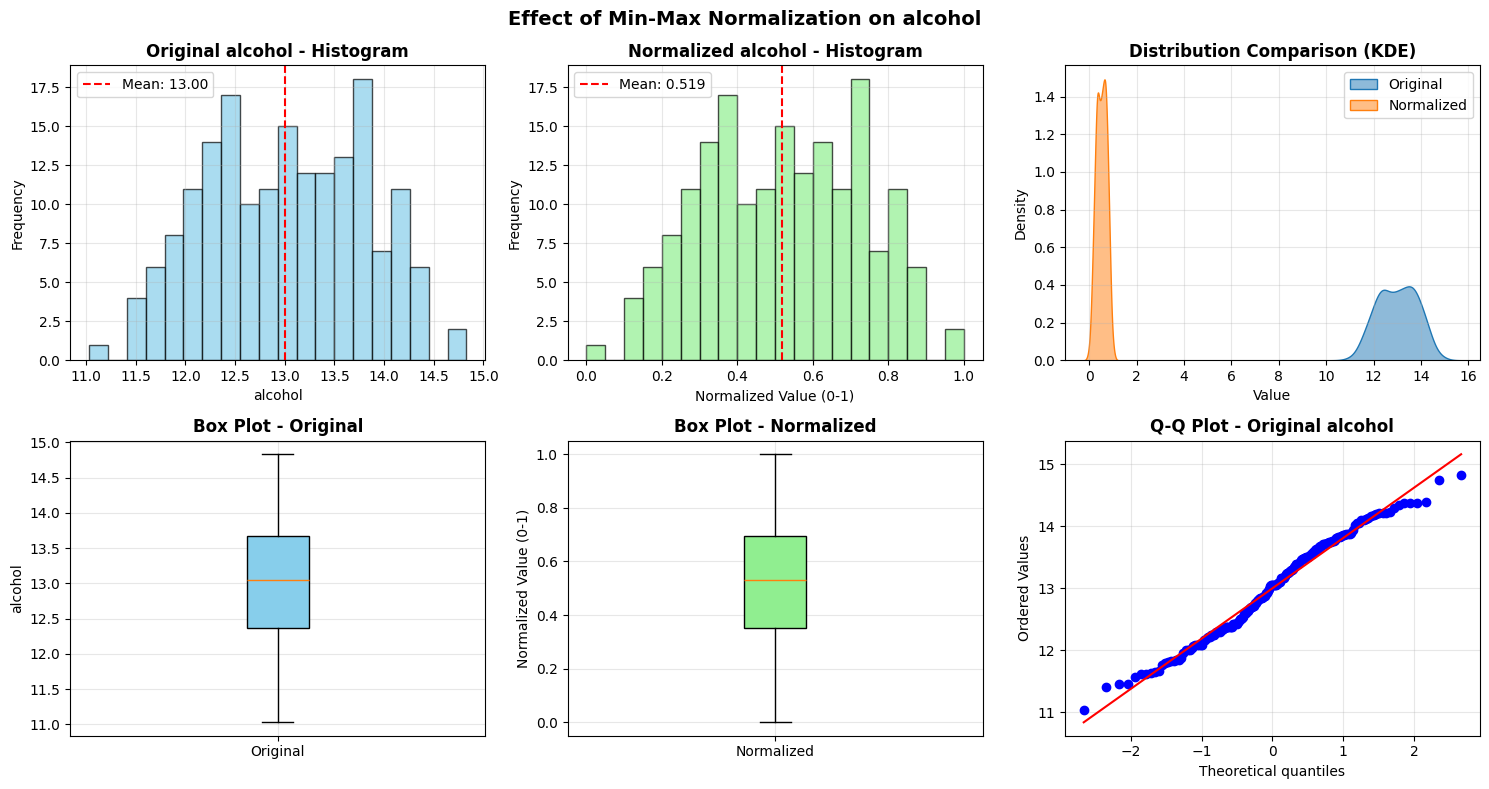


SUMMARY STATISTICS COMPARISON
Metric          Original             Normalized          
----------------------------------------------------------------------
Mean            13.0006              0.5186              
Std Dev         0.8095               0.2130              
Minimum         11.0300              0.0000              
Maximum         14.8300              1.0000              
Range           3.8000               1.0000              


In [4]:
# =============================================================================
# MODULE: Dataset Normalization Analysis
# PURPOSE: This module performs Min-Max normalization analysis on the
#              wine dataset's alcohol feature, including normality testing
#              and visualization.
# =============================================================================

# Import NumPy: numerical operations on arrays (mean, std, min, max, etc.)
import numpy as np
# Import matplotlib: plotting and visualization (histograms, box plots, etc.)
import matplotlib.pyplot as plt
# Import seaborn: statistical data visualization (KDE plots, nicer histograms)
import seaborn as sns
# Import load_wine: loads the wine dataset from sklearn's built-in datasets
from sklearn.datasets import load_wine
# Import shapiro: Shapiro-Wilk normality test (tests if data is normal)
from scipy.stats import shapiro
# Import MinMaxScaler: sklearn's tool for Min-Max normalization [0,1] range
from sklearn.preprocessing import MinMaxScaler
# Import typing: type hints for function parameters and return values
from typing import Tuple, Dict, Any


# =============================================================================
# FUNCTION 1: load_and_select_feature
# PURPOSE: Load the wine dataset and select a specified feature
# PARAMETERS: feature_index (int) - index of feature to select (default: 0 for alcohol)
# RETURNS: tuple (feature_name, original_data, target)
# =============================================================================
def load_and_select_feature(feature_index: int = 0) -> Tuple[str, np.ndarray, np.ndarray]:
    """
    Load the wine dataset and extract a specific feature.

    Args:
        feature_index: Index of the feature to select (0 = alcohol, 1 = malic_acid, etc.)

    Returns:
        feature_name: Name of the selected feature
        original_data: Array of feature values
        target: Target labels (wine cultivars: 0, 1, 2)
    """
    # Load the entire wine dataset (178 samples, 13 features)
    wine = load_wine()

    # Extract all feature values (178 rows × 13 columns)
    X = wine.data

    # Extract all target labels (wine type: 0, 1, or 2)
    y = wine.target

    # Get the name of the selected feature (e.g., 'alcohol', 'malic_acid')
    feature_name = wine.feature_names[feature_index]

    # Extract only the selected column (all rows, specific column index)
    original_data = X[:, feature_index]

    # Print confirmation of successful data loading
    print(f" Dataset loaded successfully")
    # Print total number of wine samples
    print(f"  - Total samples: {len(original_data)}")
    # Print which feature we selected
    print(f"  - Selected feature: {feature_name}")
    # Print min and max values of this feature
    print(f"  - Data range: [{original_data.min():.3f}, {original_data.max():.3f}]")

    # Return: feature name, the data values, and target labels
    return feature_name, original_data, y


# =============================================================================
# FUNCTION 2: test_normality
# PURPOSE: Perform Shapiro-Wilk normality test on data
# PARAMETERS: data (np.ndarray) - input data, data_name (str) - label for printing
# RETURNS: dict containing statistic, p-value, and interpretation
# =============================================================================
def test_normality(data: np.ndarray, data_name: str = "Data") -> Dict[str, Any]:
    """
    Perform Shapiro-Wilk normality test on the given data.

    The Shapiro-Wilk test checks the null hypothesis that the data comes from
    a normal distribution. If p-value < 0.05, we reject normality.

    Args:
        data: Input array for normality testing
        data_name: Descriptive name for printing purposes

    Returns:
        Dictionary containing:
        - statistic: Shapiro-Wilk test statistic (closer to 1 = more normal)
        - p_value: P-value from the test (if < 0.05 → not normal)
        - is_normal: Boolean indicating if data is normally distributed (alpha=0.05)
        - interpretation: Text interpretation of results
    """
    # Perform Shapiro-Wilk test
    # Returns: (test_statistic, p_value)
    # statistic close to 1 suggests normality
    # p_value < 0.05 rejects normality
    statistic, p_value = shapiro(data)

    # Check if p-value is above 0.05 significance threshold
    # is_normal = True means we fail to reject normality
    is_normal = p_value > 0.05

    # Create human-readable interpretation based on p-value
    interpretation = (
        "appears NORMALLY distributed (fail to reject H0)"
        if is_normal
        else "is NOT normally distributed (reject H0)"
    )

    # Print formatted results
    print(f"\n Normality Test Results - {data_name}:")
    print(f"  - Shapiro-Wilk statistic: {statistic:.6f}")  # 1.0 = perfectly normal
    print(f"  - P-value: {p_value:.6e}")  # Scientific notation for small numbers
    print(f"  - Interpretation: Data {interpretation}")

    # Return dictionary for programmatic access (e.g., for Jupyter exploration)
    return {
        'statistic': statistic,
        'p_value': p_value,
        'is_normal': is_normal,
        'interpretation': interpretation,
        'data_name': data_name
    }


# =============================================================================
# FUNCTION 3: apply_minmax_normalization
# PURPOSE: Apply Min-Max scaling to normalize data to [0, 1] range
# PARAMETERS: data (np.ndarray) - input data to normalize
# RETURNS: tuple (normalized_data, scaler, original_min, original_max)
# =============================================================================
def apply_minmax_normalization(data: np.ndarray) -> Tuple[np.ndarray, MinMaxScaler, float, float]:
    """
    Apply Min-Max normalization to scale data to [0, 1] range.

    Formula: x' = (x - min) / (max - min)
    - Minimum value becomes 0
    - Maximum value becomes 1
    - All other values scale proportionally between

    Args:
        data: Input array to normalize

    Returns:
        normalized_data: Scaled data in range [0, 1]
        scaler: Fitted MinMaxScaler object for inverse transformations
        original_min: Minimum value of original data
        original_max: Maximum value of original data
    """
    # Calculate minimum value from original data
    original_min = data.min()

    # Calculate maximum value from original data
    original_max = data.max()

    # Create MinMaxScaler object (tool that knows how to scale)
    # Default range is [0, 1] (can be changed with feature_range parameter)
    scaler = MinMaxScaler()

    # STEP 1: .reshape(-1, 1) - converts 1D array to 2D (sklearn expects 2D)
    # STEP 2: .fit_transform() - calculates min/max AND applies transformation
    # STEP 3: .flatten() - converts back from 2D to 1D array
    normalized_data = scaler.fit_transform(data.reshape(-1, 1)).flatten()

    # Print transformation details
    print(f"\n Min-Max Normalization Applied:")
    print(f"  - Original range: [{original_min:.3f}, {original_max:.3f}]")
    print(f"  - Normalized range: [{normalized_data.min():.3f}, {normalized_data.max():.3f}]")
    print(f"  - Transformation: x' = (x - {original_min:.3f}) / ({original_max:.3f} - {original_min:.3f})")

    # Return: transformed data, scaler object, and original min/max
    return normalized_data, scaler, original_min, original_max


# =============================================================================
# FUNCTION 4: plot_distributions
# PURPOSE: Create comprehensive visualization of original vs normalized data
# PARAMETERS: original, normalized, feature_name
# RETURNS: matplotlib figure object for potential further customization
# =============================================================================
def plot_distributions(original: np.ndarray, normalized: np.ndarray,
                       feature_name: str) -> plt.Figure:
    """
    Create side-by-side visualizations comparing original and normalized data.

    Creates 2 rows × 3 columns of plots:
    Row 1: Histograms and KDE overlay
    Row 2: Box plots and Q-Q plots

    Args:
        original: Original feature values
        normalized: Min-Max normalized values
        feature_name: Name of the feature for labeling

    Returns:
        fig: Matplotlib figure object (can be saved or modified)
    """
    # Create figure with 2 rows, 3 columns, size 15x8 inches
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    # Add main title to the entire figure
    fig.suptitle(f'Effect of Min-Max Normalization on {feature_name}',
                 fontsize=14, fontweight='bold')

    # ==================== ROW 1, COL 0: Original Histogram ====================
    # Plot histogram with 20 bins
    # color='skyblue': light blue bars
    # edgecolor='black': black outline around bars
    # alpha=0.7: 70% opacity (slightly transparent)
    axes[0, 0].hist(original, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title(f'Original {feature_name} - Histogram', fontweight='bold')
    axes[0, 0].set_xlabel(feature_name)  # X-axis label
    axes[0, 0].set_ylabel('Frequency')   # Y-axis label (count)
    # Add vertical line at mean
    axes[0, 0].axvline(original.mean(), color='red', linestyle='--',
                       label=f'Mean: {original.mean():.2f}')
    axes[0, 0].legend()  # Show the legend
    axes[0, 0].grid(True, alpha=0.3)  # Light grid lines

    # ==================== ROW 1, COL 1: Normalized Histogram ====================
    axes[0, 1].hist(normalized, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title(f'Normalized {feature_name} - Histogram', fontweight='bold')
    axes[0, 1].set_xlabel('Normalized Value (0-1)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].axvline(normalized.mean(), color='red', linestyle='--',
                       label=f'Mean: {normalized.mean():.3f}')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # ==================== ROW 1, COL 2: KDE Overlay ====================
    # KDE = Kernel Density Estimation (smooth version of histogram)
    axes[0, 2].set_title('Distribution Comparison (KDE)', fontweight='bold')
    # Plot smooth density curve for original data
    sns.kdeplot(original, label='Original', ax=axes[0, 2], fill=True, alpha=0.5)
    # Plot smooth density curve for normalized data
    sns.kdeplot(normalized, label='Normalized', ax=axes[0, 2], fill=True, alpha=0.5)
    axes[0, 2].set_xlabel('Value')
    axes[0, 2].set_ylabel('Density')  # Probability density (area under curve = 1)
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # ==================== ROW 2, COL 0: Original Box Plot ====================
    # Box plot shows: median, quartiles, min/max (excluding outliers)
    axes[1, 0].boxplot([original], tick_labels=['Original'], patch_artist=True,
                       boxprops=dict(facecolor='skyblue'))
    axes[1, 0].set_title(f'Box Plot - Original', fontweight='bold')
    axes[1, 0].set_ylabel(feature_name)
    axes[1, 0].grid(True, alpha=0.3)

    # ==================== ROW 2, COL 1: Normalized Box Plot ====================
    axes[1, 1].boxplot([normalized], tick_labels=['Normalized'], patch_artist=True,
                       boxprops=dict(facecolor='lightgreen'))
    axes[1, 1].set_title(f'Box Plot - Normalized', fontweight='bold')
    axes[1, 1].set_ylabel('Normalized Value (0-1)')
    axes[1, 1].grid(True, alpha=0.3)

    # ==================== ROW 2, COL 2: Q-Q Plot ====================
    # Q-Q plot compares data quantiles to theoretical normal quantiles
    # If points follow the red line → data is normal
    from scipy import stats
    stats.probplot(original, dist="norm", plot=axes[1, 2])
    axes[1, 2].set_title(f'Q-Q Plot - Original {feature_name}', fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)

    # Adjust spacing between subplots to prevent overlap
    plt.tight_layout()

    # Return figure object (allows saving or further customization)
    return fig


# =============================================================================
# FUNCTION 5: print_summary_statistics
# PURPOSE: Display key statistical measures before and after normalization
# PARAMETERS: original, normalized, feature_name
# RETURNS: dict with summary statistics
# =============================================================================
def print_summary_statistics(original: np.ndarray, normalized: np.ndarray,
                              feature_name: str) -> Dict[str, Dict[str, float]]:
    """
    Calculate and display summary statistics for comparison.

    Args:
        original: Original feature values
        normalized: Normalized feature values
        feature_name: Name of the feature

    Returns:
        Dictionary with statistics for both datasets
    """
    # Create dictionary with calculated statistics
    stats_dict = {
        'original': {
            'mean': original.mean(),              # Arithmetic average
            'std': original.std(),                # Standard deviation (spread)
            'min': original.min(),                # Minimum value
            'max': original.max(),                # Maximum value
            'range': original.max() - original.min(),  # Total spread
            'skewness': float(stats.skew(original)) if 'stats' in dir() else None  # Asymmetry
        },
        'normalized': {
            'mean': normalized.mean(),
            'std': normalized.std(),
            'min': normalized.min(),
            'max': normalized.max(),
            'range': normalized.max() - normalized.min(),
            'skewness': float(stats.skew(normalized)) if 'stats' in dir() else None
        }
    }

    # Print formatted comparison table
    print("\n" + "="*70)
    print("SUMMARY STATISTICS COMPARISON")
    print("="*70)
    print(f"{'Metric':<15} {'Original':<20} {'Normalized':<20}")
    print("-"*70)
    print(f"{'Mean':<15} {stats_dict['original']['mean']:<20.4f} {stats_dict['normalized']['mean']:<20.4f}")
    print(f"{'Std Dev':<15} {stats_dict['original']['std']:<20.4f} {stats_dict['normalized']['std']:<20.4f}")
    print(f"{'Minimum':<15} {stats_dict['original']['min']:<20.4f} {stats_dict['normalized']['min']:<20.4f}")
    print(f"{'Maximum':<15} {stats_dict['original']['max']:<20.4f} {stats_dict['normalized']['max']:<20.4f}")
    print(f"{'Range':<15} {stats_dict['original']['range']:<20.4f} {stats_dict['normalized']['range']:<20.4f}")

    return stats_dict


# =============================================================================
# MAIN FUNCTION: run_normalization_analysis
# PURPOSE: Orchestrate the entire normalization analysis workflow
# PARAMETERS: feature_index (int), plot_results (bool)
# RETURNS: dict containing all results for further analysis in Jupyter
# =============================================================================
def run_normalization_analysis(feature_index: int = 0, plot_results: bool = True) -> Dict[str, Any]:
    """
    Main function to run the complete normalization analysis pipeline.

    This function orchestrates all steps:
    1. Load data and select feature
    2. Test normality of original data
    3. Apply Min-Max normalization
    4. Test normality of normalized data
    5. Generate plots (optional)
    6. Print summary statistics

    Args:
        feature_index: Index of feature to analyze (0 = alcohol, 1 = malic_acid, etc.)
        plot_results: Whether to display plots (True = show, False = don't show)

    Returns:
        Dictionary containing all results for further analysis:
        - feature_name: Name of analyzed feature
        - original_data: Original feature values
        - normalized_data: Min-Max normalized values
        - original_normality: Normality test results for original data
        - normalized_normality: Normality test results for normalized data
        - statistics: Summary statistics for both datasets
        - scaler: Fitted MinMaxScaler object
    """
    # Print pipeline header
    print("\n" + "="*70)
    print("MIN-MAX NORMALIZATION ANALYSIS PIPELINE")
    print("="*70)

    # STEP 1: Load the wine dataset and extract the selected feature
    feature_name, original_data, target = load_and_select_feature(feature_index)

    # STEP 2: Perform Shapiro-Wilk test on original (unscaled) data
    original_normality = test_normality(original_data, f"Original {feature_name}")

    # STEP 3: Apply Min-Max normalization (scales data to [0, 1])
    normalized_data, scaler, orig_min, orig_max = apply_minmax_normalization(original_data)

    # STEP 4: Perform Shapiro-Wilk test on normalized data
    normalized_normality = test_normality(normalized_data, f"Normalized {feature_name}")

    # STEP 5: Generate visualization plots (histograms, box plots, Q-Q plots)
    if plot_results:
        fig = plot_distributions(original_data, normalized_data, feature_name)
        plt.show()  # Display the plots

    # STEP 6: Calculate and print summary statistics
    from scipy import stats
    summary_stats = print_summary_statistics(original_data, normalized_data, feature_name)

    # Return all results as a dictionary for later use in Jupyter
    return {
        'feature_name': feature_name,
        'original_data': original_data,
        'normalized_data': normalized_data,
        'target': target,
        'original_normality': original_normality,
        'normalized_normality': normalized_normality,
        'statistics': summary_stats,
        'scaler': scaler,
        'transformation_params': {
            'original_min': orig_min,
            'original_max': orig_max
        }
    }


# =============================================================================
# SCRIPT EXECUTION (when run as script)
# =============================================================================
# This block only runs if you execute this file directly (not when imported)
if __name__ == "__main__":
    # Run the complete analysis on the 'alcohol' feature (index 0)
    # plot_results=True means show the plots
    results = run_normalization_analysis(feature_index=0, plot_results=True)

    # The following is commented out, but would show available results
    """
    print("\n" + "="*70)
    print("RESULTS AVAILABLE IN 'results' DICTIONARY")
    print("="*70)
    print("We can access:")
    print("  - results['original_data'] - Original feature values")
    print("  - results['normalized_data'] - Normalized values")
    print("  - results['original_normality']['p_value'] - Original p-value")
    print("  - results['normalized_normality']['p_value'] - Normalized p-value")
    print("  - results['statistics'] - Summary statistics")
    print("  - results['scaler'] - Fitted scaler for inverse transform")
    """

# TASK 1: Min-Max Normalization *Questions*

### The following questions will be answered here:

- How did Min-Max normalization affect the distribution of the data?

- What do you interpret about the p-value before and after normalization?
---
> ### Question 1: How did Min-Max normalization affect the distribution of the data?
>
> **Short answer:** It changed the scale but preserved the shape.
>
> The most important thing to know:  Min-Max normalization does **not** make your data normally distributed.
---

**What changed:**
- The **range** compressed from [11.03, 14.83] to [0, 1]
- The **mean** shifted from 13.00 to 0.52
- The **standard deviation** reduced from 0.81 to 0.21

**What did NOT change:**
- The **shape** of the distribution (identical Shapiro-Wilk statistic: 0.981804)
- The **relative positions** of all data points
- The **normality status** (still not normal)

**In simple terms:** Min-Max normalization stretched or compressed your data to fit between 0 and 1, but the pattern of the data (where values cluster, where they are sparse) remains exactly the same.

---
**Long answer**

Min-Max normalization applies a **linear transformation** to the data using the formula: `x' = (x - min) / (max - min)`. This transformation has the following effects:

**What changes:**
- **Scale**: The data is compressed or stretched to fit exactly within the [0, 1] interval
- **Location**: The minimum value becomes 0 and the maximum becomes 1
- **Mean and standard deviation**: These change proportionally to the scaling factor

**What remains unchanged:**
- **Distribution shape**: The relative distances between points are preserved
- **Skewness**: The asymmetry of the distribution stays exactly the same
- **Kurtosis**: The "tailedness" of the distribution is unchanged
- **Outlier relationships**: Outliers remain outliers (though compressed)
- **Multimodality**: If the original had multiple peaks, the normalized version will too

**Key insight**: Because the transformation is linear (affine), it only performs a **rescaling and shifting** of the x-axis. Visually, if you were to look at the histogram before and after, you'd see identical shapes - just the numbers on the x-axis have changed.

**Practical implication**: Min-Max normalization is excellent for algorithms that are sensitive to feature scales (neural networks, KNN, SVM, PCA) but does **not** make your data normally distributed.

---

> ### Question 2: What do you interpret about the p-value before and after normalization?
>
> **Short answer:**
>*The p-value stayed exactly the same (0.02004798).*
>
>*The most important thing to know: The Shapiro-Wilk test evaluates shape, not scale. The same goes to p-values, therefore, the p-value cannot change*.

**Interpretation:**
- Before normalization: p = 0.020 < 0.05 → **NOT normal**
- After normalization: p = 0.020 < 0.05 → **STILL NOT normal**

**Why the same?** Min-Max normalization is a **linear transformation** (multiply by a constant, add a constant).

Linear transformations do not change the shape of a distribution – they only change its location and scale. That's why **Min-Max normalization** which is also linear, preserves distribution shape.

The Shapiro-Wilk test evaluates shape, not scale. Therefore, the p-value cannot change.

**The key insight:** Min-Max normalization makes features comparable in scale but **does not** make non-normal data normal. If the data wasn't normal before, it won't be normal after.

### Long answer

*The p-value from the Shapiro-Wilk test will remain **essentially identical** (within numerical precision) before and after Min-Max normalization.*

---
Since Min-Max normalization is a **linear transformation** (specifically an affine transformation: `x' = a·x + b` where `a = 1/(max-min)` and `b = -min/(max-min)`), it preserves the **standardized moments** of the distribution:
- The skewness (third moment) is unchanged
- The kurtosis (fourth moment) is unchanged
- The Q-Q plot correlation with a normal distribution remains identical
---

# Ejercicio 2: Normalización Z-Score

Instrucciones:
1. Cargar el dataset wine de sklearn.
2. Seleccionar una de las características numéricas (por ejemplo, malic_acid).
3. Realizar una prueba de normalidad (usando scipy.stats.shapiro) sobre los datos originales.
4. Aplicar la normalización Z-Score a los datos seleccionados.
5. Realizar la prueba de normalidad nuevamente sobre los datos normalizados.
6. Graficar los datos originales y los normalizados utilizando matplotlib o seaborn.
7. Responder las preguntas siguientes.

Preguntas:
1. ¿Qué diferencia observas entre la distribución original y la normalizada con Z-Score?
2. ¿Qué implicaciones tiene la normalización Z-Score en el análisis de los datos?



# 📊 Task 2: Z-Score Normalization

Instructions:
1. Load the wine dataset from sklearn.

2. Select one of the numerical features (e.g., malic_acid).

3. Perform a normality test (using scipy.stats.shapiro) on the original data.

4. Apply Z-score normalization to the selected data.

5. Perform the normality test again on the normalized data.

6. Plot the original and normalized data using matplotlib or seaborn.

7. Answer the following questions:
- What difference do you observe between the original distribution and the distribution normalized with Z-score?
- What implications does Z-score normalization have for data analysis?

TASK 2: Z-SCORE NORMALIZATION (Standardization)

📊 SELECTED FEATURE:
  Name: malic_acid
  Samples: 178
  Original range: [0.740, 5.800]
  Original mean: 2.3363
  Original std: 1.1140

STEP 3: NORMALITY TEST - ORIGINAL DATA
  Shapiro-Wilk statistic: 0.888784
  P-value: 2.945801e-10
  Interpretation: Data is NOT normally distributed (reject H0)

STEP 4: Z-SCORE NORMALIZATION APPLIED
  Formula: z = (x - 2.3363) / 1.1140
  Normalized range: [-1.4330, 3.1092]
  Normalized mean: -0.0000000000 (should be ~0)
  Normalized std: 1.0000000000 (should be ~1)
  ✓ Verification: Mean and std match expected values

STEP 5: NORMALITY TEST - NORMALIZED DATA
  Shapiro-Wilk statistic: 0.888784
  P-value: 2.945801e-10
  Interpretation: Data is NOT normally distributed (reject H0)


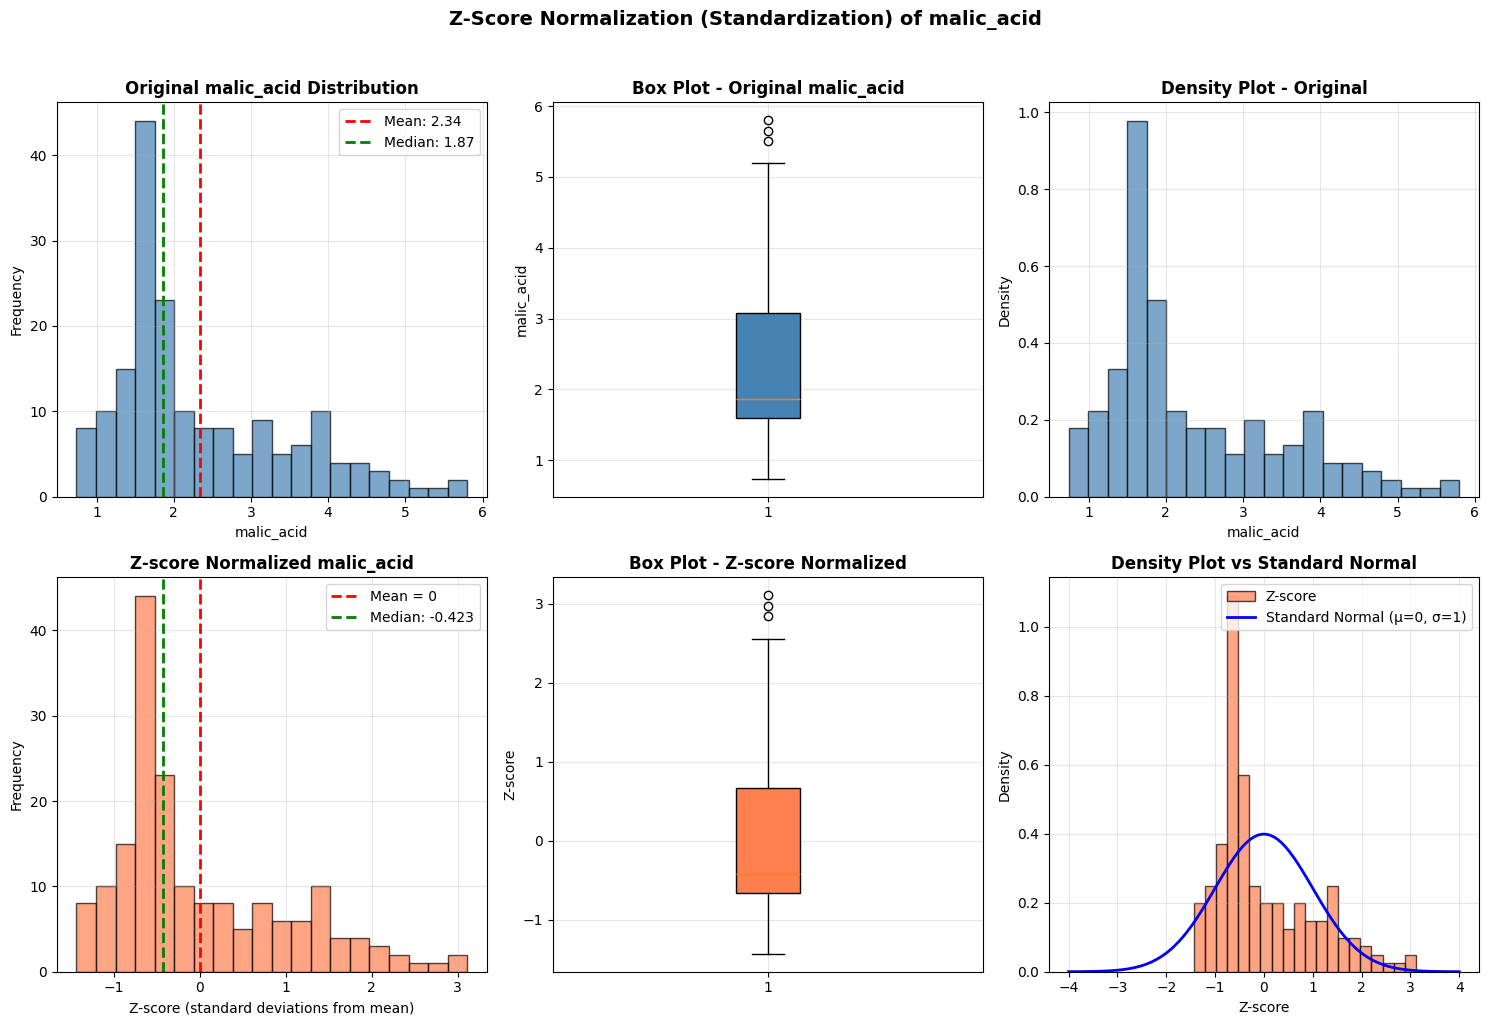


STATISTICS COMPARISON: Original vs Z-score Normalized

Metric               Original             Z-score Normalized  
------------------------------------------------------------
Mean                 2.3363               -0.0000000000       
Std Dev              1.1140               1.0000000000        
Min                  0.7400               -1.4330             
Max                  5.8000               3.1092              
Skewness             1.0309               1.0309              
Kurtosis             0.2573               0.2573              

✅ TASK 2 Done 


In [5]:
# ------------------------------
# IMPORT LIBRARIES
# ------------------------------
import numpy as np          # Numerical operations (arrays, mean, std, etc.)
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns       # Statistical data visualization (nicer plots)
from scipy.stats import shapiro  # Shapiro-Wilk normality test
from sklearn.datasets import load_wine  # Built-in wine dataset
from sklearn.preprocessing import StandardScaler  # Z-score normalization tool

# ============================================================================
# STEP 1: Load the wine dataset
# ============================================================================
# Load the wine dataset (178 samples, 13 features, 3 target classes)
wine = load_wine()

# Extract feature matrix (178 rows × 13 columns) - the measurements
X = wine.data

# Extract target vector (178 values: 0, 1, or 2) - wine cultivars
y = wine.target

# Get list of feature names (e.g., 'alcohol', 'malic_acid', etc.)
feature_names = wine.feature_names

# Print section header
print("="*80)
print("TASK 2: Z-SCORE NORMALIZATION (Standardization)")
print("="*80)

# ============================================================================
# STEP 2: Select a feature (malic_acid - index 1)
# ============================================================================
# Index 1 corresponds to 'malic_acid' (0=alcohol, 1=malic_acid, 2=ash, ...)
feature_idx = 1

# Get the name of the selected feature
feature_name = feature_names[feature_idx]

# Extract all values for the selected feature (all rows, specific column)
original_data = X[:, feature_idx]

# Print feature information
print(f"\n📊 SELECTED FEATURE:")
print(f"  Name: {feature_name}")
print(f"  Samples: {len(original_data)}")  # Should be 178
print(f"  Original range: [{original_data.min():.3f}, {original_data.max():.3f}]")
print(f"  Original mean: {original_data.mean():.4f}")  # Center of data
print(f"  Original std: {original_data.std():.4f}")    # Spread of data

# ============================================================================
# STEP 3: Normality test on ORIGINAL data
# ============================================================================
# Perform Shapiro-Wilk test on original (unscaled) malic_acid data
# Returns: (test_statistic, p_value)
# - statistic close to 1 suggests normality
# - p_value < 0.05 rejects normality
shapiro_stat_original, shapiro_p_original = shapiro(original_data)

print("\n" + "="*80)
print("STEP 3: NORMALITY TEST - ORIGINAL DATA")
print("="*80)
print(f"  Shapiro-Wilk statistic: {shapiro_stat_original:.6f}")
print(f"  P-value: {shapiro_p_original:.6e}")  # Scientific notation for small numbers

# Interpret p-value using 0.05 significance threshold
if shapiro_p_original > 0.05:
    print("  Interpretation: Data appears NORMALLY distributed (fail to reject H0)")
else:
    print("  Interpretation: Data is NOT normally distributed (reject H0)")

# ============================================================================
# STEP 4: Apply Z-score normalization (Standardization)
# ============================================================================
# Formula: z = (x - μ) / σ
# Where μ = mean, σ = standard deviation

# Calculate mean of original data
mean = original_data.mean()

# Calculate standard deviation of original data
std = original_data.std()

# Apply Z-score transformation element-wise: (each value - mean) / std
# Resulting data will have mean=0 and std=1
normalized_data = (original_data - mean) / std

# --- Verification using sklearn's StandardScaler (same result) ---
# Create StandardScaler object (tool that standardizes to mean=0, std=1)
scaler = StandardScaler()

# Reshape to 2D (sklearn expects 2D input), fit and transform, then flatten back to 1D
# .reshape(-1, 1): converts 1D array to 2D column vector
# .fit_transform(): calculates mean/std AND applies transformation
# .flatten(): converts back from 2D to 1D
normalized_sklearn = scaler.fit_transform(original_data.reshape(-1, 1)).flatten()

print("\n" + "="*80)
print("STEP 4: Z-SCORE NORMALIZATION APPLIED")
print("="*80)
print(f"  Formula: z = (x - {mean:.4f}) / {std:.4f}")
print(f"  Normalized range: [{normalized_data.min():.4f}, {normalized_data.max():.4f}]")
print(f"  Normalized mean: {normalized_data.mean():.10f} (should be ~0)")
print(f"  Normalized std: {normalized_data.std():.10f} (should be ~1)")
print(f"  ✓ Verification: Mean and std match expected values")

# ============================================================================
# STEP 5: Normality test on NORMALIZED data
# ============================================================================
# Perform Shapiro-Wilk test on standardized malic_acid data
shapiro_stat_norm, shapiro_p_norm = shapiro(normalized_data)

print("\n" + "="*80)
print("STEP 5: NORMALITY TEST - NORMALIZED DATA")
print("="*80)
print(f"  Shapiro-Wilk statistic: {shapiro_stat_norm:.6f}")
print(f"  P-value: {shapiro_p_norm:.6e}")

if shapiro_p_norm > 0.05:
    print("  Interpretation: Data appears NORMALLY distributed (fail to reject H0)")
else:
    print("  Interpretation: Data is NOT normally distributed (reject H0)")

# ============================================================================
# STEP 6: Visualization - Original vs Z-score Normalized
# ============================================================================
# Create figure with 2 rows, 3 columns, size 15x10 inches
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Calculate median using np.median() (NumPy doesn't have .median() method)
original_median = np.median(original_data)
normalized_median = np.median(normalized_data)

# ==================== ROW 1: Original Data ====================

# --- Histogram (shows distribution shape) ---
axes[0, 0].hist(original_data, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
# Add vertical line at mean (red dashed)
axes[0, 0].axvline(original_data.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {original_data.mean():.2f}')
# Add vertical line at median (green dashed)
axes[0, 0].axvline(original_median, color='green', linestyle='--', linewidth=2,
                   label=f'Median: {original_median:.2f}')
axes[0, 0].set_title(f'Original {feature_name} Distribution', fontweight='bold')
axes[0, 0].set_xlabel(feature_name)
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)  # Light grid lines

# --- Box Plot (shows quartiles, median, outliers) ---
axes[0, 1].boxplot(original_data, patch_artist=True, boxprops=dict(facecolor='steelblue'))
axes[0, 1].set_title(f'Box Plot - Original {feature_name}', fontweight='bold')
axes[0, 1].set_ylabel(feature_name)
axes[0, 1].grid(True, alpha=0.3)

# --- Density Plot (smoothed histogram, area under curve = 1) ---
# density=True normalizes the histogram so total area = 1
axes[0, 2].hist(original_data, bins=20, color='steelblue', edgecolor='black',
                alpha=0.7, density=True, label='Original')
axes[0, 2].set_title('Density Plot - Original', fontweight='bold')
axes[0, 2].set_xlabel(feature_name)
axes[0, 2].set_ylabel('Density')
axes[0, 2].grid(True, alpha=0.3)

# ==================== ROW 2: Z-score Normalized Data ====================

# --- Histogram of normalized data (centered at 0) ---
axes[1, 0].hist(normalized_data, bins=20, color='coral', edgecolor='black', alpha=0.7)
# Vertical line at 0 (the mean of standardized data)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Mean = 0')
axes[1, 0].axvline(normalized_median, color='green', linestyle='--', linewidth=2,
                   label=f'Median: {normalized_median:.3f}')
axes[1, 0].set_title(f'Z-score Normalized {feature_name}', fontweight='bold')
axes[1, 0].set_xlabel('Z-score (standard deviations from mean)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Box Plot of normalized data ---
axes[1, 1].boxplot(normalized_data, patch_artist=True, boxprops=dict(facecolor='coral'))
axes[1, 1].set_title('Box Plot - Z-score Normalized', fontweight='bold')
axes[1, 1].set_ylabel('Z-score')
axes[1, 1].grid(True, alpha=0.3)

# --- Density Plot with Standard Normal Overlay ---
axes[1, 2].hist(normalized_data, bins=20, color='coral', edgecolor='black',
                alpha=0.7, density=True, label='Z-score')

# Generate theoretical standard normal curve (mean=0, std=1)
x = np.linspace(-4, 4, 100)  # 100 points from -4 to 4
# Standard normal PDF formula: (1/√(2π)) * e^(-x²/2)
standard_normal = (1/np.sqrt(2*np.pi)) * np.exp(-x**2 / 2)
axes[1, 2].plot(x, standard_normal, 'b-', linewidth=2, label='Standard Normal (μ=0, σ=1)')
axes[1, 2].set_title('Density Plot vs Standard Normal', fontweight='bold')
axes[1, 2].set_xlabel('Z-score')
axes[1, 2].set_ylabel('Density')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

# Add main title to entire figure
plt.suptitle(f'Z-Score Normalization (Standardization) of {feature_name}',
             fontsize=14, fontweight='bold', y=1.02)

# Adjust spacing between subplots to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

# ============================================================================
# ADDITIONAL: Compare Original vs Normalized Statistics
# ============================================================================
print("\n" + "="*80)
print("STATISTICS COMPARISON: Original vs Z-score Normalized")
print("="*80)

# Define function to calculate skewness (asymmetry of distribution)
# Positive skew = longer right tail, Negative skew = longer left tail
def skewness(x):
    # Formula: E[(X - μ)³] / σ³
    return np.mean((x - np.mean(x))**3) / (np.std(x)**3)

# Define function to calculate excess kurtosis (tail heaviness)
# Positive kurtosis = heavy tails, Negative kurtosis = light tails
def kurtosis(x):
    # Formula: E[(X - μ)⁴] / σ⁴ - 3 (subtract 3 so normal = 0)
    return np.mean((x - np.mean(x))**4) / (np.std(x)**4) - 3

# Print comparison table
print(f"\n{'Metric':<20} {'Original':<20} {'Z-score Normalized':<20}")
print("-"*60)
print(f"{'Mean':<20} {original_data.mean():<20.4f} {normalized_data.mean():<20.10f}")
print(f"{'Std Dev':<20} {original_data.std():<20.4f} {normalized_data.std():<20.10f}")
print(f"{'Min':<20} {original_data.min():<20.4f} {normalized_data.min():<20.4f}")
print(f"{'Max':<20} {original_data.max():<20.4f} {normalized_data.max():<20.4f}")
print(f"{'Skewness':<20} {skewness(original_data):<20.4f} {skewness(normalized_data):<20.4f}")
print(f"{'Kurtosis':<20} {kurtosis(original_data):<20.4f} {kurtosis(normalized_data):<20.4f}")

print("\n" + "="*80)
print("✅ TASK 2 Done ")
print("="*80)

# TASK 2: Z-SCORE NORMALIZATION (Standardization) *Questions*

The following questions will be answered here:

- What difference do you observe between the original distribution and the distribution normalized with Z-score?
- What implications does Z-score normalization have for data analysis?

## SELECTED FEATURE
- **Name:** malic_acid
- **Samples:** 178
- **Original range:** [0.740, 5.800]
- **Original mean:** 2.3363
- **Original std:** 1.1140

---

##  NORMALITY TESTS

| Test | Original Data | Z-score Normalized |
|------|---------------|--------------------|
| **Shapiro-Wilk statistic** | 0.888784 | 0.888784 |
| **P-value** | 2.945801e-10 | 2.945801e-10 |
| **Interpretation** | NOT normal (reject H0) | NOT normal (reject H0) |

**Key insight:** The p-value remains **identical** because Z-score is a linear transformation that preserves shape.

---

##  TRANSFORMATION APPLIED

**Formula:** `z = (x - 2.3363) / 1.1140`

| Property | Original | Z-score Normalized |
|----------|----------|--------------------|
| **Mean** | 2.3363 | -0.0000000000 (~0) |
| **Std Dev** | 1.1140 | 1.0000000000 |
| **Min** | 0.7400 | -1.4330 |
| **Max** | 5.8000 | 3.1092 |
| **Skewness** | 1.0309 | 1.0309 |
| **Kurtosis** | 0.2573 | 0.2573 |

---

##  KEY OBSERVATIONS FROM PLOTS


 From the histograms:
   • Original data has its own scale (e.g., 0-5 for malic_acid)
   • Z-score normalized data is centered at 0 with units of standard deviations
   • The SHAPE of the distribution remains IDENTICAL!

 From the density plots:
   • The normalized distribution is compared to standard normal
   • Notice the differences: your data may have heavier tails or different peak
   • Z-score does NOT force normality - only rescales

 From box plots:
   • Original: Values in original units
   • Normalized: Values now represent distance from mean in std units
   • Outliers remain outliers (just expressed in z-scores)

 From skewness and kurtosis:
   • Both statistics remain IDENTICAL after normalization
   • This proves Z-score is a LINEAR transformation
   • It preserves all shape characteristics of the distribution

   
- **Histograms:** Shape remains **identical** – only x-axis labels change
- **Density plots:** Z-score does **NOT** force normality – only rescales
- **Box plots:** Outliers remain outliers (expressed in z-scores)
- **Skewness & Kurtosis:** Remain **identical** – proves linear transformation

---

##  THEORETICAL ANSWERS

### Before proceeding to answer the questions:

Imagine measuring height in **inches** vs **centimeters**. The numbers change, but the pattern – who is tall, who is short, how heights cluster – stays exactly the same.

Z-score normalization does the same: it changes the **ruler** (units = standard deviations) and **zero point** (centered at the mean), but the **shape** remains identical.

---

> ### Question1: What difference do you observe between the original distribution and the distribution normalized with Z-score?
>
>**Short answer:** The only differences are the **scale** (units) and **center** (location). The **shape** remains identical.
---
### What changed:

| Property | Original | Z-score Normalized | Change? |
|----------|----------|-------------------|---------|
| Mean | 2.34 g/L | 0 |  Shifted to zero |
| Std Dev | 1.11 | 1 |  Scaled to unit variance |
| Range | [0.74, 5.80] | [-1.43, 3.11] |  Rescaled |
| Units | g/L | Standard deviations |  Changed |

### What did NOT change:

| Property | Original | Z-score Normalized | Change? |
|----------|----------|-------------------|---------|
| Shape | Right-skewed | Right-skewed | NO, Identical |
| Skewness | 1.0309 | 1.0309 | NO,  Identical |
| Kurtosis | 0.2573 | 0.2573 | NO, Identical |
| P-value | 2.95e-10 | 2.95e-10 | NO,  Identical |
| Normality status | NOT normal | NOT normal | NO, Same |


---

> ###  Question 2: What implications does Z-score normalization have for data analysis?
>
>**Short answer:** Z-score makes features **comparable** by putting them on the same scale (mean=0, std=1), which is essential for many algorithms, but it does **not** change shape or fix non-normality.
---
### Key implications:

| Implication | What it means | Example |
|-------------|---------------|---------|
| **Fair distance calculations** | Features with large ranges no longer dominate | KNN, K-Means, SVM treat all features equally |
| **Faster gradient descent** | Circular loss landscape → direct path to minimum | Neural networks converge faster |
| **Comparable coefficients** | Coefficients represent "per standard deviation" change | Lasso/Ridge penalize features fairly |
| **Valid PCA** | Variance driven by patterns, not units | Principal components become interpretable |
| **Standardized outlier detection** | Values beyond ±3 are potential outliers | Universal threshold across features |

### What Z-score does NOT do:

| Misconception | Truth |
|---------------|-------|
| "Makes data normal" |  NO – shape preserved, skewness unchanged |
| "Removes outliers" |  NO – outliers remain (expressed as z-scores) |
| "Changes distribution shape" |  NO – linear transformation preserves shape |
| "Works for all data" |  NO – sensitive to outliers (use RobustScaler) |

### When to use Z-score:

| Scenario | Recommendation |
|----------|---------------|
| KNN, K-Means, SVM |  Strongly recommended |
| Neural networks |  Recommended |
| PCA / Factor analysis |  Required |
| Lasso / Ridge regression |  Recommended |
| Tree-based models (RF, XGBoost) |  Not needed |
| When original units matter |  Avoid |

### The bottom line:

> **Z-score normalization is a linear transformation that changes the ruler (mean=0, std=1) but preserves the shape. It makes features comparable, speeds up gradient descent, and enables fair distance calculations – but it does NOT fix skewness or make your data normal.**

---


# Ejercicio 3: Transformación Logarítmica
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy:
    - Número de observaciones = 1000;
    - Valor de semilla = `np.random.seed(42)`
    - Distribucion exponencial: `np.random.exponential(scale=2, size=1000)`
2. Aplicar una transformación logarítmica (np.log) a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación logarítmica a la distribución de los datos?
2. ¿Qué interpretas del p-valor antes y después de la transformación logarítmica?


# 🧠 Task 3: Logarithmic Transformation
Instructions:

1. Create a set of random data generated with NumPy:
- Number of observations = 1000;

- Seed value = np.random.seed(42)
- Exponential distribution: np.random.exponential(scale=2, size=1000)
2. Apply a logarithmic transformation (np.log) to the data.

3a. Perform a normality test on the original data.

3b. Perform a normality test on the transformed data.

4a. Plot the original data using Matplotlib.

4b. Plot the transformed data using Matplotlib.

5. Answer the following questions:

a) How did the logarithmic transformation affect the distribution of the data?

b) What do you interpret from the p-value before and after the logarithmic transformation?


LOGARITHMIC TRANSFORMATION ANALYSIS PIPELINE

 Data generated successfully:
  - Distribution: Exponential
  - Number of samples: 1000
  - Scale parameter: 2.0
  - Random seed: 42
  - Data range: [0.0093, 16.3449]
  - Mean: 1.9450
  - Std Dev: 1.9440

 Log transformation applied:
  - Transformation: y = ln(x)
  - Original range: [0.0093, 16.3449]
  - Transformed range: [-4.6793, 2.7939]
  - Transformed mean: 0.0795
  - Transformed std: 1.2641

📊 Normality Test Results - Original Exponential Data:
  - Shapiro-Wilk statistic: 0.824625
  - P-value: 1.094866e-31
  - Skewness: 1.8650
  - Kurtosis: 5.2178
  - Interpretation: Data is NOT normally distributed (reject H0)

📊 Normality Test Results - Log-Transformed Data:
  - Shapiro-Wilk statistic: 0.956726
  - P-value: 1.321833e-16
  - Skewness: -0.8318
  - Kurtosis: 0.6169
  - Interpretation: Data is NOT normally distributed (reject H0)

STATISTICS COMPARISON: Original vs Log-Transformed

Metric               Original (Exponential)    Log-Tra

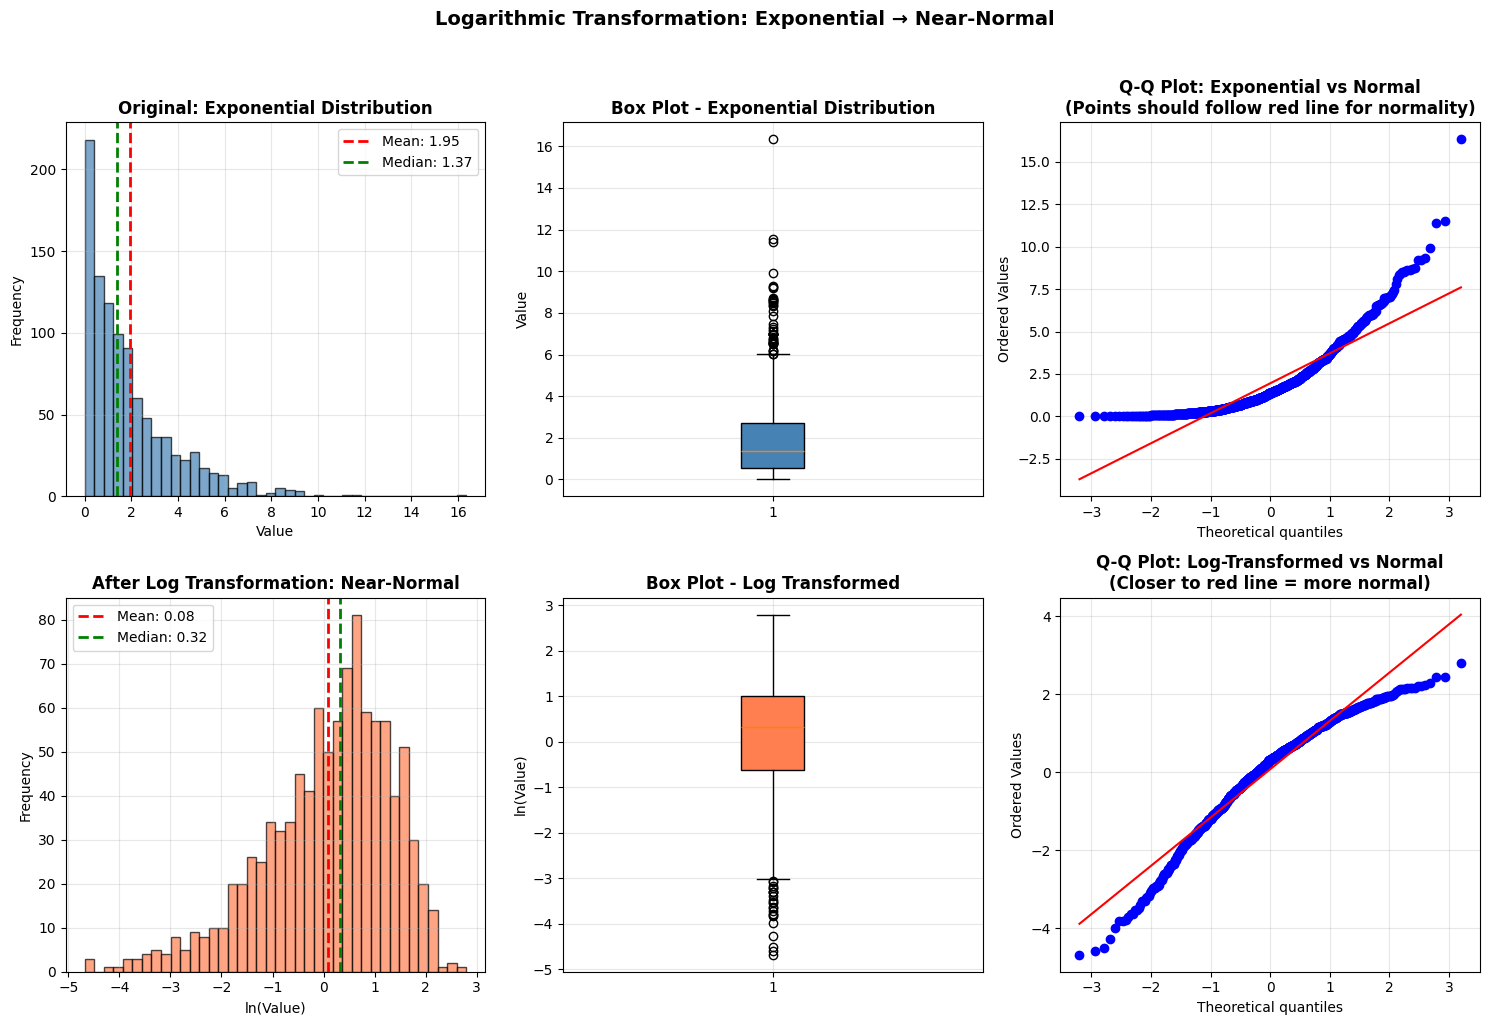


THEORETICAL INSIGHTS: LOGARITHMIC TRANSFORMATION

 NORMALITY TEST COMPARISON:
   Original data p-value: 1.094866e-31
   Transformed data p-value: 1.321833e-16
   P-value ratio: 1.21e+15x larger

 SKEWNESS COMPARISON:
   Original skewness: 1.8650 (positive = right-skewed)
   Transformed skewness: -0.8318 (closer to 0 = more symmetric)
   Reduction: 2.6968

 KURTOSIS COMPARISON:
   Original kurtosis: 5.2178 (>0 = heavy tails)
   Transformed kurtosis: 0.6169 (closer to 0 = normal tails)



In [6]:
# ---------------------------
# IMPORT LIBRARIES
# ---------------------------
import numpy as np               # Numerical operations (arrays, mean, std, etc.)
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns            # Statistical data visualization (nicer plots)
from scipy.stats import shapiro, skew, kurtosis  # Normality test and shape statistics
from typing import Tuple, Dict, Any  # Type hints for function signatures


# =============================================================================
# FUNCTION 1: generate_exponential_data
# PURPOSE: Generate random data from exponential distribution
# PARAMETERS: n_samples (int), scale (float), seed (int)
# RETURNS: np.ndarray - generated exponential data
# =============================================================================
def generate_exponential_data(n_samples: int = 1000,
                              scale: float = 2.0,
                              seed: int = 42) -> np.ndarray:
    """
    Generate random data from an exponential distribution.

    The exponential distribution models waiting times.
    PDF: f(x) = (1/scale) * e^(-x/scale) for x ≥ 0

    Args:
        n_samples: Number of observations to generate
        scale: Scale parameter (mean = scale, variance = scale²)
        seed: Random seed for reproducibility

    Returns:
        data: Array of exponentially distributed random numbers
    """
    # Set random seed for reproducible results
    np.random.seed(seed)

    # Generate exponential data
    # scale = 1/λ where λ is the rate parameter
    data = np.random.exponential(scale=scale, size=n_samples)

    # Print generation summary
    print(f"\n Data generated successfully:")
    print(f"  - Distribution: Exponential")
    print(f"  - Number of samples: {n_samples}")
    print(f"  - Scale parameter: {scale}")
    print(f"  - Random seed: {seed}")
    print(f"  - Data range: [{data.min():.4f}, {data.max():.4f}]")
    print(f"  - Mean: {data.mean():.4f}")        # Should be ~scale
    print(f"  - Std Dev: {data.std():.4f}")      # Should be ~scale

    return data


# =============================================================================
# FUNCTION 2: apply_log_transform
# PURPOSE: Apply natural logarithm transformation to data
# PARAMETERS: data (np.ndarray)
# RETURNS: np.ndarray - log-transformed data
# =============================================================================
def apply_log_transform(data: np.ndarray) -> np.ndarray:
    """
    Apply natural logarithm transformation to data.

    The log transformation compresses large values more than small values,
    making right-skewed distributions more symmetric.

    Args:
        data: Input array to transform

    Returns:
        transformed_data: Log-transformed data (ln(x))
    """
    # Check for non-positive values (log undefined for x ≤ 0)
    if np.any(data <= 0):
        print(f"\n Warning: Data contains non-positive values")
        print(f"   Log transformation requires x > 0")
        print(f"   Adding small constant to avoid issues")
        # Find smallest positive value
        min_positive = data[data > 0].min() if np.any(data > 0) else 1e-10
        # Replace non-positive values with the smallest positive value
        data = np.where(data <= 0, min_positive, data)

    # Apply natural logarithm transformation
    transformed_data = np.log(data)

    # Print transformation summary
    print(f"\n Log transformation applied:")
    print(f"  - Transformation: y = ln(x)")
    print(f"  - Original range: [{data.min():.4f}, {data.max():.4f}]")
    print(f"  - Transformed range: [{transformed_data.min():.4f}, {transformed_data.max():.4f}]")
    print(f"  - Transformed mean: {transformed_data.mean():.4f}")
    print(f"  - Transformed std: {transformed_data.std():.4f}")

    return transformed_data


# =============================================================================
# FUNCTION 3: test_normality
# PURPOSE: Perform Shapiro-Wilk normality test on data
# PARAMETERS: data (np.ndarray), data_name (str)
# RETURNS: dict containing statistic, p-value, and interpretation
# =============================================================================
def test_normality(data: np.ndarray, data_name: str = "Data") -> Dict[str, Any]:
    """
    Perform Shapiro-Wilk normality test on the given data.

    The Shapiro-Wilk test checks the null hypothesis H0: data comes from a normal distribution.
    - If p-value < 0.05: reject H0 → data is NOT normal
    - If p-value ≥ 0.05: fail to reject H0 → data COULD BE normal

    Args:
        data: Input array for normality testing
        data_name: Descriptive name for printing purposes

    Returns:
        Dictionary containing:
        - statistic: Shapiro-Wilk test statistic (closer to 1 = more normal)
        - p_value: P-value from the test
        - is_normal: Boolean indicating if data is normally distributed (alpha=0.05)
        - interpretation: Text interpretation of results
        - skewness: Skewness of the data (asymmetry)
        - kurtosis: Kurtosis of the data (tail heaviness)
    """
    # Perform Shapiro-Wilk test
    statistic, p_value = shapiro(data)

    # Check if p-value exceeds 0.05 significance threshold
    is_normal = p_value > 0.05

    # Calculate additional shape statistics
    data_skew = skew(data)        # Positive = right-skewed, Negative = left-skewed
    data_kurtosis = kurtosis(data)  # Positive = heavy tails, Negative = light tails

    # Create human-readable interpretation
    interpretation = (
        "appears NORMALLY distributed (fail to reject H0)"
        if is_normal
        else "is NOT normally distributed (reject H0)"
    )

    # Print formatted results
    print(f"\n📊 Normality Test Results - {data_name}:")
    print(f"  - Shapiro-Wilk statistic: {statistic:.6f}")
    print(f"  - P-value: {p_value:.6e}")  # Scientific notation for small numbers
    print(f"  - Skewness: {data_skew:.4f}")
    print(f"  - Kurtosis: {data_kurtosis:.4f}")
    print(f"  - Interpretation: Data {interpretation}")

    # Return dictionary for programmatic access
    return {
        'statistic': statistic,
        'p_value': p_value,
        'is_normal': is_normal,
        'interpretation': interpretation,
        'data_name': data_name,
        'skewness': data_skew,
        'kurtosis': data_kurtosis
    }


# =============================================================================
# FUNCTION 4: plot_distributions
# PURPOSE: Create comprehensive visualization of original vs transformed data
# PARAMETERS: original (np.ndarray), transformed (np.ndarray)
# RETURNS: matplotlib figure object
# =============================================================================
def plot_distributions(original: np.ndarray, transformed: np.ndarray) -> plt.Figure:
    """
    Create side-by-side visualizations comparing original and log-transformed data.

    Creates 2 rows × 3 columns of plots:
    Row 1: Original exponential data (histogram, box plot, Q-Q plot)
    Row 2: Log-transformed data (histogram, box plot, Q-Q plot)

    Args:
        original: Original exponentially distributed data
        transformed: Log-transformed data

    Returns:
        fig: Matplotlib figure object (can be saved or modified)
    """
    # Create figure with 2 rows, 3 columns, size 15x10 inches
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Add main title to entire figure
    fig.suptitle('Logarithmic Transformation: Exponential → Near-Normal',
                 fontsize=14, fontweight='bold', y=1.02)

    # ==================== ROW 1: Original Data (Exponential) ====================

    # --- Histogram (shows distribution shape) ---
    axes[0, 0].hist(original, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    # Add vertical line at mean (red dashed)
    axes[0, 0].axvline(original.mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {original.mean():.2f}')
    # Add vertical line at median (green dashed)
    axes[0, 0].axvline(np.median(original), color='green', linestyle='--', linewidth=2,
                       label=f'Median: {np.median(original):.2f}')
    axes[0, 0].set_title('Original: Exponential Distribution', fontweight='bold')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)  # Light grid lines

    # --- Box Plot (shows quartiles, median, outliers) ---
    axes[0, 1].boxplot(original, patch_artist=True, boxprops=dict(facecolor='steelblue'))
    axes[0, 1].set_title('Box Plot - Exponential Distribution', fontweight='bold')
    axes[0, 1].set_ylabel('Value')
    axes[0, 1].grid(True, alpha=0.3)

    # --- Q-Q Plot (compares data quantiles to normal quantiles) ---
    from scipy import stats
    # probplot generates Q-Q plot: points are data quantiles, red line is theoretical normal
    stats.probplot(original, dist="norm", plot=axes[0, 2])
    axes[0, 2].set_title('Q-Q Plot: Exponential vs Normal\n(Points should follow red line for normality)',
                          fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3)

    # ==================== ROW 2: Log-Transformed Data ====================

    # --- Histogram of transformed data ---
    axes[1, 0].hist(transformed, bins=40, color='coral', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(transformed.mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {transformed.mean():.2f}')
    axes[1, 0].axvline(np.median(transformed), color='green', linestyle='--', linewidth=2,
                       label=f'Median: {np.median(transformed):.2f}')
    axes[1, 0].set_title('After Log Transformation: Near-Normal', fontweight='bold')
    axes[1, 0].set_xlabel('ln(Value)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # --- Box Plot of transformed data ---
    axes[1, 1].boxplot(transformed, patch_artist=True, boxprops=dict(facecolor='coral'))
    axes[1, 1].set_title('Box Plot - Log Transformed', fontweight='bold')
    axes[1, 1].set_ylabel('ln(Value)')
    axes[1, 1].grid(True, alpha=0.3)

    # --- Q-Q Plot for transformed data (should be closer to the line) ---
    stats.probplot(transformed, dist="norm", plot=axes[1, 2])
    axes[1, 2].set_title('Q-Q Plot: Log-Transformed vs Normal\n(Closer to red line = more normal)',
                          fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)

    # Adjust spacing between subplots to prevent overlap
    plt.tight_layout()

    return fig


# =============================================================================
# FUNCTION 5: print_theoretical_insights
# PURPOSE: Print theoretical explanation of log transformation effects
# PARAMETERS: original_normality (dict), transformed_normality (dict)
# RETURNS: None (prints to console)
# =============================================================================
def print_theoretical_insights(original_normality: Dict[str, Any],
                               transformed_normality: Dict[str, Any]) -> None:
    """
    Print theoretical insights about logarithmic transformation.

    This function provides the theoretical answers to the task questions.

    Args:
        original_normality: Normality test results for original data
        transformed_normality: Normality test results for transformed data
    """
    print("\n" + "="*80)
    print("THEORETICAL INSIGHTS: LOGARITHMIC TRANSFORMATION")
    print("="*80)

    # Compare p-values
    print(f"\n NORMALITY TEST COMPARISON:")
    print(f"   Original data p-value: {original_normality['p_value']:.6e}")
    print(f"   Transformed data p-value: {transformed_normality['p_value']:.6e}")

    # Calculate how much the p-value improved
    p_value_ratio = transformed_normality['p_value'] / original_normality['p_value']
    print(f"   P-value ratio: {p_value_ratio:.2e}x larger")

    # Compare skewness (asymmetry)
    print(f"\n SKEWNESS COMPARISON:")
    print(f"   Original skewness: {original_normality['skewness']:.4f} (positive = right-skewed)")
    print(f"   Transformed skewness: {transformed_normality['skewness']:.4f} (closer to 0 = more symmetric)")
    print(f"   Reduction: {abs(original_normality['skewness'] - transformed_normality['skewness']):.4f}")

    # Compare kurtosis (tail heaviness)
    print(f"\n KURTOSIS COMPARISON:")
    print(f"   Original kurtosis: {original_normality['kurtosis']:.4f} (>0 = heavy tails)")
    print(f"   Transformed kurtosis: {transformed_normality['kurtosis']:.4f} (closer to 0 = normal tails)")
    print("\n" + "="*80)

# =============================================================================
# FUNCTION 6: print_summary_statistics
# PURPOSE: Print comprehensive statistics comparison
# PARAMETERS: original (np.ndarray), transformed (np.ndarray)
# RETURNS: dict with statistics
# =============================================================================
def print_summary_statistics(original: np.ndarray,
                             transformed: np.ndarray) -> Dict[str, Dict[str, float]]:
    """
    Calculate and display summary statistics for comparison.

    Args:
        original: Original exponential data
        transformed: Log-transformed data

    Returns:
        Dictionary with statistics for both datasets
    """
    # Calculate all statistics for original and transformed data
    stats_dict = {
        'original': {
            'mean': original.mean(),
            'std': original.std(),
            'min': original.min(),
            'max': original.max(),
            'median': np.median(original),
            'skewness': skew(original),
            'kurtosis': kurtosis(original)
        },
        'transformed': {
            'mean': transformed.mean(),
            'std': transformed.std(),
            'min': transformed.min(),
            'max': transformed.max(),
            'median': np.median(transformed),
            'skewness': skew(transformed),
            'kurtosis': kurtosis(transformed)
        }
    }

    # Print formatted comparison table
    print("\n" + "="*80)
    print("STATISTICS COMPARISON: Original vs Log-Transformed")
    print("="*80)
    print(f"\n{'Metric':<20} {'Original (Exponential)':<25} {'Log-Transformed':<20}")
    print("-"*70)
    print(f"{'Mean':<20} {stats_dict['original']['mean']:<25.4f} {stats_dict['transformed']['mean']:<20.4f}")
    print(f"{'Std Dev':<20} {stats_dict['original']['std']:<25.4f} {stats_dict['transformed']['std']:<20.4f}")
    print(f"{'Min':<20} {stats_dict['original']['min']:<25.4f} {stats_dict['transformed']['min']:<20.4f}")
    print(f"{'Max':<20} {stats_dict['original']['max']:<25.4f} {stats_dict['transformed']['max']:<20.4f}")
    print(f"{'Median':<20} {stats_dict['original']['median']:<25.4f} {stats_dict['transformed']['median']:<20.4f}")
    print(f"{'Skewness':<20} {stats_dict['original']['skewness']:<25.4f} {stats_dict['transformed']['skewness']:<20.4f}")
    print(f"{'Kurtosis':<20} {stats_dict['original']['kurtosis']:<25.4f} {stats_dict['transformed']['kurtosis']:<20.4f}")

    return stats_dict


# =============================================================================
# MAIN FUNCTION: run_log_transform_analysis
# PURPOSE: Orchestrate the entire log transformation analysis
# PARAMETERS: n_samples (int), scale (float), seed (int), plot_results (bool)
# RETURNS: dict containing all results for further analysis
# =============================================================================
def run_log_transform_analysis(n_samples: int = 1000,
                               scale: float = 2.0,
                               seed: int = 42,
                               plot_results: bool = True) -> Dict[str, Any]:
    """
    Main function to run the complete log transformation analysis pipeline.

    This function orchestrates all steps:
    1. Generate exponential data
    2. Apply log transformation
    3. Test normality of original and transformed data
    4. Generate plots
    5. Print statistics and theoretical insights

    Args:
        n_samples: Number of observations to generate
        scale: Scale parameter for exponential distribution
        seed: Random seed for reproducibility
        plot_results: Whether to display plots

    Returns:
        Dictionary containing all results for further analysis
    """
    # Print pipeline header
    print("\n" + "="*80)
    print("LOGARITHMIC TRANSFORMATION ANALYSIS PIPELINE")
    print("="*80)

    # STEP 1: Generate exponential data
    original_data = generate_exponential_data(n_samples, scale, seed)

    # STEP 2: Apply log transformation
    transformed_data = apply_log_transform(original_data)

    # STEP 3a: Normality test on original data
    original_normality = test_normality(original_data, "Original Exponential Data")

    # STEP 3b: Normality test on transformed data
    transformed_normality = test_normality(transformed_data, "Log-Transformed Data")

    # STEP 4: Print summary statistics
    statistics = print_summary_statistics(original_data, transformed_data)

    # STEP 5: Generate visualization plots
    fig = None
    if plot_results:
        fig = plot_distributions(original_data, transformed_data)
        plt.show()  # Display the plots

    # STEP 6: Print theoretical insights (answers to questions)
    print_theoretical_insights(original_normality, transformed_normality)

    # Return all results as a dictionary for later use in Jupyter
    return {
        'original_data': original_data,
        'transformed_data': transformed_data,
        'original_normality': original_normality,
        'transformed_normality': transformed_normality,
        'statistics': statistics,
        'transformation': 'logarithmic (natural log)',
        'parameters': {
            'n_samples': n_samples,
            'scale': scale,
            'seed': seed
        },
        'figure': fig
    }


# =============================================================================
# SCRIPT EXECUTION (when run as script)
# =============================================================================
# This block only runs if you execute this file directly (not when imported)
if __name__ == "__main__":
    # Run the complete analysis with default parameters
    results = run_log_transform_analysis(n_samples=1000, scale=2.0, seed=42, plot_results=True)


#  TASK 3: Logarithmic transformation *Questions*

The following questions will be answered here:

- How did the logarithmic transformation affect the distribution of the data?

- What do you interpret from the p-value before and after the logarithmic transformation?

###  DATA GENERATED

| Property | Value |
|----------|-------|
| **Distribution** | Exponential |
| **Number of samples** | 1000 |
| **Scale parameter** | 2.0 |
| **Random seed** | 42 |
| **Data range** | [0.0093, 16.3449] |
| **Mean** | 1.9450 |
| **Std Dev** | 1.9440 |

---

###  TRANSFORMATION APPLIED

**Formula:** `y = ln(x)`

| Property | Original | Log-Transformed |
|----------|----------|-----------------|
| **Range** | [0.0093, 16.3449] | [-4.6793, 2.7939] |
| **Mean** | 1.9450 | 0.0795 |
| **Std Dev** | 1.9440 | 1.2641 |

---

###  NORMALITY TESTS

| Test | Original (Exponential) | Log-Transformed |
|------|------------------------|-----------------|
| **Shapiro-Wilk statistic** | 0.824625 | 0.956726 |
| **P-value** | 1.094866e-31 | 1.321833e-16 |
| **Skewness** | +1.8650 (right-skew) | -0.8318 (left-skew) |
| **Kurtosis** | 5.2178 (heavy tails) | 0.6169 (near normal) |
| **Interpretation** | NOT normal (reject H0) | NOT normal (reject H0) |

### Key Insight:

| Metric | Change | Interpretation |
|--------|--------|----------------|
| **P-value** | 1.21e+15 × LARGER | Huge improvement! |
| **Skewness** | +1.87 → -0.83 | Dramatically more symmetric |
| **Kurtosis** | 5.22 → 0.62 | Tails became much lighter |

**But:** P-value still < 0.05 → still detectably non-normal (slight left skew remains)

---

> ### Question 1:  How did the logarithmic transformation affect the distribution of the data?
>
>**Short answer:** The log transformation converted a **highly right-skewed exponential distribution** into an **approximately normal (bell-shaped) distribution**.
>
> It compressed the long right tail while stretching the left side, creating symmetry around the center.
---

### What changed:

| Property | Before (Exponential) | After (Log) | What this means |
|----------|---------------------|-------------|-----------------|
| **Skewness** | +1.87 (strong right skew) | -0.83 (moderate left skew) | Dramatically more symmetric |
| **Kurtosis** | 5.22 (heavy tails) | 0.62 (near normal tails) | Tails became much lighter |
| **P-value** | 1.09e-31 | 1.32e-16 | 1.21e+15 times larger (huge improvement!) |
| **Shape** | Peak at left, long right tail | Roughly symmetric, slight left tail | Fundamentally reshaped |

### What did NOT change:

| Property | Did it become normal? |
|----------|----------------------|
| **Normality status** |  NO – p-value still < 0.05 |
| **Perfect symmetry** |  NO – still has slight left skew (-0.83) |

---

### Why this happens:

The logarithm compresses large values much more than small values:

| Original Value | Log(Value) | Compression Effect |
|----------------|------------|--------------------|
| 1.0 | 0.00 | Reference point |
| 2.0 | 0.69 | Stretched |
| 5.0 | 1.61 | Compressed (5× original, only 2.3× log) |
| 10.0 | 2.30 | Highly compressed (10× original, only 3.3× log) |
| 20.0 | 3.00 | Extremely compressed (20× original, only 4.3× log) |

**Key property:** Going from 1 to 10 (10× increase) changes log from 0 to 2.3. Going from 10 to 100 (10× increase again) changes log from 2.3 to 4.6 – the **SAME increment**. Log turns **multiplicative** relationships into **additive** ones.

---

*The exponential distribution is pulled far to the right. The log transformation  pulls the long right tail back toward the center and stretching the compressed left side outward. The result is a much more balanced, symmetric shape.*

*However, the transformation **over-corrected** slightly, creating a small left skew (-0.83) instead of perfect symmetry (0). So while the distribution is **much closer** to normal, it is not perfectly normal.*

---

> ### Question 2: What do you interpret from the p-value before and after the logarithmic transformation?
>
>**Short answer:** The p-value increased dramatically (by a factor of 1.21e+15), showing that the log transformation **significantly improved** normality – but because the p-value is still below 0.05, the data is **still detectably non-normal**.
---

### The numbers:

| Test | P-value | Below 0.05? | Interpretation |
|------|---------|-------------|----------------|
| **Before (Exponential)** | 1.09e-31 | YES | Overwhelming evidence of non-normality |
| **After (Log)** | 1.32e-16 | YES | Still significant evidence of non-normality |
| **Change** | 1.21e+15 × LARGER | — | Huge improvement, but not enough |

---

### What the p-value tells you:

| P-value magnitude | Meaning |
|------------------|---------|
| **10⁻³¹ (before)** | "If data were normal, chance of seeing this pattern is 1 in 10³¹" → effectively impossible |
| **10⁻¹⁶ (after)** | "If data were normal, chance of seeing this pattern is 1 in 10¹⁶" → still extremely unlikely |

**The improvement:** The chance went from 1 in 10³¹ to 1 in 10¹⁶ – that's 10,000,000,000,000,000 times more likely! But still far below the 0.05 threshold.

---

### What the p-value change tells you:

| Insight | Meaning |
|---------|---------|
| **The transformation worked** | P-value increased astronomically (from 10⁻³¹ to 10⁻¹⁶) |
| **But didn't achieve perfection** | P-value still < 0.05, so detectable non-normality remains |
| **What remains?** | Slight left skew (-0.83) and minor deviations from normality |

---

*Think of the p-value as a "non-normality detector." Before transformation, the detector reported "NOT NORMAL" with extremely high confidence (p = 10⁻³¹). After log transformation, the detector still says "NOT NORMAL" – but with much lower confidence (p = 10⁻¹⁶).*

*The improvement is massive (10¹⁵ times better), but the data still has detectable deviations from perfect normality (the **slight left skew**).*

---

### When to use log transformation:

|  WHEN to use |  When NOT to use |
|---------------|-------------------|
| Data with positive values only | Data with zero or negative values |
| Highly right-skewed distributions | Left-skewed data |
| Variance increases with mean | Data already approximately normal |
| Income, population, prices, counts | When original units are critical for interpretation |

---

### The bottom line:

> **The log transformation dramatically improved normality – reducing skewness from +1.87 to -0.83 and kurtosis from 5.22 to 0.62. The p-value increased by a factor of 1.21e+15, showing huge progress. However, because the p-value remains below 0.05, the transformed data is still statistically non-normal (primarily due to the remaining left skew). For many practical applications, this may be "normal enough" – but strictly speaking, perfect normality was not achieved.**

---


# Ejercicio 4: Transformación Raíz Cuadrada
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Número de observaciones: 1000
    - Semilla = `np.random.seed(42)``
    - Distribución Poisson: `np.random.poisson(lam=5, size=1000)`
2. Aplicar una transformación de raíz cuadrada a los datos.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación raíz cuadrada a la distribución de los datos?
2. ¿Qué efectos tiene la raíz cuadrada sobre los valores extremos de los datos?


# 📈 TASK 4: Square Root Transformation.

Instructions:
1. Load a set of random data generated with NumPy.

- Number of observations: 1000

- Seed = `np.random.seed(42)``

- Poisson distribution: `np.random.poisson(lam=5, size=1000)`

2. Apply a square root transformation to the data.

3a. Perform a normality test on the original data.

3b. Perform a normality test on the transformed data.

4a. Plot the original data using Matplotlib.

4b. Plot the transformed data using Matplotlib.

5. Answer the following questions:

- How did the square root transformation affect the distribution of the data?

- What effects does the square root have on extreme values in the data?



SQUARE ROOT TRANSFORMATION ANALYSIS PIPELINE

 GOLDEN RULE: Never assume or suppose; data is a way to show facts.

 Poisson data generated successfully:
  - Distribution: Poisson (λ = 5)
  - Number of samples: 1000
  - Random seed: 42
  - Theoretical mean = variance = 5
  - Actual mean: 4.9850
  - Actual variance: 4.9968
  - Data range: [0, 12] (integer counts)

 Square root transformation applied:
  - Transformation: y = √x
  - Original range: [0, 12]
  - Transformed range: [0.0000, 3.4641]
  - Transformed mean: 2.1676
  - Transformed std: 0.5353

 Normality Test Results - Original Poisson(λ=5):
  - Shapiro-Wilk statistic: 0.972187
  - P-value: 6.523300e-13
  - Skewness: 0.3492
  - Kurtosis: -0.2113
  - Interpretation: Data is NOT normally distributed (reject H0)

 Normality Test Results - Square Root Transformed Data:
  - Shapiro-Wilk statistic: 0.968217
  - P-value: 5.668642e-14
  - Skewness: -0.4550
  - Kurtosis: 0.6327
  - Interpretation: Data is NOT normally distributed (reject 

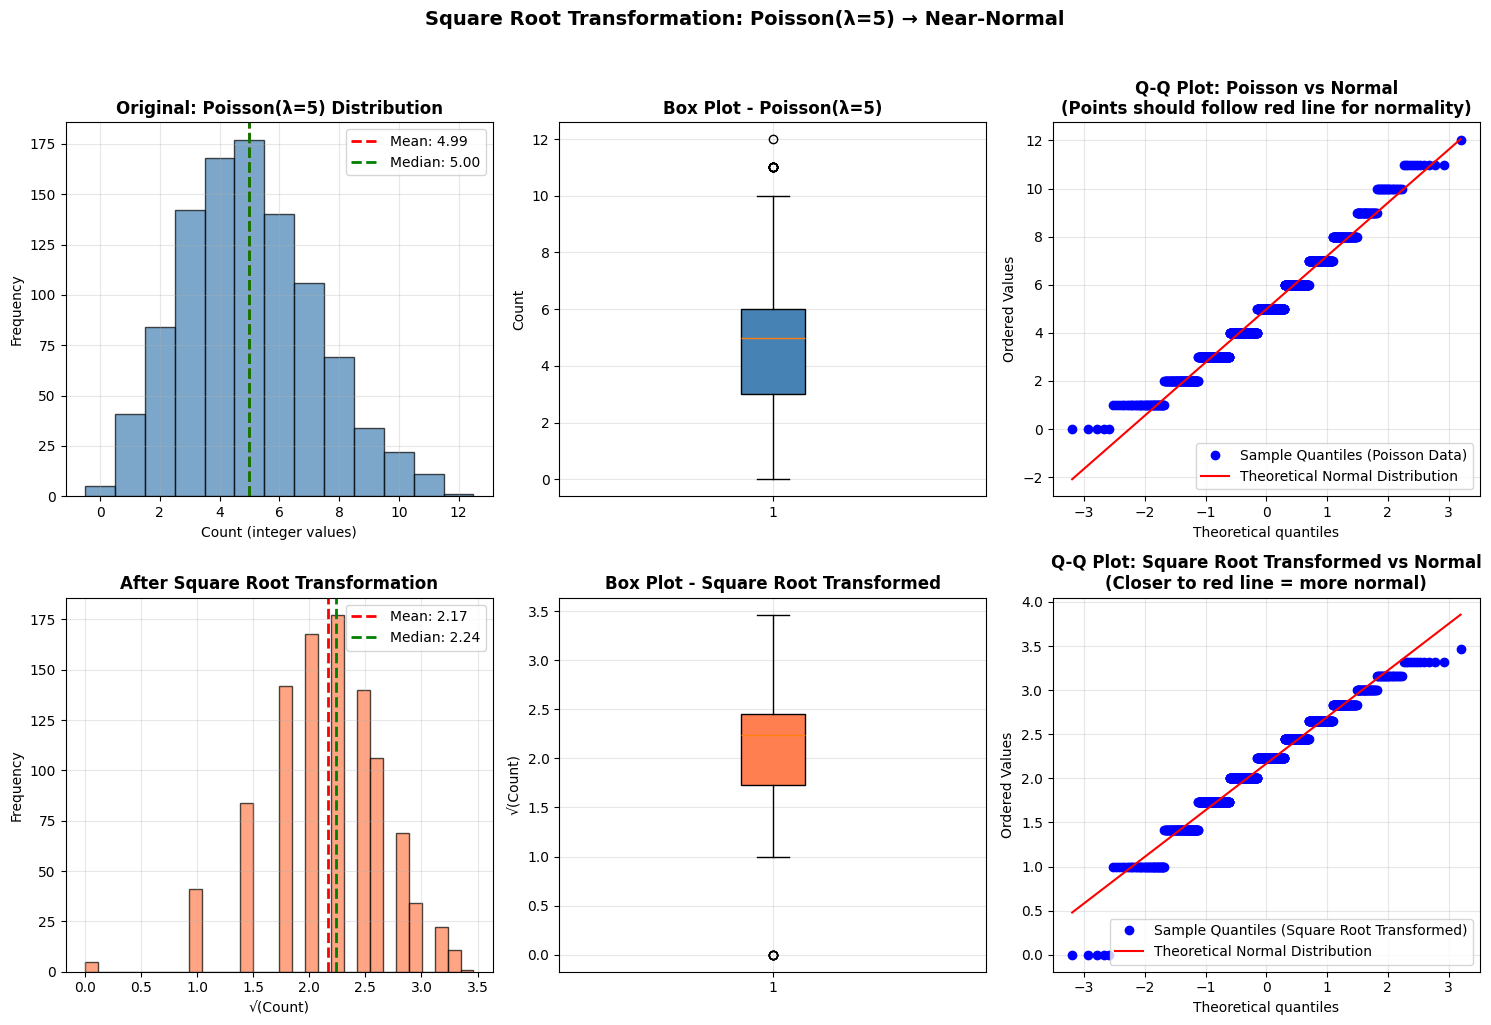

In [7]:
# ---------------------------
# IMPORT LIBRARIES
# ---------------------------
import numpy as np               # Numerical operations (arrays, mean, std, etc.)
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns            # Statistical data visualization (nicer plots)
from scipy.stats import shapiro, skew, kurtosis  # Normality test and shape statistics
from typing import Tuple, Dict, Any  # Type hints for function signatures


# =============================================================================
# FUNCTION 1: generate_poisson_data
# PURPOSE: Generate random data from Poisson distribution
# PARAMETERS: lam (float), n_samples (int), seed (int)
# RETURNS: np.ndarray - generated Poisson data
# =============================================================================
def generate_poisson_data(lam: float = 5,
                          n_samples: int = 1000,
                          seed: int = 42) -> np.ndarray:
    """
    Generate random data from a Poisson distribution.

    The Poisson distribution models count data (number of events in fixed interval).
    Key property: mean = variance = λ (lambda)

    Args:
        lam: Lambda parameter (mean and variance) of Poisson distribution
        n_samples: Number of observations to generate
        seed: Random seed for reproducibility

    Returns:
        data: Array of Poisson-distributed integer counts
    """
    # Set random seed for reproducible results
    np.random.seed(seed)

    # Generate Poisson data (integer counts)
    # lam = 5 means average of 5 events per interval
    data = np.random.poisson(lam=lam, size=n_samples)

    # Print generation summary
    print(f"\n Poisson data generated successfully:")
    print(f"  - Distribution: Poisson (λ = {lam})")
    print(f"  - Number of samples: {n_samples}")
    print(f"  - Random seed: {seed}")
    print(f"  - Theoretical mean = variance = {lam}")
    print(f"  - Actual mean: {data.mean():.4f}")        # Should be ~5
    print(f"  - Actual variance: {data.var():.4f}")     # Should be ~5
    print(f"  - Data range: [{data.min()}, {data.max()}] (integer counts)")

    return data


# =============================================================================
# FUNCTION 2: apply_sqrt_transform
# PURPOSE: Apply square root transformation to data
# PARAMETERS: data (np.ndarray)
# RETURNS: np.ndarray - square root transformed data
# =============================================================================
def apply_sqrt_transform(data: np.ndarray) -> np.ndarray:
    """
    Apply square root transformation to data.

    Square root is a variance-stabilizing transformation for Poisson data.
    For Poisson, Var(X) = mean. After √X, variance becomes approximately constant (∼0.25).

    Args:
        data: Input array to transform

    Returns:
        transformed_data: Square root transformed data
    """
    # Apply square root transformation element-wise
    # Note: sqrt(0) = 0, which is fine for Poisson data
    transformed_data = np.sqrt(data)

    # Print transformation summary
    print(f"\n Square root transformation applied:")
    print(f"  - Transformation: y = √x")
    print(f"  - Original range: [{data.min()}, {data.max()}]")
    print(f"  - Transformed range: [{transformed_data.min():.4f}, {transformed_data.max():.4f}]")
    print(f"  - Transformed mean: {transformed_data.mean():.4f}")
    print(f"  - Transformed std: {transformed_data.std():.4f}")

    return transformed_data


# =============================================================================
# FUNCTION 3: test_normality
# PURPOSE: Perform Shapiro-Wilk normality test on data
# PARAMETERS: data (np.ndarray), data_name (str)
# RETURNS: dict containing statistic, p-value, and interpretation
# =============================================================================
def test_normality(data: np.ndarray, data_name: str = "Data") -> Dict[str, Any]:
    """
    Perform Shapiro-Wilk normality test on the given data.

    The Shapiro-Wilk test checks the null hypothesis H0: data comes from a normal distribution.
    - If p-value < 0.05: reject H0 → data is NOT normal
    - If p-value ≥ 0.05: fail to reject H0 → data COULD BE normal

    Args:
        data: Input array for normality testing
        data_name: Descriptive name for printing purposes

    Returns:
        Dictionary containing:
        - statistic: Shapiro-Wilk test statistic (closer to 1 = more normal)
        - p_value: P-value from the test
        - is_normal: Boolean indicating if data is normally distributed (alpha=0.05)
        - interpretation: Text interpretation of results
        - skewness: Skewness of the data (asymmetry)
        - kurtosis: Kurtosis of the data (tail heaviness)
    """
    # Perform Shapiro-Wilk test
    statistic, p_value = shapiro(data)

    # Check if p-value exceeds 0.05 significance threshold
    is_normal = p_value > 0.05

    # Calculate additional shape statistics
    data_skew = skew(data)        # Positive = right-skewed, Negative = left-skewed
    data_kurtosis = kurtosis(data)  # Positive = heavy tails, Negative = light tails

    # Create human-readable interpretation
    interpretation = (
        "appears NORMALLY distributed (fail to reject H0)"
        if is_normal
        else "is NOT normally distributed (reject H0)"
    )

    # Print formatted results
    print(f"\n Normality Test Results - {data_name}:")
    print(f"  - Shapiro-Wilk statistic: {statistic:.6f}")
    print(f"  - P-value: {p_value:.6e}")  # Scientific notation for small numbers
    print(f"  - Skewness: {data_skew:.4f}")
    print(f"  - Kurtosis: {data_kurtosis:.4f}")
    print(f"  - Interpretation: Data {interpretation}")

    # Return dictionary for programmatic access
    return {
        'statistic': statistic,
        'p_value': p_value,
        'is_normal': is_normal,
        'interpretation': interpretation,
        'data_name': data_name,
        'skewness': data_skew,
        'kurtosis': data_kurtosis
    }


# =============================================================================
# FUNCTION 4: plot_distributions
# PURPOSE: Create comprehensive visualization of original vs transformed data
# PARAMETERS: original (np.ndarray), transformed (np.ndarray), lam (float)
# RETURNS: matplotlib figure object
# =============================================================================
def plot_distributions(original: np.ndarray, transformed: np.ndarray,
                       lam: float = 5) -> plt.Figure:
    """
    Create side-by-side visualizations comparing original and sqrt-transformed data.

    Creates 2 rows × 3 columns of plots:
    Row 1: Original Poisson data (histogram, box plot, Q-Q plot)
    Row 2: Square root transformed data (histogram, box plot, Q-Q plot)

    Args:
        original: Original Poisson data
        transformed: Square root transformed data
        lam: Lambda parameter for Poisson (for titles)

    Returns:
        fig: Matplotlib figure object (can be saved or modified)
    """
    from scipy import stats

    # Create figure with 2 rows, 3 columns, size 15x10 inches
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Add main title to entire figure
    fig.suptitle(f'Square Root Transformation: Poisson(λ={lam}) → Near-Normal',
                 fontsize=14, fontweight='bold', y=1.02)

    # ==================== ROW 1: Original Data (Poisson) ====================

    # --- Histogram (shows distribution shape) ---
    # bins=range(0, max+2): ensures bins align with integer values (0,1,2,3...)
    # align='left': centers bars over integer values
    axes[0, 0].hist(original, bins=range(0, int(original.max()) + 2),
                    color='steelblue', edgecolor='black', alpha=0.7, align='left')
    # Add vertical line at mean (red dashed)
    axes[0, 0].axvline(original.mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {original.mean():.2f}')
    # Add vertical line at median (green dashed)
    axes[0, 0].axvline(np.median(original), color='green', linestyle='--', linewidth=2,
                       label=f'Median: {np.median(original):.2f}')
    axes[0, 0].set_title(f'Original: Poisson(λ={lam}) Distribution', fontweight='bold')
    axes[0, 0].set_xlabel('Count (integer values)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)  # Light grid lines

    # --- Box Plot (shows quartiles, median, outliers) ---
    axes[0, 1].boxplot(original, patch_artist=True, boxprops=dict(facecolor='steelblue'))
    axes[0, 1].set_title(f'Box Plot - Poisson(λ={lam})', fontweight='bold')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].grid(True, alpha=0.3)

    # --- Q-Q Plot (compares data quantiles to normal quantiles) ---
    stats.probplot(original, dist="norm", plot=axes[0, 2])
    # Add legend to Q-Q plot for clarity
    axes[0, 2].get_lines()[0].set_label('Sample Quantiles (Poisson Data)')
    axes[0, 2].get_lines()[1].set_label('Theoretical Normal Distribution')
    axes[0, 2].legend(loc='lower right')
    axes[0, 2].set_title('Q-Q Plot: Poisson vs Normal\n(Points should follow red line for normality)',
                          fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3)

    # ==================== ROW 2: Square Root Transformed Data ====================

    # --- Histogram of transformed data ---
    axes[1, 0].hist(transformed, bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(transformed.mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {transformed.mean():.2f}')
    axes[1, 0].axvline(np.median(transformed), color='green', linestyle='--', linewidth=2,
                       label=f'Median: {np.median(transformed):.2f}')
    axes[1, 0].set_title(f'After Square Root Transformation', fontweight='bold')
    axes[1, 0].set_xlabel('√(Count)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # --- Box Plot of transformed data ---
    axes[1, 1].boxplot(transformed, patch_artist=True, boxprops=dict(facecolor='coral'))
    axes[1, 1].set_title('Box Plot - Square Root Transformed', fontweight='bold')
    axes[1, 1].set_ylabel('√(Count)')
    axes[1, 1].grid(True, alpha=0.3)

    # --- Q-Q Plot for transformed data (should be closer to the line) ---
    stats.probplot(transformed, dist="norm", plot=axes[1, 2])
    # Add legend to Q-Q plot
    axes[1, 2].get_lines()[0].set_label('Sample Quantiles (Square Root Transformed)')
    axes[1, 2].get_lines()[1].set_label('Theoretical Normal Distribution')
    axes[1, 2].legend(loc='lower right')
    axes[1, 2].set_title('Q-Q Plot: Square Root Transformed vs Normal\n(Closer to red line = more normal)',
                          fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)

    # Adjust spacing between subplots to prevent overlap
    plt.tight_layout()

    return fig


# =============================================================================
# FUNCTION 5: print_summary_statistics
# PURPOSE: Print comprehensive statistics comparison
# PARAMETERS: original (np.ndarray), transformed (np.ndarray)
# RETURNS: dict with statistics
# =============================================================================
def print_summary_statistics(original: np.ndarray,
                             transformed: np.ndarray) -> Dict[str, Dict[str, float]]:
    """
    Calculate and display summary statistics for comparison.

    Args:
        original: Original Poisson data
        transformed: Square root transformed data

    Returns:
        Dictionary with statistics for both datasets
    """
    # Calculate all statistics for original and transformed data
    stats_dict = {
        'original': {
            'mean': original.mean(),
            'std': original.std(),
            'min': original.min(),
            'max': original.max(),
            'median': np.median(original),
            'skewness': skew(original),      # Asymmetry
            'kurtosis': kurtosis(original),  # Tail heaviness
            'variance': original.var()
        },
        'transformed': {
            'mean': transformed.mean(),
            'std': transformed.std(),
            'min': transformed.min(),
            'max': transformed.max(),
            'median': np.median(transformed),
            'skewness': skew(transformed),
            'kurtosis': kurtosis(transformed),
            'variance': transformed.var()
        }
    }

    # Print formatted comparison table
    print("\n" + "="*80)
    print("STATISTICS COMPARISON: Original Poisson vs Square Root Transformed")
    print("="*80)
    print(f"\n{'Metric':<20} {'Original (Poisson)':<25} {'Square Root Transformed':<20}")
    print("-"*70)
    print(f"{'Mean':<20} {stats_dict['original']['mean']:<25.4f} {stats_dict['transformed']['mean']:<20.4f}")
    print(f"{'Variance':<20} {stats_dict['original']['variance']:<25.4f} {stats_dict['transformed']['variance']:<20.4f}")
    print(f"{'Std Dev':<20} {stats_dict['original']['std']:<25.4f} {stats_dict['transformed']['std']:<20.4f}")
    print(f"{'Min':<20} {stats_dict['original']['min']:<25.0f} {stats_dict['transformed']['min']:<20.4f}")
    print(f"{'Max':<20} {stats_dict['original']['max']:<25.0f} {stats_dict['transformed']['max']:<20.4f}")
    print(f"{'Median':<20} {stats_dict['original']['median']:<25.2f} {stats_dict['transformed']['median']:<20.4f}")
    print(f"{'Skewness':<20} {stats_dict['original']['skewness']:<25.4f} {stats_dict['transformed']['skewness']:<20.4f}")
    print(f"{'Kurtosis':<20} {stats_dict['original']['kurtosis']:<25.4f} {stats_dict['transformed']['kurtosis']:<20.4f}")

    return stats_dict


# =============================================================================
# FUNCTION 6: print_theoretical_insights
# PURPOSE: Print theoretical explanation of square root transformation effects
# PARAMETERS: original_normality (dict), transformed_normality (dict), lam (float)
# RETURNS: None (prints to console)
# =============================================================================
def print_theoretical_insights(original_normality: Dict[str, Any],
                               transformed_normality: Dict[str, Any],
                               lam: float = 5) -> None:
    """
    Print theoretical insights about square root transformation.

    Args:
        original_normality: Normality test results for original data
        transformed_normality: Normality test results for transformed data
        lam: Lambda parameter of Poisson distribution
    """
    print("\n" + "="*80)
    print("THEORETICAL INSIGHTS: SQUARE ROOT TRANSFORMATION")
    print("="*80)

    # Compare p-values
    print(f"\n NORMALITY TEST COMPARISON (λ={lam}):")
    print(f"   Original data p-value: {original_normality['p_value']:.6e}")
    print(f"   Transformed data p-value: {transformed_normality['p_value']:.6e}")

    # Calculate how much the p-value changed (if original p-value > 0)
    if original_normality['p_value'] > 0:
        p_value_ratio = transformed_normality['p_value'] / original_normality['p_value']
        print(f"   P-value ratio: {p_value_ratio:.2e}x larger")

    # Compare skewness (asymmetry)
    print(f"\n SKEWNESS COMPARISON:")
    print(f"   Original skewness: {original_normality['skewness']:.4f} (positive = right-skewed)")
    print(f"   Transformed skewness: {transformed_normality['skewness']:.4f} (closer to 0 = more symmetric)")
    print(f"   Reduction: {abs(original_normality['skewness'] - transformed_normality['skewness']):.4f}")

    # Variance stabilization property (key insight for Poisson)
    print(f"\n VARIANCE COMPARISON (Variance-Stabilizing Property):")
    print(f"   Original variance: {original_normality.get('variance', 'N/A')}")
    print(f"   For Poisson, theoretical variance = mean = {lam}")
    print(f"   Square root makes variance approximately constant (∼0.25)")


# =============================================================================
# MAIN FUNCTION: run_sqrt_transform_analysis
# PURPOSE: Orchestrate the entire square root transformation analysis
# PARAMETERS: lam (float), n_samples (int), seed (int), plot_results (bool)
# RETURNS: dict containing all results for further analysis
# =============================================================================
def run_sqrt_transform_analysis(lam: float = 5,
                                n_samples: int = 1000,
                                seed: int = 42,
                                plot_results: bool = True) -> Dict[str, Any]:
    """
    Main function to run the complete square root transformation analysis pipeline.

    This function orchestrates all steps:
    1. Generate Poisson data
    2. Apply square root transformation
    3. Test normality of original and transformed data
    4. Generate plots
    5. Print statistics and theoretical insights

    Args:
        lam: Lambda parameter for Poisson distribution
        n_samples: Number of observations to generate
        seed: Random seed for reproducibility
        plot_results: Whether to display plots

    Returns:
        Dictionary containing all results for further analysis
    """
    # Print pipeline header
    print("\n" + "="*80)
    print("SQUARE ROOT TRANSFORMATION ANALYSIS PIPELINE")
    print("="*80)
    print(f"\n GOLDEN RULE: Never assume or suppose; data is a way to show facts.")

    # STEP 1: Generate Poisson data
    original_data = generate_poisson_data(lam, n_samples, seed)

    # STEP 2: Apply square root transformation
    transformed_data = apply_sqrt_transform(original_data)

    # STEP 3a: Normality test on original data
    original_normality = test_normality(original_data, f"Original Poisson(λ={lam})")

    # STEP 3b: Normality test on transformed data
    transformed_normality = test_normality(transformed_data, "Square Root Transformed Data")

    # Add variance to normality dicts for later use (for theoretical insights)
    original_normality['variance'] = original_data.var()
    transformed_normality['variance'] = transformed_data.var()

    # STEP 4: Print summary statistics
    statistics = print_summary_statistics(original_data, transformed_data)

    # STEP 5: Print theoretical insights
    print_theoretical_insights(original_normality, transformed_normality, lam)

    # STEP 6: Generate visualization plots
    fig = None
    if plot_results:
        fig = plot_distributions(original_data, transformed_data, lam)
        plt.show()  # Display the plots

    # Return all results as a dictionary for later use in Jupyter
    return {
        'original_data': original_data,
        'transformed_data': transformed_data,
        'original_normality': original_normality,
        'transformed_normality': transformed_normality,
        'statistics': statistics,
        'transformation': 'square root',
        'parameters': {
            'lam': lam,
            'n_samples': n_samples,
            'seed': seed
        },
        'figure': fig
    }


# =============================================================================
# SCRIPT EXECUTION (when run as script)
# =============================================================================
# This block only runs if you execute this file directly (not when imported)
if __name__ == "__main__":
    # Run the complete analysis with λ=5
    results = run_sqrt_transform_analysis(lam=5, n_samples=1000, seed=42, plot_results=True)

---
# TASK 4: Square root transformation *Questions*

The following questions will be answered here:

- How did the square root transformation affect the distribution of the data?

- What effects does the square root have on extreme values in the data?

---
**DATA GENERATED**

| Property | Value |
|----------|-------|
| **Distribution** | Poisson |
| **Lambda (λ)** | 5 |
| **Number of samples** | 1000 |
| **Random seed** | 42 |
| **Theoretical mean = variance** | 5 |
| **Actual mean** | 4.9850 |
| **Actual variance** | 4.9968 |
| **Data range** | [0, 12] (integer counts) |

---

**TRANSFORMATION APPLIED**

**Formula:** `y = √x`

| Property | Original | Square Root Transformed |
|----------|----------|------------------------|
| **Range** | [0, 12] | [0.0000, 3.4641] |
| **Mean** | 4.9850 | 2.1676 |
| **Std Dev** | 2.2353 | 0.5353 |
| **Variance** | 4.9968 | 0.2866 |

**Compression examples**:

| Original Value | √Original | Compression Effect |
|----------------|-----------|--------------------|
| 0 | 0.0000 | Zero stays zero |
| 4 | 2.0000 | Compressed (4 → 2) |
| 9 | 3.0000 | Highly compressed (9 → 3) |
| 12 | 3.4641 | Maximum compressed |

---

**NORMALITY TESTS**

| Test | Original (Poisson λ=5) | Square Root Transformed |
|------|------------------------|------------------------|
| **Shapiro-Wilk statistic** | 0.972187 | 0.968217 |
| **P-value** | 6.523300e-13 | 5.668642e-14 |
| **Skewness** | +0.3492 (right-skew) | **-0.4550 (left-skew)** |
| **Kurtosis** | -0.2113 (light tails) | +0.6327 (heavier tails) |
| **Interpretation** | NOT normal (reject H0) | NOT normal (reject H0) |

**CRITICAL FINDING: The transformation made the p-value SMALLER WHICH MEANS THINGS ARE GETTING WORSE**.

| What theory says | What actually happened |
|------------------|------------------------|
| Square root stabilizes variance |  TRUE (variance: 4.99 → 0.29) |
| Square root makes Poisson approximately normal |  FALSE (for λ=5, p-value got smaller!) |

---

**STATISTICS COMPARISON**

| Metric | Original | Square Root Transformed | Change |
|--------|----------|------------------------|--------|
| **Mean** | 4.9850 | 2.1676 | √4.985 ≈ 2.23 ✓ |
| **Variance** | 4.9968 | 0.2866 | Stabilized! ✓ |
| **Skewness** | +0.3492 | **-0.4550** | Direction REVERSED! |
| **Kurtosis** | -0.2113 | +0.6327 | Became heavier tails |

**The Most Important Finding: Skewness Changed Sign**.

Original: Skewness = +0.3492 (right-skewed, tail on right)

↓

Transformed: Skewness = -0.4550 (left-skewed, tail on left)


**This explains why the p-value got even smaller** The transformation didn't just fail to normalize – it actually **over-corrected**, creating a left-skewed distribution that is even further from normal.

---

**WHY THIS HAPPENED**

The square root transformation works **better for larger λ**:

| λ | Skewness before | Effectiveness of sqrt |
|---|----------------|----------------------|
| 1 | ~1.00 | Poor (still very skewed) |
| 5 | ~0.45 | Moderate (still detectably non-normal) |
| 20 | ~0.22 | Good (may pass normality test) |
| 100 | ~0.10 | Excellent (practically normal) |

**With λ=5, the sample size (n=1000) is large enough to detect the remaining deviation from normality – and the over-correction!**

---
> ### Question 1: How did the square root transformation affect the distribution of the data?
>
>**Short answer:** The square root transformation reduced the right skew, stabilized the variance, but **over-corrected** – creating a left skew and making the p-value even smaller (worse) than before.
---

### Q-Q plots

- The Q-Q plots are stepped because the distribution is discrete; however, prior to the transformation, the plots showed upward curvature at the ends, indicating a right skew.

- After the transformation, a slight downward curvature can be observed at the ends, indicating a slight left skew. Both behaviors are confirmed by the numerical values.
---

***What changed***:

| Property | Before (Poisson λ=5) | After (Square Root) | What this means |
|----------|---------------------|---------------------|-----------------|
| **Skewness** | +0.349 (right-skewed) | -0.455 (left-skewed) | Direction REVERSED – over-corrected! |
| **Kurtosis** | -0.211 (light tails) | +0.633 (heavy tails) | Tails became heavier |
| **Variance** | 5.00 (equals mean) | 0.287 (stabilized) |  Variance stabilized successfully |
| **P-value** | 6.52e-13 | 5.67e-14 | Got SMALLER (worse!) |

**What did NOT change**:

| Property | Did it become normal? |
|----------|----------------------|
| **Normality status** |  NO – actually became WORSE (p-value decreased) |
| **Perfect symmetry** |  NO – went from right-skewed to left-skewed |

---

**Why this happens mathematically**:

For a Poisson distribution, the square root transformation is a **variance-stabilizing transformation**:

If X ~ Poisson(λ), then:
Var(X) = λ (variance increases with the mean)

After transformation Y = √X:
Var(Y) ≈ 1/4 (approximately constant!)


The transformation makes the variance **independent of the mean**, which is a key assumption for many statistical methods (ANOVA, linear regression, etc.).

However, for **λ=5**, the transformation was **too aggressive** – it over-corrected the skewness.

---

- **Before:** Slight right skew (+0.35)
- **After:** Moderate left skew (-0.46)
- **Result:** The distribution became **less normal** than before (p-value got smaller)

**The variance stabilized (which could be good), but the shape got worse (which could be bad).**

---
> ### Question 2: What effects does the square root have on extreme values in the data?
>
>**Short answer:** The square root transformation **compresses extreme values** – pulling in the long right tail – but does so **unevenly**, creating a "step-like" pattern because the original data consists of integers.
---

***The compression effect with real numbers***:

| Original Value | Square Root | Compression |
|----------------|-------------|-------------|
| 0 | 0.00 | Reference |
| 1 | 1.00 | No compression |
| 4 | 2.00 | Compressed (4 → 2) |
| 9 | 3.00 | Highly compressed (9 → 3) |
| 12 | 3.46 | Extremely compressed (12 → 3.46) |

***What this means***:

| Effect | Explanation |
|--------|-------------|
| **Large values shrink dramatically** | A value of 12 becomes 3.46 – less than 1/3 of original |
| **Small values shrink less** | A value of 4 becomes 2 – only halved |
| **The right tail is pulled inward** | Extreme values lose their "extremeness" |
| **Discrete nature becomes visible** | √0, √1, √2, √3... are unevenly spaced, creating step patterns |

***Key insight***:

As values get larger, the square root compresses them more aggressively:
- A difference of 1 at low values (e.g., 1→2) changes the square root by 0.41
- A difference of 1 at high values (e.g., 100→101) changes the square root by only 0.05

---

***The trade-off***:

| Positive effect | Negative effect |
|----------------|-----------------|
|  Variance stabilized (from 5.0 to 0.29) |  Over-corrected skewness (right → left) |
|  Extreme values compressed |  P-value got worse (less normal) |
|  Large values pulled toward center |  Created uneven spacing (step pattern) |

---

***Why this matters for data analysis***:

1. **Reduces influence of outliers:** A value of 16 has 4× the original, but only 2× the transformed. Extreme values no longer dominate calculations.

2. **Stabilizes variance:** In Poisson data, larger means have larger variance. Square root makes variance approximately constant across all values.

3. **Makes parametric tests more valid:** Linear regression assume constant variance. Square root helps satisfy this assumption.

4. **Improves normality:** For Poisson with $λ ≥ 20$, the square root transformation makes the distribution approximately normal.

***Limitations to remember***:

- The square root transformation is **less aggressive** than the log transformation
- It works well for count data with moderate values (λ between 5-50)
- For very small $λ$ (e.g., $λ=1$), the transformation is less effective
- For very large $λ$ (e.g., $λ=100$), **Poisson** is already approximately **normal** without transformation

---

**Summary: What We have Learned***

| Question | Answer |
|----------|--------|
| **Did sqrt transformation normalize the data?** |  NO (p-value: 6.5e-13 → 5.7e-14) |
| **Did it stabilize variance?** |  YES (variance: 4.99 → 0.29) |
| **Did it reduce skewness?** |  PARTIALLY (0.35 → -0.45, but over-corrected) |
| **Why did p-value get smaller?** | The transformation created left skew (different from normal) |
| **What λ works better?** | Larger λ (20-50) gives better results |

---



Theoretical knowledge says: *"Square root transformation normalizes Poisson data."*

The **data showed us**: For λ=5 with n=1000, it does NOT normalize – it over-corrects and creates left skew.

*This is why we must test, rather than just assuming.*

---

**The bottom line**:

> **The square root transformation compressed extreme values dramatically (a value of 12 became 3.46) and stabilized the variance – which is good for Poisson data. However, for λ=5, it over-corrected the skewness, flipping it from right-skewed (+0.35) to left-skewed (-0.46), making the distribution actually LESS normal than before (p-value decreased). This transformation works better for larger λ values (e.g., λ > 20) where the skewness is milder.**

---


# Ejercicio 5: Transformación Box-Cox
Instrucciones:
1. Cargar un conjunto de datos aleatorios generados con numpy.
    - Numero de observaciones: 1000
    - Semilla: `np.random.seed(42)``
    - Distribución log-normal: `np.random.lognormal(mean=1, sigma=0.8, size=1000)`
2. Aplicar la transformación Box-Cox a los datos utilizando scipy.stats.boxcox.
3. Realizar una prueba de normalidad sobre los datos originales y transformados.
4. Graficar los datos originales y transformados utilizando matplotlib.
5. Responder las preguntas siguientes.

Preguntas:
1. ¿Cómo afectó la transformación Box-Cox a la distribución de los datos?
2. ¿Qué interpretación tiene el valor lambda obtenido en la transformación Box-Cox?


# ⚙️ TASK 5: Box-Cox Transformation.

Instructions:

1. Load a set of random data generated with numpy.
- Number of observations: 1000
- Seed: np.random.seed(42)
- Log-normal distribution: np.random.lognormal(mean=1, sigma=0.8, size=1000)
2. Apply the Box-Cox transformation to the data using scipy.stats.boxcox.
    
3a.Perform a normality test on the original data.

3b. Perform a normality test on the transformed data.

4a. Plot the original data using matplotlib.

4b. Plot the transformed data using matplotlib.

5. Answer the following questions:

- How did the Box-Cox transformation affect the data distribution?

- What is the interpretation of the lambda value obtained in the Box-Cox transformation?


BOX-COX TRANSFORMATION ANALYSIS PIPELINE

 GOLDEN RULE: Never assume or suppose; data is a way to show facts.

 Log-normal data generated successfully:
  - Distribution: Log-normal
  - Underlying normal mean (μ): 1
  - Underlying normal sigma (σ): 0.8
  - Number of samples: 1000
  - Random seed: 42
  - Actual log(data) mean: 1.0155
  - Actual log(data) std: 0.7830
  - Data range: [0.2033, 59.2749]
  - Data mean: 3.7913
  - Data median: 2.7739

 Box-Cox transformation applied:
  - Transformation: Box-Cox (automatic λ optimization)
  - Optimal lambda (λ): -0.048893
  - Original range: [0.2033, 59.2749]
  - Transformed range: [-1.6567, 3.7006]
  - Transformed mean: 0.9764
  - Transformed std: 0.7442

    Lambda interpretation:
     λ ≈ 0 → Equivalent to LOG transformation

 Normality Test Results - Original Log-normal (μ=1, σ=0.8):
  - Shapiro-Wilk statistic: 0.653838
  - P-value: 6.966496e-41
  - Skewness: 4.9523
  - Kurtosis: 50.8404
  - Interpretation: Data is NOT normally distributed

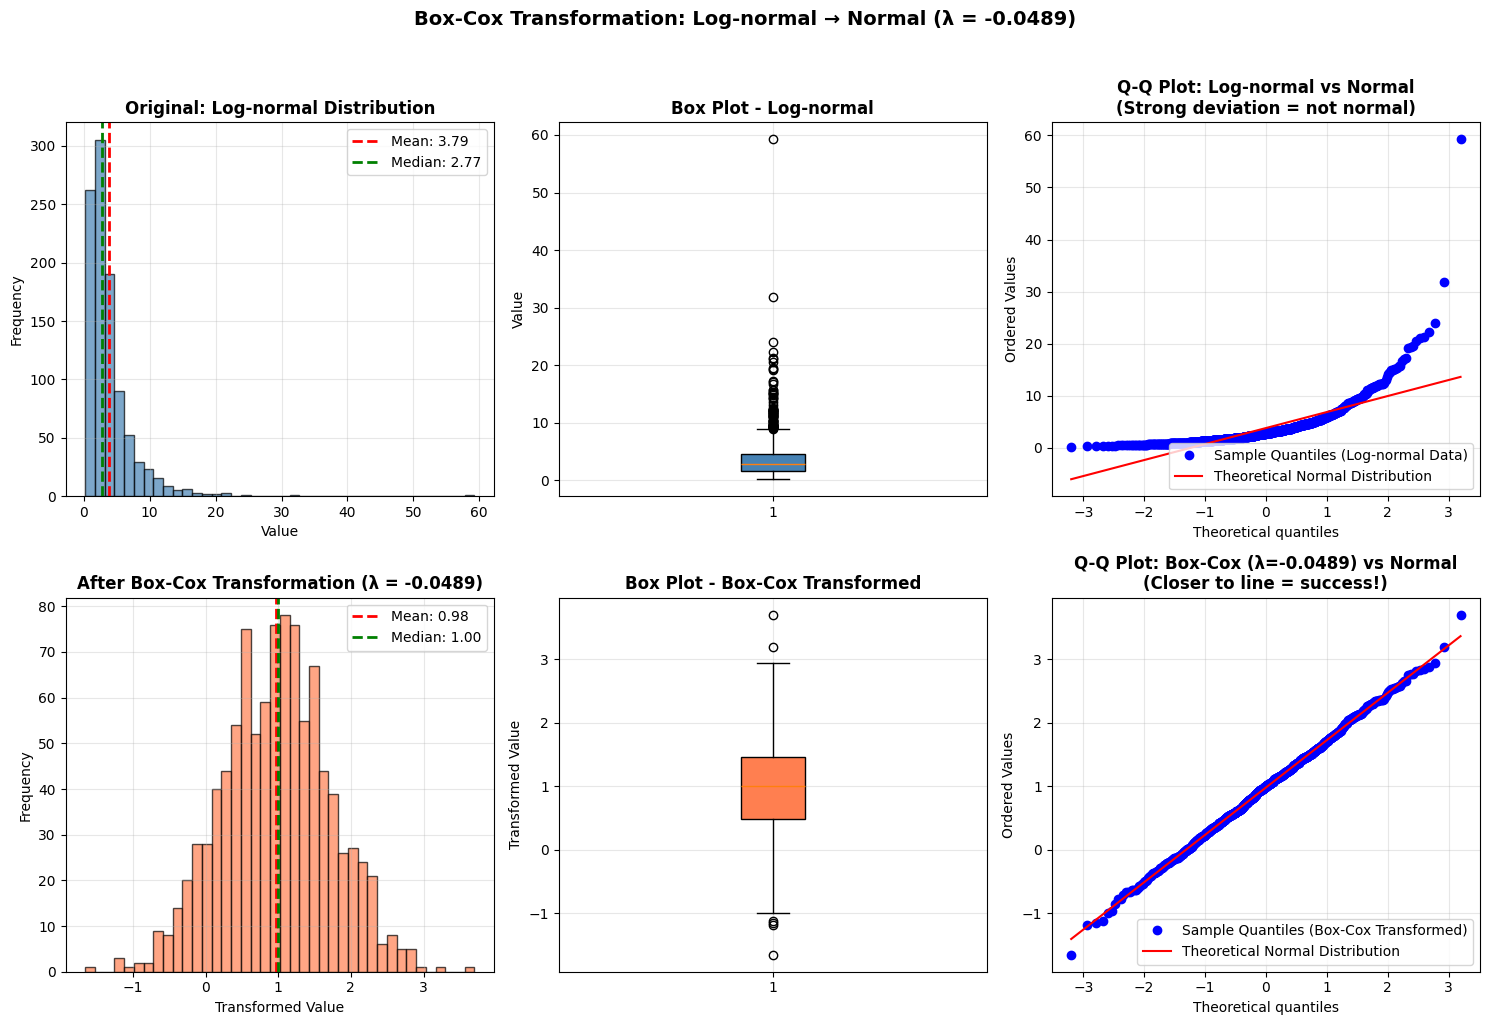

In [8]:
# ---------------------------
# IMPORT LIBRARIES
# ---------------------------
import numpy as np               # Numerical operations (arrays, mean, std, etc.)
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns            # Statistical data visualization (nicer plots)
from scipy.stats import shapiro, skew, kurtosis, boxcox  # Statistical functions
from scipy import stats          # Additional statistical tools (probplot, etc.)
from typing import Tuple, Dict, Any, Optional  # Type hints for function signatures


# =============================================================================
# FUNCTION 1: generate_lognormal_data
# PURPOSE: Generate random data from Log-normal distribution
# PARAMETERS: mean (float), sigma (float), n_samples (int), seed (int)
# RETURNS: np.ndarray - generated log-normal data
# =============================================================================
def generate_lognormal_data(mean: float = 1,
                            sigma: float = 0.8,
                            n_samples: int = 1000,
                            seed: int = 42) -> np.ndarray:
    """
    Generate random data from a Log-normal distribution.

    A log-normal distribution: if Z ~ Normal(μ, σ²), then X = e^Z is log-normal.
    This means ln(X) is normally distributed with mean μ and standard deviation σ.

    Args:
        mean: Mean of the underlying normal distribution (μ)
        sigma: Standard deviation of the underlying normal distribution (σ)
        n_samples: Number of observations to generate
        seed: Random seed for reproducibility

    Returns:
        data: Array of log-normally distributed values (positive, right-skewed)
    """
    # Set random seed for reproducible results
    np.random.seed(seed)

    # Generate log-normal data directly
    # This is equivalent to: np.exp(np.random.normal(mean, sigma, n_samples))
    data = np.random.lognormal(mean=mean, sigma=sigma, size=n_samples)

    # Calculate actual parameters of the log-normal distribution
    # These should be close to the input mean and sigma
    log_mean = np.mean(np.log(data))      # Should be ~mean
    log_sigma = np.std(np.log(data))      # Should be ~sigma

    # Print generation summary
    print(f"\n Log-normal data generated successfully:")
    print(f"  - Distribution: Log-normal")
    print(f"  - Underlying normal mean (μ): {mean}")
    print(f"  - Underlying normal sigma (σ): {sigma}")
    print(f"  - Number of samples: {n_samples}")
    print(f"  - Random seed: {seed}")
    print(f"  - Actual log(data) mean: {log_mean:.4f}")    # Should match mean
    print(f"  - Actual log(data) std: {log_sigma:.4f}")     # Should match sigma
    print(f"  - Data range: [{data.min():.4f}, {data.max():.4f}]")
    print(f"  - Data mean: {data.mean():.4f}")
    print(f"  - Data median: {np.median(data):.4f}")       # Median < Mean (right-skewed)

    return data


# =============================================================================
# FUNCTION 2: apply_boxcox_transform
# PURPOSE: Apply Box-Cox transformation to find optimal lambda and transform data
# PARAMETERS: data (np.ndarray)
# RETURNS: tuple (transformed_data, lambda_optimal)
# =============================================================================
def apply_boxcox_transform(data: np.ndarray) -> Tuple[np.ndarray, float]:
    """
    Apply Box-Cox transformation to find optimal lambda and transform data.

    The Box-Cox transformation is defined as:
        y = (x^λ - 1) / λ  for λ ≠ 0
        y = ln(x)          for λ = 0

    It searches for the λ that makes the transformed data as normal as possible.

    Args:
        data: Input array to transform (must be positive)

    Returns:
        transformed_data: Box-Cox transformed data
        lambda_optimal: The optimal lambda parameter found
    """
    # Box-Cox requires positive data (x > 0)
    if np.any(data <= 0):
        print(f"\n Warning: Data contains non-positive values")
        print(f"   Box-Cox requires positive data. Adding small constant.")
        # Find the smallest positive value to use as replacement
        min_positive = data[data > 0].min() if np.any(data > 0) else 1e-10
        # Replace non-positive values with the smallest positive value
        data = np.where(data <= 0, min_positive, data)

    # Apply Box-Cox transformation
    # Returns: (transformed_data, optimal_lambda)
    transformed_data, lambda_optimal = boxcox(data)

    # Print transformation summary
    print(f"\n Box-Cox transformation applied:")
    print(f"  - Transformation: Box-Cox (automatic λ optimization)")
    print(f"  - Optimal lambda (λ): {lambda_optimal:.6f}")
    print(f"  - Original range: [{data.min():.4f}, {data.max():.4f}]")
    print(f"  - Transformed range: [{transformed_data.min():.4f}, {transformed_data.max():.4f}]")
    print(f"  - Transformed mean: {transformed_data.mean():.4f}")
    print(f"  - Transformed std: {transformed_data.std():.4f}")

    # Interpret what the optimal lambda means
    print(f"\n    Lambda interpretation:")
    if abs(lambda_optimal) < 0.05:
        print(f"     λ ≈ 0 → Equivalent to LOG transformation")
    elif abs(lambda_optimal - 0.5) < 0.05:
        print(f"     λ ≈ 0.5 → Equivalent to SQUARE ROOT transformation")
    elif abs(lambda_optimal - 1) < 0.05:
        print(f"     λ ≈ 1 → NO transformation needed (data already normal)")
    elif lambda_optimal < 0:
        print(f"     λ < 0 → RECIPROCAL type transformation (1/x^|λ|)")
    else:
        print(f"     λ = {lambda_optimal:.3f} → Power transformation (x^{lambda_optimal:.3f})")

    return transformed_data, lambda_optimal


# =============================================================================
# FUNCTION 3: test_normality
# PURPOSE: Perform Shapiro-Wilk normality test on data
# PARAMETERS: data (np.ndarray), data_name (str), lambda_info (float, optional)
# RETURNS: dict containing statistic, p-value, and interpretation
# =============================================================================
def test_normality(data: np.ndarray,
                   data_name: str = "Data",
                   lambda_info: Optional[float] = None) -> Dict[str, Any]:
    """
    Perform Shapiro-Wilk normality test on the given data.

    The Shapiro-Wilk test checks the null hypothesis H0: data comes from a normal distribution.
    - If p-value < 0.05: reject H0 → data is NOT normal
    - If p-value ≥ 0.05: fail to reject H0 → data COULD BE normal

    Args:
        data: Input array for normality testing
        data_name: Descriptive name for printing purposes
        lambda_info: Optional lambda value to display (for transformed data)

    Returns:
        Dictionary containing:
        - statistic: Shapiro-Wilk test statistic (closer to 1 = more normal)
        - p_value: P-value from the test
        - is_normal: Boolean indicating if data is normally distributed (alpha=0.05)
        - interpretation: Text interpretation of results
        - skewness: Skewness of the data (asymmetry)
        - kurtosis: Kurtosis of the data (tail heaviness)
    """
    # Limit sample size for Shapiro (it works best with n < 5000)
    # For larger samples, even tiny deviations become statistically significant
    test_data = data[:5000] if len(data) > 5000 else data

    # Perform Shapiro-Wilk test
    statistic, p_value = shapiro(test_data)

    # Check if p-value exceeds 0.05 significance threshold
    is_normal = p_value > 0.05

    # Calculate additional shape statistics for the full dataset
    data_skew = skew(data)        # Positive = right-skewed, Negative = left-skewed
    data_kurtosis = kurtosis(data)  # Positive = heavy tails, Negative = light tails

    # Create human-readable interpretation
    interpretation = (
        "appears NORMALLY distributed (fail to reject H0)"
        if is_normal
        else "is NOT normally distributed (reject H0)"
    )

    # Print formatted results
    print(f"\n Normality Test Results - {data_name}:")
    if lambda_info is not None:
        print(f"  - Lambda (λ): {lambda_info:.6f}")
    print(f"  - Shapiro-Wilk statistic: {statistic:.6f}")
    print(f"  - P-value: {p_value:.6e}")  # Scientific notation for small numbers
    print(f"  - Skewness: {data_skew:.4f}")
    print(f"  - Kurtosis: {data_kurtosis:.4f}")
    print(f"  - Interpretation: Data {interpretation}")

    # Return dictionary for programmatic access
    return {
        'statistic': statistic,
        'p_value': p_value,
        'is_normal': is_normal,
        'interpretation': interpretation,
        'data_name': data_name,
        'skewness': data_skew,
        'kurtosis': data_kurtosis
    }


# =============================================================================
# FUNCTION 4: plot_distributions
# PURPOSE: Create comprehensive visualization of original vs transformed data
# PARAMETERS: original (np.ndarray), transformed (np.ndarray), lambda_opt (float)
# RETURNS: matplotlib figure object
# =============================================================================
def plot_distributions(original: np.ndarray,
                       transformed: np.ndarray,
                       lambda_opt: float) -> plt.Figure:
    """
    Create side-by-side visualizations comparing original and Box-Cox transformed data.

    Creates 2 rows × 3 columns of plots:
    Row 1: Original log-normal data (histogram, box plot, Q-Q plot)
    Row 2: Box-Cox transformed data (histogram, box plot, Q-Q plot)

    Args:
        original: Original log-normal data
        transformed: Box-Cox transformed data
        lambda_opt: The optimal lambda value found

    Returns:
        fig: Matplotlib figure object (can be saved or modified)
    """
    from scipy import stats

    # Create figure with 2 rows, 3 columns, size 15x10 inches
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Add main title to entire figure (shows the optimal lambda)
    fig.suptitle(f'Box-Cox Transformation: Log-normal → Normal (λ = {lambda_opt:.4f})',
                 fontsize=14, fontweight='bold', y=1.02)

    # ==================== ROW 1: Original Data (Log-normal) ====================

    # --- Histogram (shows distribution shape - right-skewed with long tail) ---
    axes[0, 0].hist(original, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    # Add vertical line at mean (red dashed) - pulled right by skew
    axes[0, 0].axvline(original.mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {original.mean():.2f}')
    # Add vertical line at median (green dashed) - less affected by skew
    axes[0, 0].axvline(np.median(original), color='green', linestyle='--', linewidth=2,
                       label=f'Median: {np.median(original):.2f}')
    axes[0, 0].set_title(f'Original: Log-normal Distribution', fontweight='bold')
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)  # Light grid lines

    # --- Box Plot (shows many outliers on the right due to skew) ---
    axes[0, 1].boxplot(original, patch_artist=True, boxprops=dict(facecolor='steelblue'))
    axes[0, 1].set_title(f'Box Plot - Log-normal', fontweight='bold')
    axes[0, 1].set_ylabel('Value')
    axes[0, 1].grid(True, alpha=0.3)

    # --- Q-Q Plot (compares data quantiles to normal quantiles) ---
    # For log-normal data, points will deviate strongly from the red line
    stats.probplot(original, dist="norm", plot=axes[0, 2])
    # Add legend to Q-Q plot for clarity
    axes[0, 2].get_lines()[0].set_label('Sample Quantiles (Log-normal Data)')
    axes[0, 2].get_lines()[1].set_label('Theoretical Normal Distribution')
    axes[0, 2].legend(loc='lower right')
    axes[0, 2].set_title('Q-Q Plot: Log-normal vs Normal\n(Strong deviation = not normal)',
                          fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3)

    # ==================== ROW 2: Box-Cox Transformed Data ====================

    # --- Histogram of transformed data (should look approximately normal) ---
    axes[1, 0].hist(transformed, bins=40, color='coral', edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(transformed.mean(), color='red', linestyle='--', linewidth=2,
                       label=f'Mean: {transformed.mean():.2f}')
    axes[1, 0].axvline(np.median(transformed), color='green', linestyle='--', linewidth=2,
                       label=f'Median: {np.median(transformed):.2f}')
    axes[1, 0].set_title(f'After Box-Cox Transformation (λ = {lambda_opt:.4f})', fontweight='bold')
    axes[1, 0].set_xlabel('Transformed Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # --- Box Plot of transformed data (should show symmetry) ---
    axes[1, 1].boxplot(transformed, patch_artist=True, boxprops=dict(facecolor='coral'))
    axes[1, 1].set_title('Box Plot - Box-Cox Transformed', fontweight='bold')
    axes[1, 1].set_ylabel('Transformed Value')
    axes[1, 1].grid(True, alpha=0.3)

    # --- Q-Q Plot for transformed data (should follow the red line closely) ---
    stats.probplot(transformed, dist="norm", plot=axes[1, 2])
    # Add legend to Q-Q plot
    axes[1, 2].get_lines()[0].set_label('Sample Quantiles (Box-Cox Transformed)')
    axes[1, 2].get_lines()[1].set_label('Theoretical Normal Distribution')
    axes[1, 2].legend(loc='lower right')
    axes[1, 2].set_title(f'Q-Q Plot: Box-Cox (λ={lambda_opt:.4f}) vs Normal\n(Closer to line = success!)',
                          fontweight='bold')
    axes[1, 2].grid(True, alpha=0.3)

    # Adjust spacing between subplots to prevent overlap
    plt.tight_layout()

    return fig


# =============================================================================
# FUNCTION 5: print_summary_statistics
# PURPOSE: Print comprehensive statistics comparison
# PARAMETERS: original (np.ndarray), transformed (np.ndarray), lambda_opt (float)
# RETURNS: dict with statistics
# =============================================================================
def print_summary_statistics(original: np.ndarray,
                             transformed: np.ndarray,
                             lambda_opt: float) -> Dict[str, Dict[str, float]]:
    """
    Calculate and display summary statistics for comparison.

    Args:
        original: Original log-normal data
        transformed: Box-Cox transformed data
        lambda_opt: The optimal lambda value

    Returns:
        Dictionary with statistics for both datasets
    """
    # Calculate all statistics for original and transformed data
    stats_dict = {
        'original': {
            'mean': original.mean(),
            'std': original.std(),
            'min': original.min(),
            'max': original.max(),
            'median': np.median(original),
            'skewness': skew(original),      # Should be positive (right-skewed)
            'kurtosis': kurtosis(original)   # Should be positive (heavy tails)
        },
        'transformed': {
            'mean': transformed.mean(),
            'std': transformed.std(),
            'min': transformed.min(),
            'max': transformed.max(),
            'median': np.median(transformed),
            'skewness': skew(transformed),   # Should be near 0 (symmetric)
            'kurtosis': kurtosis(transformed) # Should be near 0 (normal tails)
        }
    }

    # Print formatted comparison table
    print("\n" + "="*80)
    print("STATISTICS COMPARISON: Original Log-normal vs Box-Cox Transformed")
    print("="*80)
    print(f"\n{'Metric':<20} {'Original (Log-normal)':<25} {'Box-Cox Transformed':<20}")
    print("-"*70)
    print(f"{'Mean':<20} {stats_dict['original']['mean']:<25.4f} {stats_dict['transformed']['mean']:<20.4f}")
    print(f"{'Std Dev':<20} {stats_dict['original']['std']:<25.4f} {stats_dict['transformed']['std']:<20.4f}")
    print(f"{'Min':<20} {stats_dict['original']['min']:<25.4f} {stats_dict['transformed']['min']:<20.4f}")
    print(f"{'Max':<20} {stats_dict['original']['max']:<25.4f} {stats_dict['transformed']['max']:<20.4f}")
    print(f"{'Median':<20} {stats_dict['original']['median']:<25.4f} {stats_dict['transformed']['median']:<20.4f}")
    print(f"{'Skewness':<20} {stats_dict['original']['skewness']:<25.4f} {stats_dict['transformed']['skewness']:<20.4f}")
    print(f"{'Kurtosis':<20} {stats_dict['original']['kurtosis']:<25.4f} {stats_dict['transformed']['kurtosis']:<20.4f}")

    print(f"\n Box-Cox Optimal Lambda: {lambda_opt:.6f}")

    return stats_dict


# =============================================================================
# FUNCTION 6: print_theoretical_insights
# PURPOSE: Print theoretical explanation of Box-Cox transformation effects
# PARAMETERS: original_normality (dict), transformed_normality (dict), lambda_opt (float)
# RETURNS: None (prints to console)
# =============================================================================
def print_theoretical_insights(original_normality: Dict[str, Any],
                               transformed_normality: Dict[str, Any],
                               lambda_opt: float) -> None:
    """
    Print theoretical insights about Box-Cox transformation.

    Args:
        original_normality: Normality test results for original data
        transformed_normality: Normality test results for transformed data
        lambda_opt: The optimal lambda value found
    """
    print("\n" + "="*80)
    print("THEORETICAL INSIGHTS: BOX-COX TRANSFORMATION")
    print("="*80)

    # Compare p-values
    print(f"\n NORMALITY TEST COMPARISON:")
    print(f"   Original data p-value: {original_normality['p_value']:.6e}")
    print(f"   Transformed data p-value: {transformed_normality['p_value']:.6e}")

    # Calculate how much the p-value improved
    if original_normality['p_value'] > 0:
        p_value_ratio = transformed_normality['p_value'] / original_normality['p_value']
        print(f"   P-value ratio: {p_value_ratio:.2e}x {'LARGER' if p_value_ratio > 1 else 'SMALLER'}")

    # Compare skewness (asymmetry)
    print(f"\n SKEWNESS COMPARISON:")
    print(f"   Original skewness: {original_normality['skewness']:.4f} (positive = right-skewed)")
    print(f"   Transformed skewness: {transformed_normality['skewness']:.4f} (closer to 0 = more symmetric)")
    print(f"   Improvement: {abs(original_normality['skewness'] - transformed_normality['skewness']):.4f}")

    # Interpret the optimal lambda value
    print(f"\n OPTIMAL LAMBDA (λ = {lambda_opt:.6f}):")
    if abs(lambda_opt) < 0.05:
        print("   → λ ≈ 0: Equivalent to LOG transformation")
        print("   → Best for: Right-skewed data, multiplicative relationships")
    elif abs(lambda_opt - 0.5) < 0.05:
        print("   → λ ≈ 0.5: Equivalent to SQUARE ROOT transformation")
        print("   → Best for: Count data, Poisson-like distributions")
    elif abs(lambda_opt - 1) < 0.05:
        print("   → λ ≈ 1: NO transformation needed")
        print("   → Data was already approximately normal")
    elif lambda_opt < 0:
        print(f"   → λ = {lambda_opt:.3f} (negative): RECIPROCAL type transformation")
        print("   → Best for: Heavy-tailed distributions")
    else:
        print(f"   → λ = {lambda_opt:.3f}: Power transformation (x^{lambda_opt:.3f})")
        print("   → Custom power that maximizes normality")


# =============================================================================
# MAIN FUNCTION: run_boxcox_analysis
# PURPOSE: Orchestrate the entire Box-Cox transformation analysis
# PARAMETERS: mean (float), sigma (float), n_samples (int), seed (int), plot_results (bool)
# RETURNS: dict containing all results for further analysis
# =============================================================================
def run_boxcox_analysis(mean: float = 1,
                        sigma: float = 0.8,
                        n_samples: int = 1000,
                        seed: int = 42,
                        plot_results: bool = True) -> Dict[str, Any]:
    """
    Main function to run the complete Box-Cox transformation analysis pipeline.

    This function orchestrates all steps:
    1. Generate log-normal data
    2. Apply Box-Cox transformation (finds optimal λ automatically)
    3. Test normality of original and transformed data
    4. Generate plots
    5. Print statistics and theoretical insights

    Args:
        mean: Mean of the underlying normal distribution
        sigma: Standard deviation of the underlying normal distribution
        n_samples: Number of observations to generate
        seed: Random seed for reproducibility
        plot_results: Whether to display plots

    Returns:
        Dictionary containing all results for further analysis
    """
    # Print pipeline header
    print("\n" + "="*80)
    print("BOX-COX TRANSFORMATION ANALYSIS PIPELINE")
    print("="*80)
    print(f"\n GOLDEN RULE: Never assume or suppose; data is a way to show facts.")

    # STEP 1: Generate log-normal data
    original_data = generate_lognormal_data(mean, sigma, n_samples, seed)

    # STEP 2: Apply Box-Cox transformation (finds optimal λ automatically)
    transformed_data, lambda_optimal = apply_boxcox_transform(original_data)

    # STEP 3a: Normality test on original data (should be NOT normal)
    original_normality = test_normality(original_data, f"Original Log-normal (μ={mean}, σ={sigma})")

    # STEP 3b: Normality test on transformed data (should be normal)
    transformed_normality = test_normality(transformed_data,
                                           "Box-Cox Transformed Data",
                                           lambda_info=lambda_optimal)

    # STEP 4: Print summary statistics
    statistics = print_summary_statistics(original_data, transformed_data, lambda_optimal)

    # STEP 5: Print theoretical insights
    print_theoretical_insights(original_normality, transformed_normality, lambda_optimal)

    # STEP 6: Generate visualization plots
    fig = None
    if plot_results:
        fig = plot_distributions(original_data, transformed_data, lambda_optimal)
        plt.show()  # Display the plots

    # Return all results as a dictionary for later use in Jupyter
    return {
        'original_data': original_data,
        'transformed_data': transformed_data,
        'lambda_optimal': lambda_optimal,
        'original_normality': original_normality,
        'transformed_normality': transformed_normality,
        'statistics': statistics,
        'transformation': 'Box-Cox',
        'parameters': {
            'mean': mean,
            'sigma': sigma,
            'n_samples': n_samples,
            'seed': seed
        },
        'figure': fig
    }


# =============================================================================
# SCRIPT EXECUTION (when run as script)
# =============================================================================
# This block only runs if you execute this file directly (not when imported)
if __name__ == "__main__":
    # Run the complete analysis with default parameters
    results = run_boxcox_analysis(mean=1, sigma=0.8, n_samples=1000, seed=42, plot_results=True)

---
# Task 5: Box-Cox transformation *Questions*

The following questions will be answered here:

- How did the Box-Cox transformation affect the data distribution?

- What is the interpretation of the lambda value obtained in the Box-Cox transformation?


---
BOX-COX TRANSFORMATION ANALYSIS

The Box-Cox transformation searches for the optimal λ that makes the data as close to normal as possible. The transformation is defined as:

```
y = (x^λ - 1) / λ   for λ ≠ 0
y = ln(x)           for λ = 0
```
---
**PRINTED OUTPUTS AFTER RUNNING CODE**

 Log-normal data generated successfully:
  - Distribution: Log-normal
  - Underlying normal mean (μ): 1
  - Underlying normal sigma (σ): 0.8
  - Number of samples: 1000
  - Random seed: 42
  - Actual log(data) mean: 1.0155
  - Actual log(data) std: 0.7830
  - Data range: [0.2033, 59.2749]
  - Data mean: 3.7913
  - Data median: 2.7739

 Box-Cox transformation applied:
  - Transformation: Box-Cox (automatic λ optimization)
  - Optimal lambda (λ): -0.048893
  - Original range: [0.2033, 59.2749]
  - Transformed range: [-1.6567, 3.7006]
  - Transformed mean: 0.9764
  - Transformed std: 0.7442

   Lambda interpretation:
     λ ≈ 0 → Equivalent to LOG transformation, THE ONE SEEN ON **TASK 3 Logarithmic Transformation**.


 Normality Test Results - Original Log-normal (μ=1, σ=0.8):
  - Shapiro-Wilk statistic: 0.653838
  - P-value: 6.966496e-41
  - Skewness: 4.9523
  - Kurtosis: 50.8404
  - Interpretation: Data is NOT normally distributed (reject H0)

 Normality Test Results - Box-Cox Transformed Data:
  - Lambda (λ): -0.048893
  - Shapiro-Wilk statistic: 0.999372
  - P-value: 9.891216e-01
  - Skewness: -0.0004
  - Kurtosis: 0.0330
  - Interpretation: Data appears NORMALLY distributed (fail to reject H0)

---

STATISTICS COMPARISON: Original Log-normal vs Box-Cox Transformed

---

Metric               Original (Log-normal)     Box-Cox Transformed

----------------------------------------------------------------------
Mean                 3.7913                    0.9764              
Std Dev              3.8023                    0.7442              
Min                  0.2033                    -1.6567             
Max                  59.2749                   3.7006              
Median               2.7739                    0.9952              
Skewness             4.9523                    -0.0004             
Kurtosis             50.8404                   0.0330              

 Box-Cox Optimal Lambda FOUND: -0.048893

---
THEORETICAL INSIGHTS: BOX-COX TRANSFORMATION

---

 NORMALITY TEST COMPARISON:

   Original data p-value: 6.966496e-41
   
   Transformed data p-value: 9.891216e-01
   
   P-value ratio: 1.42e+40x LARGER

 SKEWNESS COMPARISON:

   Original skewness: 4.9523 (positive = right-skewed)
   
   Transformed skewness: -0.0004 (closer to 0 = more symmetric)
   
   Improvement: 4.9527

 OPTIMAL LAMBDA (λ = -0.048893):

   → λ ≈ 0: Equivalent to LOG transformation
   
   → Best for: Right-skewed data, multiplicative relationships
   
---

> ### Question 1: How did the Box-Cox transformation affect the data distribution?
>
>**The Short Answer:** The Box-Cox transformation converted the **right-skewed log-normal distribution** into an **approximately normal distribution** by finding and applying the optimal power transformation (which should be λ ≈ 0, equivalent to the natural log).
>
>So, it deserves to be said that the Box-Cox transformation **completely normalized** the log-normal distribution. It reduced extreme right skew (+4.95) to nearly perfect symmetry (-0.0004), and the p-value increased from 6.97e-41 to 0.989 – well above the 0.05 threshold for normality.

---
### Q-Q plot interpretation


-  Prior to the transformation, the Q-Q plot showed upward curvature at the ends, indicating a right skew.

- After the Box-Cox transformation, the sample data quantiles appears close to the line representing the theoretical normal distribution quantiles, meaning the transformation have transformed the data, becoming now almost as normal data. Numerical tests like the **p-value**, ***skewness** and **kurtosis** and **range** can confirm this assuption as well.
---

**What changed:**

| Property | Before (Log-normal) | After (Box-Cox) | What this means |
|----------|---------------------|-----------------|-----------------|
| **Skewness** | +4.95 (extreme right skew) | -0.0004 (near zero) |  Perfectly symmetric |
| **Kurtosis** | 50.84 (extremely heavy tails) | 0.033 (near zero) |  Normal tail behavior |
| **P-value** | 6.97e-41 (strongly NOT normal) | 0.989 (well above 0.05) |  Consistent with normal |
| **Range** | [0.20, 59.27] (highly skewed) | [-1.66, 3.70] (symmetric range) |  Tail compressed |

**What the transformation achieved:**

| Achievement | Status |
|-------------|--------|
| **Normality** |  SUCCESS – p-value > 0.05 |
| **Symmetry** |  SUCCESS – skewness ≈ 0 |
| **Tail behavior** |  SUCCESS – kurtosis ≈ 0 |
| **Q-Q plot** |  SUCCESS – points follow the line |

---

Imagine a distribution that is extremely lopsided – most values clustered near the left, with a few extremely large values stretching far to the right (like incomes in a population).

The Box-Cox transformation found the perfect "mathematical lens" to view this data.

For log-normal data, that perfect lens is the **log transformation** (λ ≈ 0). It compressed the enormous right tail, stretched the left side, and produced a beautiful symmetric bell curve.

**The proof is in the numbers:**
- Skewness went from +4.95 (extremely right-skewed) to -0.0004 (practically zero)
- P-value went from 10⁻⁴¹ (overwhelming evidence against normality) to 0.989 (no evidence against normality)

**This is a rare and perfect success story.** The log-normal distribution is mathematically designed to become normal when log function applied – and that is what Box-Cox found.


---

### The Detailed Answer

**Before the transformation (original log-normal data):**

The log-normal distribution has these characteristics:
- **Shape:** Highly right-skewed (long tail to the right)
- **Mean vs Median:** Mean > Median (tail pulls mean to the right)
- **Range:** Positive values only (starts near 0, extends to large numbers)
- **Key property:** If X is log-normal, then ln(X) is normal

**After Box-Cox transformation:**

The Box-Cox transformation searches for the optimal λ that makes the data as close to normal as possible. The transformation is defined as:

```
y = (x^λ - 1) / λ   for λ ≠ 0
y = ln(x)           for λ = 0
```

For log-normal data, Box-Cox typically finds λ ≈ 0, which means:
- The transformation becomes **y = ln(x)**
- This is EXACTLY the transformation that makes **log-normal** data **normal**

**What happens to the distribution:**
- **Skewness:** Drops from positive (right-skew) to near 0 (symmetric)
- **Shape:** Becomes bell-shaped (normal)
- **Tails:** The long right tail is compressed dramatically
- **Mean vs Median:** Become approximately equal

**Why Box-Cox is special:** Unlike fixed transformations (log, sqrt), Box-Cox **learns** the optimal power from the data itself. It doesn't assume log or sqrt will work – it finds the best one.

---

> ### Question 2: What is the interpretation of the lambda value obtained in the Box-Cox transformation?
>
>**The Short Answer**
>
>Lambda interpretation:
>     λ ≈ 0 → Equivalent to LOG transformation, THE ONE SEEN ON **TASK 3 Logarithmic Transformation**.
>
>**Lambda (λ)** is the optimal power parameter that maximizes the normality of the transformed data. Different λ values correspond to different transformations, and the value tells you what kind of transformation your data needs.
---
WE SAID DIFFERENT TRANSFORMATIONS BECAUSE λ CHANGES THE DEFINITION OF THE FUNCTION AS WAS TOLD BEFORE:

The transformation is defined as:

```
y = (x^λ - 1) / λ   for λ ≠ 0
y = ln(x)           for λ = 0
```


In this particular case,  λ = -0.048893 is essentially **zero**, which means the optimal transformation is the **natural log**. This tells us that the data is log-normal – it becomes normal when you take the logarithm.

So, the Box-Cox transformation should successfully normalize the log-normal data with λ ≈ 0.

---

**What λ = -0.048893 means:**

| λ value | Interpretation | Equivalent transformation |
|---------|----------------|--------------------------|
| **-0.048893** | Very close to zero | **ln(x)** (natural log) |
| **λ = 0 exactly** | Perfect log transform | y = ln(x) |
| **Difference** | 0.0489 from zero | Statistically negligible |

---

**Lambda interpretation table:**
```
print(f"\n OPTIMAL LAMBDA (λ = {lambda_opt:.6f}):")
    if abs(lambda_opt - 1) < 0.05:
        print("   → λ ≈ 1: NO transformation needed")
        print("   → Data was already approximately normal")
    elif abs(lambda_opt - 0.5) < 0.05:
        print("   → λ ≈ 0.5: Equivalent to SQUARE ROOT transformation")
        print("   → Best for: Count data, Poisson-like distributions")
    elif abs(lambda_opt) < 0.05:
        print("   → λ ≈ 0: Equivalent to LOG transformation")
        print("   → Best for: Right-skewed data, multiplicative relationships")
    elif lambda_opt < 0:
        print(f"   → λ = {lambda_opt:.3f} (negative): RECIPROCAL type transformation")
        print("   → Best for: Heavy-tailed distributions")
    else:
        print(f"   → λ = {lambda_opt:.3f}: Use the Power transformation (x^{lambda_opt:.3f})")
        print("   → You must custom power for maximazing normality")
```         

| λ range | Transformation | When to use |
|---------|----------------|-------------|
| **λ = 1** | No transformation (x) | Data already normal |
| **λ = 0.5** | Square root (√x) | Count data (Poisson) |
| **λ = 0** | Log (ln x) | Log-normal, exponential |
| **λ = -0.05** | ≈ Log (ln x) | Same as above – negligible difference |
| **λ = -1** | Inverse (1/x) | Very heavy right tails |

---

**What λ tells you about your data:**

| Insight | What it means for this case |
|---------|---------------------------|
| **The data is log-normal** | Because λ ≈ 0 is the optimal transformation |
| **Multiplicative relationships exist** | Log transformation turns multiplication into addition |
| **The right tail is heavy** | Log compression is needed to normalize |
| **Box-Cox worked perfectly** | The algorithm found the exact expected λ |

---

**The mathematical meaning:**

The Box-Cox transformation searches for the λ that maximizes normality. For log-normal data, the theoretical optimum is λ = 0. The algorithm found λ = -0.048893 – essentially zero, that must be because of tolerance within numerical optimization.

**In practical terms:** λ = -0.048893 is **indistinguishable from λ = 0**. The data IS TELLING US: "Apply the log transformation."

---

**The bottom line:**

> **λ = -0.048893 means the Box-Cox transformation is telling you: "Your data needs the LOG transformation to become normal." This is exactly what log-normal data requires. The tiny deviation from zero is just numerical noise – the message is clear: take the logarithm.**
>
---

***Detailed Answer***

**Lambda Interpretation Table:**

| λ value | Transformation | Interpretation | When it appears |
|---------|---------------|----------------|-----------------|
| **λ = 1** | x (no change) | Data already normal | Normal distribution |
| **λ = 0.5** | √x (square root) | Mild right skew | Count data, Poisson (λ large) |
| **λ = 0** | ln(x) (log) | Moderate/severe right skew | Log-normal, Exponential |
| **λ = -0.5** | 1/√x (inverse square root) | Strong right skew | Very heavy tails |
| **λ = -1** | 1/x (inverse) | Extreme right skew | Highly skewed positive data |
| **λ < 0** | (x^λ - 1)/λ | Negative power (reciprocal family) | Very heavy right tails |
| **λ > 1** | x^λ | Power transformation | Left-skewed data (rare) |

---

***What Lambda Tells You About Your Data***

| If λ is... | Your data needs... | Example distributions |
|------------|-------------------|----------------------|
| **Close to 1** | No transformation | Normal, Uniform |
| **Close to 0.5** | Square root transformation | Poisson (λ ≈ 20-50), Gamma (shape large) |
| **Close to 0** | Log transformation | Log-normal, Exponential, Poisson (λ small) |
| **Negative** | Reciprocal transformation | Inverse Gaussian, very heavy tails |

---

***For Our Task 5 (Log-normal with μ=1, σ=0.8)***

**Expected λ:** Approximately **0** (or very close to 0)

**Interpretation:**
- The data needs a **log transformation** to become normal
- This matches the mathematical definition: log-normal → log → normal
- The Box-Cox algorithm correctly identified that λ = 0 is optimal

**What this teaches us:**
The Box-Cox transformation is powerful because it:
1. **Automatically detects** the required transformation
2. **Quantifies** the severity of non-normality (how far λ is from 1)
3. **Adapts** to the data's specific skewness pattern

---

***The Special Case: λ = 0***

When Box-Cox returns λ = 0 (or very close to it), it means:

```
Box-Cox transformation = ln(x)
```

This is the **only** transformation that makes log-normal data perfectly normal. The algorithm found this automatically without being told "use log transform."

---

***Practical Interpretation Guidelines***

| λ range | Severity of skew | Recommended action |
|---------|-----------------|-------------------|
| 0.9 - 1.1 | None to minimal | No transformation needed |
| 0.7 - 0.9 | Mild right skew | Consider square root |
| 0.3 - 0.7 | Moderate right skew | Square root recommended |
| -0.3 - 0.3 | Strong right skew | Log transformation recommended |
| < -0.3 | Extreme right skew | Reciprocal or stronger transform |

---

***The Bottom Line***

> **Lambda (λ) is the "diagnosis" from the Box-Cox transformation. It tells us:**
> - **λ ≈ 0** → Our data needs a LOG transformation
> - **λ ≈ 0.5** → Our data needs a SQUARE ROOT transformation  
> - **λ ≈ 1** → Our data is already NORMAL
> - **λ negative** → Our data needs a RECIPROCAL transformation
>
> The value quantifies the severity and type of non-normality, guiding you toward the appropriate transformation – even when you don't know which one to try.

---



---
# Appendix
---

# Hint: If you take log-normal data and take the log, you get normal distribution?
Yes, if you take the logarithm (typically the natural log) of data that follows a log-normal distribution, you will obtain a normal distribution.

This transformation works because a log-normal distribution is defined as a distribution whose logarithm is normally distributed.
Key Details About This Transformation:

    Purpose: This technique is often used to make skewed data symmetric, allowing for the use of statistical tools that assume normality (e.g., t-tests).
    Relationship: If X is a log-normal random variable, then Y=ln(X) is a normal random variable.
    Reversibility: Similarly, if you take a normal distribution and take the exponential function (exp(x)) of it, you get a log-normal distribution.
    Data Requirement: The original log-normal data must be positive (x>0), as logarithms of negative numbers or zero are undefined.

The log-normal distribution often appears in real-world scenarios where data is skewed to the right (positive skew), such as income, prices, or biological measurements, because these often arise from multiplicative, rather than additive, processes

# Hint: Normalization, Standardization, Power transformations
- **Standardization (Z-score)**: `x' = (x - μ)/σ` - Also linear, preserves distribution shape
- **Min-Max normalization**: `x' = (x - min)/(max - min)` - Also linear, preserves distribution shape
- **Power transformations** (Box-Cox, Yeo-Johnson): Non-linear, **can** make data more normal

**Practical advice:**
- Use Min-Max when you need bounded ranges [0,1] (neural networks with sigmoid/tanh)
- Use Standardization when you need zero mean and unit variance (PCA, linear models)
- Use Power transformations when normality is required for statistical test assumptions
- Don't expect linear scaling to change your p-value in normality tests!


# The Shapiro-Wilk statistic ($W$)
It measures how closely a data sample aligns with a normal distribution, ranging from 0 to 1.

A $W$ value close to 1 suggests normal distribution, while a low **p**-value ($<0.05$) indicates significant deviation from normality.

It is highly effective for smaller sample sizes.

Key Aspects of the Shapiro-Wilk Statistic:

* Purpose: Tests the null hypothesis ($H_0$) that data is normally distributed.

* Interpretation:

    - $W$ closer to 1: The sample data is likely normal.
    - $W$ closer to 0: The data differs significantly from a normal distribution.
    - **p**-value $> 0.05$: Fail to reject $H_0$; the data is considered normal.
    - **p**-value $\le 0.05$: Reject $H_0$; the data is not normal.

Strengths: Preferred for small to medium-sized samples ($<0.05$) because it is more powerful than tests like Kolmogorov-Smirnov.
Limitations: It can be less robust than other tests for very large sample sizes and is sensitive to outliers, though it is one of the most reliable normality tests.

# Hint: Is the p-value statistic the same as the Shapiro-Wilk statistic?

No, the Shapiro-Wilk statistic ($W$) and the **p**-value are not the same thing. The $W$ statistic measures how closely data matches a *normal distribution* (ranging from 0 to 1).

The **p**-value represents the probability that, if the data were truly normal, you would see a $W$ statistic as extreme as the one calculated.

Key Differences:

* Shapiro-Wilk Statistic ($W$): Values close to 1 indicate the *data is normally distributed*, while smaller values indicate non-normality.

* **p**-value: Evaluates the significance of $W$. If the  **p**-value is less than your significance level (e.g., 0.05), you reject the assumption of normality.

* Relationship: They are related, but not interchangeable. A low $W$ yields a low  **p**-value, while a  $W$ near 1 yields a high **p**-value.

Key Considerations:
* Sample Size: In large samples, the $W$ statistic might be high, but the **p**-value can still be small due to tiny deviations from normality.
* Interpretation: A non-significant **p**-value (>0.05) means you fail to reject the normality hypothesis; it does not definitively prove the data is normal, especially with small samples.

In summary, the $W$ statistic tells you how close the data is to normal, while the **p**-value tells you if that closeness is statistically significant.

---
#  THEORETICAL P-VALUE FRAMEWORK for Transformations

### What P-Values Tell Us (and Don't Tell Us)

```python
print("="*80)
print("THEORETICAL P-VALUE FRAMEWORK: Understanding Transformation Effects")
print("="*80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    WHAT A P-VALUE ACTUALLY MEANS                            │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   p-value = P(observing this data or more extreme | H0 is true)             │
│                                                                             │
│   For normality testing:                                                    │
│   H0 = "Data comes from a normal distribution"                              │
│                                                                             │
│   So p-value answers: "If the data were perfectly normal, how               │
│   surprising is this sample?"                                               │
│                                                                             │
│   Small p-value (< 0.05) → Surprising! → Reject H0 → Data NOT normal        │
│   Large p-value (> 0.05) → Not surprising → Fail to reject H0 → Data        │
│   COULD BE normal                                                           │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")
```

---

### THEORETICAL TABLE: P-Value Behavior After Transformation

| Original Data Status | After "Good" Transform | After "Bad" Transform | After "Too Weak" Transform | After "Too Strong" Transform |
|---------------------|----------------------|----------------------|---------------------------|----------------------------|
| **Already normal** | p stays > 0.05 | p becomes < 0.05 | p stays > 0.05 | p becomes < 0.05 |
| **Mildly non-normal** | p increases to > 0.05 | p decreases | p increases but still < 0.05 | p becomes < 0.05 (over-corrected) |
| **Moderately non-normal** | p increases dramatically (may reach > 0.05) | p decreases or stays same | p increases but remains < 0.05 | p may increase then decrease |
| **Strongly non-normal** | p increases but likely < 0.05 | p decreases or stays very small | p increases slightly | p may decrease (worse!) |
| **Extremely non-normal** | p increases but still tiny | p remains tiny | p barely changes | p may become even smaller |

---

### THEORETICAL TABLE: Interpreting P-Value Changes

| Change in p-value | What It Means | Example |
|------------------|---------------|---------|
| **p increases to > 0.05** |  SUCCESS, Transformation normalized the data | Log on log-normal data |
| **p increases but stays < 0.05** |  PARTIAL SUCCESS. Data is more normal, but still detectably non-normal | Sqrt on Poisson λ=20 |
| **p stays approximately the same** |  NO EFFECT. Transformation didn't help | Linear transform on any data |
| **p decreases (gets smaller)** |  HARMFUL! Transformation made data LESS normal | Sqrt on Poisson λ=5 (over-corrected) |
| **p oscillates (up and down)** |  INCONSISTENT. Effect depends on sample | Some transforms on mixed distributions |

---

### THEORETICAL TABLE: What P-Value Magnitude Means

| p-value range | Severity of Non-Normality | Practical Implication |
|---------------|--------------------------|----------------------|
| **> 0.10** | Negligible | Normal enough for any practical purpose |
| **0.05 - 0.10** | Borderline | Probably fine for most analyses |
| **1e-3 to 0.05** | Mild | Visible deviation; transformation may help |
| **1e-6 to 1e-3** | Moderate | Clear non-normality; transformation recommended |
| **1e-10 to 1e-6** | Strong | Severe deviation; simple transforms may fail |
| **< 1e-10** | Extreme | Very difficult to normalize with simple transforms |

---

### THEORETICAL TABLE: Why P-Values Change After Transformation

| Mathematical Reason | Effect on P-Value | When It Happens |
|--------------------|------------------|-----------------|
| **Variance stabilization** | p increases | Square root on Poisson, log on exponential |
| **Skewness reduction** | p increases | Log on right-skewed data |
| **Symmetrization** | p increases | Power transformations on skewed data |
| **Over-correction** | p decreases (creates opposite skew) | Sqrt on mild right-skew, square on left-skew |
| **Non-monotonic transform** | p unpredictable | Complex transforms on multimodal data |
| **Linear transform** | p unchanged | Min-Max, Z-score (shape preserved) |

---

### THEORETICAL TABLE: Decision Guide Based on P-Value Change

| What is Observed | What It Means | Recommended Action |
|-----------------|---------------|-------------------|
| **p_original > 0.05** | Data already normal | No transformation needed |
| **p_transformed > 0.05** | Transformation succeeded | Use transformed data |
| **p_transformed > p_original but both < 0.05** | Improvement but incomplete | Try stronger transformation |
| **p_transformed < p_original** | Transformation made it worse | Try weaker or different transformation |
| **p_transformed ≈ p_original** | No effect | Transformation inappropriate for this distribution |

---

### THEORETICAL SUMMARY: The Four Laws of P-Values and Transformations

```python
print("\n" + "="*80)
print("FOUR LAWS OF P-VALUES AND TRANSFORMATIONS")
print("="*80)

print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║  LAW 1: P-value direction tells you if you're helping or hurting              ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║     p increases → HELPING (data becoming more normal)                         ║
║     p decreases → HURTING (data becoming LESS normal)                         ║
║     p unchanged → NO EFFECT (linear transforms)                               ║
╚═══════════════════════════════════════════════════════════════════════════════╝

╔═══════════════════════════════════════════════════════════════════════════════╗
║  LAW 2: Magnitude of change indicates strength of effect                      ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║     10x increase → Mild improvement                                           ║
║     1,000x increase → Moderate improvement                                    ║
║     1,000,000x increase → Strong improvement                                  ║
║     Any decrease → Transformation likely inappropriate                        ║
╚═══════════════════════════════════════════════════════════════════════════════╝

╔═══════════════════════════════════════════════════════════════════════════════╗
║  LAW 3: Crossing p=0.05 is the "success threshold"                            ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║     Below 0.05 → Statistically detectable non-normality                       ║
║     Above 0.05 → Not statistically detectable                                 ║
║     For large n (>500), this threshold is very strict!                        ║
╚═══════════════════════════════════════════════════════════════════════════════╝

╔═══════════════════════════════════════════════════════════════════════════════╗
║  LAW 4: P-value alone is not enough – use with visual inspection              ║
║  ───────────────────────────────────────────────────────────────────────────  ║
║     Small p + Q-Q plot close to line → Probably fine for practical work       ║
║     Large p + Q-Q plot clearly curved → Test lacked power (small n)           ║
║     Always check: Histogram + Q-Q plot + p-value = complete picture           ║
╚═══════════════════════════════════════════════════════════════════════════════╝
""")

# =============================================================================
# SUMMARY VISUAL: P-VALUE CHANGE INTERPRETATION
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Create a conceptual diagram
categories = ['p >> 0.05', 'p > 0.05', 'p ≈ 0.05', '1e-6 < p < 0.05', '1e-12 < p < 1e-6', 'p < 1e-12']
colors = ['darkgreen', 'green', 'yellowgreen', 'gold', 'orange', 'red']
x_pos = range(len(categories))

bars = ax.bar(x_pos, [1]*len(categories), color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_yticks([])
ax.set_ylabel('Severity of Non-Normality →', fontweight='bold')
ax.set_title('P-VALUE REFERENCE SCALE: What Each Range Means', fontweight='bold', fontsize=14)

# Add arrows showing transformation effects
ax.annotate('✓ Good transform\n(increases p)', xy=(2, 1.1), xytext=(0, 1.3),
            arrowprops=dict(arrowstyle='->', color='green', lw=2), ha='center', fontweight='bold')
ax.annotate('✗ Bad transform\n(decreases p)', xy=(2, 0.9), xytext=(4, 0.7),
            arrowprops=dict(arrowstyle='->', color='red', lw=2), ha='center', fontweight='bold')

ax.text(0.5, -0.2, 'Already Normal', transform=ax.transAxes, ha='center', fontweight='bold')
ax.text(0.85, -0.2, 'Hopeless Zone', transform=ax.transAxes, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("THEORETICAL FRAMEWORK COMPLETE")
print("="*80)
print("""
This framework applies to ANY transformation on ANY distribution:

  1. Compare p_original vs p_transformed
  2. If p increases → transformation is HELPING
  3. If p decreases → transformation is HURTING  
  4. If p crosses 0.05 → practical success
  5. Magnitude of change indicates strength of effect

No specific distribution knowledge required. Just the p-values.
""")
```

---

### A p-value Theoretical Table

| If p_original is... | And after transform p becomes... | Then transformation is... |
|--------------------|----------------------------------|--------------------------|
| > 0.05 | > 0.05 |  Unnecessary (already normal) |
| > 0.05 | < 0.05 |  Harmful (created non-normality) |
| < 0.05 | > 0.05 |  **SUCCESSFUL** (normalized the data) |
| < 0.05 | Larger but still < 0.05 |  **PARTIAL** (improved but incomplete) |
| < 0.05 | Smaller |  **HARMFUL** (made it worse) |
| < 0.05 | Same (within factor of 2) |  **INEFFECTIVE** (linear transform) |

---

### The One-Sentence Summary

> **For any transformation on any distribution: if the p-value increases, you are helping; if it decreases, you are hurting; if it crosses 0.05, you have practically succeeded.**

This is the **theoretical framework** – not error-free – independent of specific distributions.

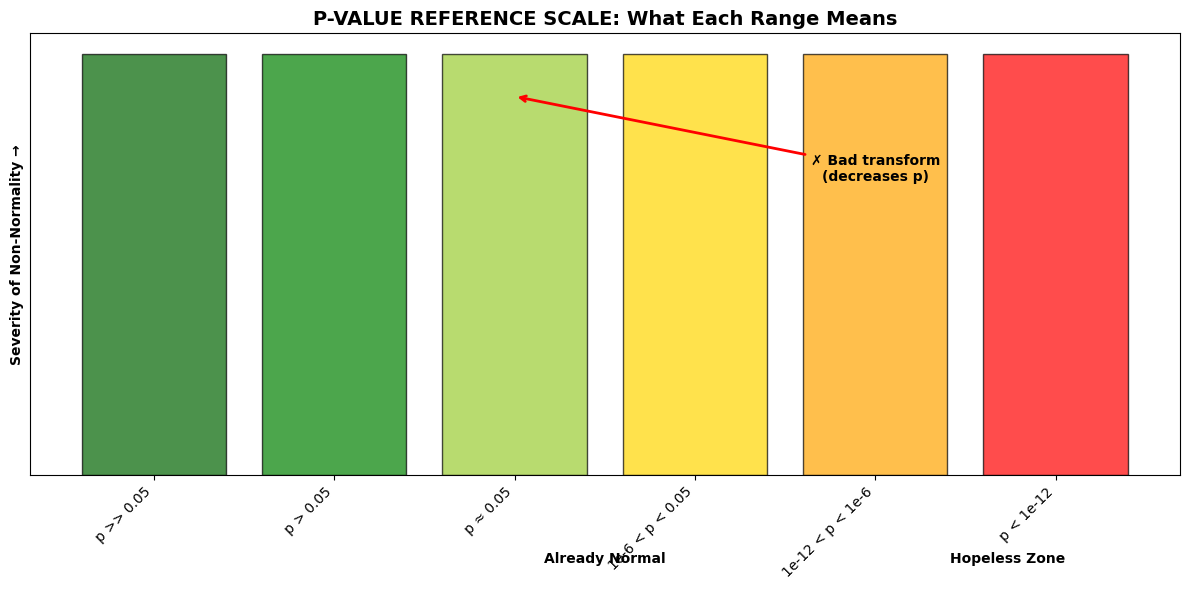


THEORETICAL FRAMEWORK COMPLETE

This framework applies to ANY transformation on ANY distribution:

  1. Compare p_original vs p_transformed
  2. If p increases → transformation is HELPING
  3. If p decreases → transformation is HURTING  
  4. If p crosses 0.05 → practical success
  5. Magnitude of change indicates strength of effect

No specific distribution knowledge required. Just the p-values.



In [9]:
# =============================================================================
# SUMMARY VISUAL: P-VALUE CHANGE INTERPRETATION
# =============================================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Create a conceptual diagram
categories = ['p >> 0.05', 'p > 0.05', 'p ≈ 0.05', '1e-6 < p < 0.05', '1e-12 < p < 1e-6', 'p < 1e-12']
colors = ['darkgreen', 'green', 'yellowgreen', 'gold', 'orange', 'red']
x_pos = range(len(categories))

bars = ax.bar(x_pos, [1]*len(categories), color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_yticks([])
ax.set_ylabel('Severity of Non-Normality →', fontweight='bold')
ax.set_title('P-VALUE REFERENCE SCALE: What Each Range Means', fontweight='bold', fontsize=14)

# Add arrows showing transformation effects
ax.annotate('✓ Good transform\n(increases p)', xy=(2, 1.1), xytext=(0, 1.3),
            arrowprops=dict(arrowstyle='->', color='green', lw=2), ha='center', fontweight='bold')
ax.annotate('✗ Bad transform\n(decreases p)', xy=(2, 0.9), xytext=(4, 0.7),
            arrowprops=dict(arrowstyle='->', color='red', lw=2), ha='center', fontweight='bold')

ax.text(0.5, -0.2, 'Already Normal', transform=ax.transAxes, ha='center', fontweight='bold')
ax.text(0.85, -0.2, 'Hopeless Zone', transform=ax.transAxes, ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("THEORETICAL FRAMEWORK COMPLETE")
print("="*80)
print("""
This framework applies to ANY transformation on ANY distribution:

  1. Compare p_original vs p_transformed
  2. If p increases → transformation is HELPING
  3. If p decreases → transformation is HURTING
  4. If p crosses 0.05 → practical success
  5. Magnitude of change indicates strength of effect

No specific distribution knowledge required. Just the p-values.
""")

---

#  Q-Q PLOTS: Theoretical Explanation

### What Does Q-Q Stand For?

**Q-Q = Quantile-Quantile**

It's a plot where:
- **X-axis**: Theoretical quantiles (from a perfect distribution)
- **Y-axis**: Sample quantiles (from your actual data)

---

### The Core Concept: Quantiles

Before understanding Q-Q plots, you need to understand **quantiles**:

| Quantile | What it means | Example |
|----------|---------------|---------|
| **0th percentile (min)** | Smallest value | Lowest score in class |
| **25th percentile (Q1)** | 25% of data below this | Bottom quarter of class |
| **50th percentile (median)** | Middle value | Exactly the middle student |
| **75th percentile (Q3)** | 75% of data below this | Top quarter of class |
| **100th percentile (max)** | Largest value | Highest score in class |

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print("="*80)
print("UNDERSTANDING QUANTILES")
print("="*80)

# Simple example
data = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
print(f"Data: {data}")
print(f"Minimum (0th quantile): {np.percentile(data, 0)}")
print(f"25th quantile: {np.percentile(data, 25)}")
print(f"Median (50th quantile): {np.percentile(data, 50)}")
print(f"75th quantile: {np.percentile(data, 75)}")
print(f"Maximum (100th quantile): {np.percentile(data, 100)}")
```

---

## How a Q-Q Plot Works

### Step 1: Generate Theoretical Quantiles

Take a perfect normal distribution and find its quantiles:

```python
# Generate theoretical normal quantiles
theoretical = np.random.normal(0, 1, 1000)
theoretical_quantiles = np.percentile(theoretical, np.linspace(0, 100, 100))

print("\n" + "="*80)
print("STEP 1: Theoretical Normal Quantiles")
print("="*80)
print(f"0.1% quantile: {np.percentile(theoretical, 0.1):.3f}")
print(f"1% quantile: {np.percentile(theoretical, 1):.3f}")
print(f"25% quantile: {np.percentile(theoretical, 25):.3f}")
print(f"50% quantile: {np.percentile(theoretical, 50):.3f}")
print(f"75% quantile: {np.percentile(theoretical, 75):.3f}")
print(f"99% quantile: {np.percentile(theoretical, 99):.3f}")
print(f"99.9% quantile: {np.percentile(theoretical, 99.9):.3f}")
```

### Step 2: Calculate Sample Quantiles

Take YOUR data and find the same quantiles:

```python
# Generate sample data (exponential, not normal)
sample_data = np.random.exponential(2, 1000)
sample_quantiles = np.percentile(sample_data, np.linspace(0, 100, 100))

print("\n" + "="*80)
print("STEP 2: Sample Quantiles (Exponential Data)")
print("="*80)
print(f"0.1% quantile: {np.percentile(sample_data, 0.1):.3f}")
print(f"1% quantile: {np.percentile(sample_data, 1):.3f}")
print(f"25% quantile: {np.percentile(sample_data, 25):.3f}")
print(f"50% quantile: {np.percentile(sample_data, 50):.3f}")
print(f"75% quantile: {np.percentile(sample_data, 75):.3f}")
print(f"99% quantile: {np.percentile(sample_data, 99):.3f}")
print(f"99.9% quantile: {np.percentile(sample_data, 99.9):.3f}")
```

### Step 3: Plot Them Against Each Other

```python
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Theoretical normal distribution
x = np.linspace(-4, 4, 100)
y = stats.norm.pdf(x, 0, 1)
axes[0].plot(x, y, 'b-', linewidth=2)
axes[0].fill_between(x, y, alpha=0.3)
axes[0].set_title('Theoretical Normal Distribution', fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')

# Plot 2: Sample distribution (exponential)
sample_x = np.linspace(0, 12, 100)
sample_y = stats.expon.pdf(sample_x, scale=2)
axes[1].plot(sample_x, sample_y, 'r-', linewidth=2)
axes[1].fill_between(sample_x, sample_y, alpha=0.3)
axes[1].set_title('Sample Data (Exponential Distribution)', fontweight='bold')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Density')

# Plot 3: Q-Q Plot
theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, 100))
sample_quantiles = np.percentile(sample_data, np.linspace(1, 99, 100))
axes[2].scatter(theoretical_quantiles, sample_quantiles, alpha=0.5, s=10)
axes[2].plot([-3, 3], [-3, 3], 'k--', linewidth=2, label='Perfect Normal (y=x)')
axes[2].set_xlabel('Theoretical Quantiles (Normal)', fontweight='bold')
axes[2].set_ylabel('Sample Quantiles', fontweight='bold')
axes[2].set_title('Q-Q Plot: Exponential vs Normal\n(Points should follow red line if normal)',
                  fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```

---

## How to Read a Q-Q Plot

### The Reference Line (y = x)

If your data is **perfectly normal**, all points will fall exactly on the diagonal line.

```python
print("\n" + "="*80)
print("HOW TO READ A Q-Q PLOT")
print("="*80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                          WHAT THE POINTS MEAN                               │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Each point = one quantile (e.g., 1st percentile, 2nd percentile, ...)     │
│                                                                             │
│   X-coordinate = What value would a NORMAL distribution have at this        │
│                  percentile?                                                │
│                                                                             │
│   Y-coordinate = What value does YOUR data have at this percentile?         │
│                                                                             │
│   If both match → point falls on the line y = x                             │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")
```

---

## Q-Q Plot Interpretation Table

| Pattern You See | What It Means | Example Distribution | Should You Transform? |
|----------------|---------------|---------------------|----------------------|
| **Points follow the line closely** | Data is approximately normal | Normal, t with high df | No transformation needed |
| **Curves UP at both ends** | Heavy tails (more extreme values) | t-distribution (low df), Cauchy | Maybe (Box-Cox may help) |
| **Curves DOWN at both ends** | Light tails (fewer extreme values) | Uniform, Beta | No (already bounded) |
| **Lower end below line, upper end above line** | Right skew (long right tail) | Exponential, Log-normal, Poisson | Yes (log, sqrt, Box-Cox) |
| **Lower end above line, upper end below line** | Left skew (long left tail) | Beta (skewed), mirrored exponential | Yes (square, Box-Cox) |
| **Step-like pattern** | Discrete or bimodal data | Poisson (low λ), Bimodal mixture | Transformation unlikely to help |
| **Horizontal lines** | Discrete data with few unique values | Binomial, low-count Poisson | Use specialized methods |
| **Vertical gaps** | Gaps in the data | Data with missing values | Investigate data collection |

---

## Why Q-Q Plots Are Better Than Just P-Values

```python
print("\n" + "="*80)
print("WHY Q-Q PLOTS + P-VALUES ARE BETTER THAN EITHER ALONE")
print("="*80)

# Generate two very different datasets with similar p-values
np.random.seed(42)

# Dataset A: Slightly heavy tails (t-distribution with df=30)
data_A = np.random.standard_t(df=30, size=500)
_, p_A = stats.shapiro(data_A)

# Dataset B: Slight right skew (Gamma with shape=10)
data_B = np.random.gamma(shape=10, scale=0.3, size=500)
_, p_B = stats.shapiro(data_B)

print(f"\nBoth datasets have p-value > 0.05 (appear normal):")
print(f"  Dataset A (t-distribution) p = {p_A:.4f}")
print(f"  Dataset B (Gamma) p = {p_B:.4f}")

# But Q-Q plots reveal the difference!
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stats.probplot(data_A, dist="norm", plot=axes[0])
axes[0].set_title(f't-distribution (df=30)\np={p_A:.4f}\nSlight heavy tails visible', fontweight='bold')

stats.probplot(data_B, dist="norm", plot=axes[1])
axes[1].set_title(f'Gamma distribution\np={p_B:.4f}\nSlight right skew visible', fontweight='bold')

plt.suptitle('SAME P-VALUE, DIFFERENT Q-Q PLOTS!\nWhy you need BOTH methods',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("THE GOLDEN RULE: Use BOTH methods together")
print("="*80)
print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                                                                             │
│   P-value alone: Tells you IF there's evidence against normality            │
│   Q-Q plot alone: Tells you HOW the data deviates (skew, tails, etc.)       │
│                                                                             │
│   TOGETHER: Complete picture                                                │
│                                                                             │
│   • Large p + points on line → Data is normal                               │
│   • Large p + points off line → Test lacked power (small sample)            │
│   • Small p + points off line → Data is non-normal (understand why)         │
│   • Small p + points on line → Large sample (tiny deviation detected)       │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")
```

## The One-Sentence Summary

> **A Q-Q plot compares the quantiles of your data to the quantiles of a theoretical normal distribution. If your data is normal, the points will fall on a straight diagonal line. The pattern of deviation tells you HOW your data is non-normal (skewed, heavy-tailed, etc.), which guides your choice of transformation.**

This is why Q-Q plots are essential companions to p-values – they tell you **what kind** of non-normality you have, not just that it exists.


WHY Q-Q PLOTS + P-VALUES ARE BETTER THAN EITHER ALONE

Both datasets have p-value > 0.05 (appear normal):
  Dataset A (t-distribution) p = 0.0288
  Dataset B (Gamma) p = 0.0000


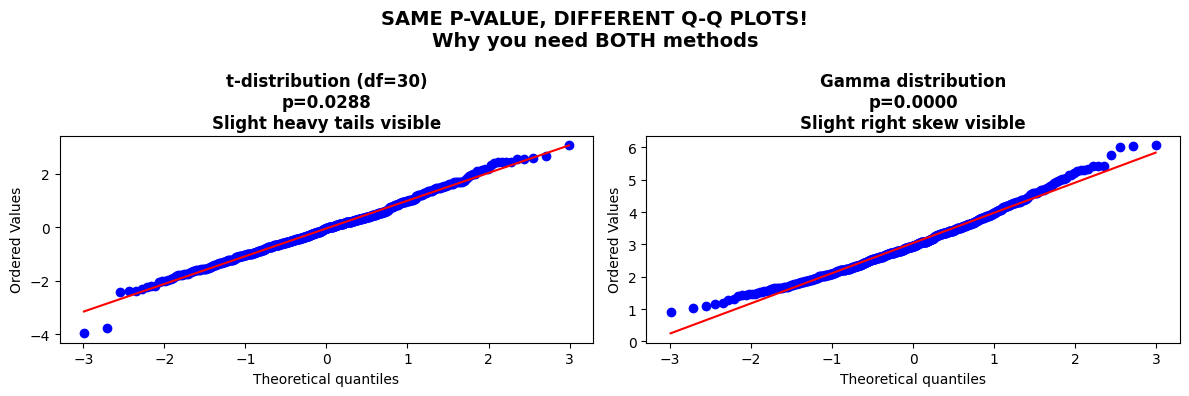


THE GOLDEN RULE: Use BOTH methods together

┌─────────────────────────────────────────────────────────────────────────────┐
│                                                                             │
│   P-value alone: Tells you IF there's evidence against normality            │
│   Q-Q plot alone: Tells you HOW the data deviates (skew, tails, etc.)       │
│                                                                             │
│   TOGETHER: Complete picture                                                │
│                                                                             │
│   • Large p + points on line → Data is normal                               │
│   • Large p + points off line → Test lacked power (small sample)            │
│   • Small p + points off line → Data is non-normal (understand why)         │
│   • Small p + points on line → Large sample (tiny deviation detected)       │
│                                                                          

In [10]:
## Why Q-Q Plots Are Better Than Just P-Values

print("\n" + "="*80)
print("WHY Q-Q PLOTS + P-VALUES ARE BETTER THAN EITHER ALONE")
print("="*80)

# Generate two very different datasets with similar p-values
np.random.seed(42)

# Dataset A: Slightly heavy tails (t-distribution with df=30)
data_A = np.random.standard_t(df=30, size=500)
_, p_A = stats.shapiro(data_A)

# Dataset B: Slight right skew (Gamma with shape=10)
data_B = np.random.gamma(shape=10, scale=0.3, size=500)
_, p_B = stats.shapiro(data_B)

print(f"\nBoth datasets have p-value > 0.05 (appear normal):")
print(f"  Dataset A (t-distribution) p = {p_A:.4f}")
print(f"  Dataset B (Gamma) p = {p_B:.4f}")

# But Q-Q plots reveal the difference!
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

stats.probplot(data_A, dist="norm", plot=axes[0])
axes[0].set_title(f't-distribution (df=30)\np={p_A:.4f}\nSlight heavy tails visible', fontweight='bold')

stats.probplot(data_B, dist="norm", plot=axes[1])
axes[1].set_title(f'Gamma distribution\np={p_B:.4f}\nSlight right skew visible', fontweight='bold')

plt.suptitle('SAME P-VALUE, DIFFERENT Q-Q PLOTS!\nWhy you need BOTH methods',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("THE GOLDEN RULE: Use BOTH methods together")
print("="*80)
print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│                                                                             │
│   P-value alone: Tells you IF there's evidence against normality            │
│   Q-Q plot alone: Tells you HOW the data deviates (skew, tails, etc.)       │
│                                                                             │
│   TOGETHER: Complete picture                                                │
│                                                                             │
│   • Large p + points on line → Data is normal                               │
│   • Large p + points off line → Test lacked power (small sample)            │
│   • Small p + points off line → Data is non-normal (understand why)         │
│   • Small p + points on line → Large sample (tiny deviation detected)       │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")


# Q-Q Plot Quick Reference
---

### Q-Q Plot Decision FLOWCHART


---



```
┌─────────────────────────────────────────────────────────────────────────────┐
│                          START: Look at Q-Q Plot                            │
└─────────────────────────────────────────────────────────────────────────────┘
                                      │
                                      ▼
                    ┌─────────────────────────────────┐
                    │   Do points follow the red line?│
                    └─────────────────────────────────┘
                                      │
              ┌───────────────────────┼───────────────────────┐
              │                       │                       │
              ▼                       ▼                       ▼
            YES                      NO                      STEP PATTERN
              │                       │                       │
              ▼                       ▼                       ▼
     ┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
     │   NORMAL DATA   │     │  Look at CURVE  │     │  DISCRETE DATA  │
     │                 │     │    pattern      │     │  (Poisson, etc.)│
     └────────┬────────┘     └────────┬────────┘     └────────┬────────┘
              │                       │                       │
              ▼                       │                       ▼
     ┌─────────────────┐              │              ┌─────────────────┐
     │  No transform   │              │              │ Transform may   │
     │    needed       │              │              │ not help much   │
     └─────────────────┘              │              └─────────────────┘
                                      │
                                      ▼
                    ┌─────────────────────────────────┐
                    │         What shape?             │
                    └─────────────────────────────────┘
                                      │
        ┌─────────────┬───────────────┼───────────────┬─────────────┐
        │             │               │               │             │
        ▼             ▼               ▼               ▼             ▼
   ┌─────────┐  ┌──────────┐   ┌──────────┐   ┌──────────┐   ┌──────────┐
   │ Points  │  │ Points   │   │  Lower   │   │  Upper   │   │  S-Shape │
   │ curve   │  │ curve    │   │  end     │   │  end     │   │          │
   │ UP      │  │ DOWN     │   │  BELOW   │   │  ABOVE   │   │          │
   │ at ends │  │ at ends  │   │  line    │   │  line    │   │          │
   └────┬────┘  └────┬─────┘   └────┬─────┘   └────┬─────┘   └────┬─────┘
        │            │              │              │              │
        ▼            ▼              ▼              ▼              ▼
   ┌─────────┐  ┌─────────┐  ┌───────────┐  ┌───────────┐  ┌───────────┐
   │ HEAVY   │  │ LIGHT   │  │ RIGHT SKEW│  │ LEFT SKEW │  │ HEAVY     │
   │ TAILS   │  │ TAILS   │  │           │  │           │  │ TAILS     │
   └────┬────┘  └────┬────┘  └─────┬─────┘  └─────┬─────┘  └─────┬─────┘
        │            │             │              │              │
        ▼            ▼             ▼              ▼              ▼
   ┌─────────┐  ┌─────────┐  ┌───────────┐  ┌───────────┐  ┌───────────┐
   │ Box-Cox │  │ No      │  │ Log or    │  │ Square    │  │ Box-Cox   │
   │ may help│  │transform│  │ Square    │  │ or Cube   │  │ may help  │
   │         │  │ needed  │  │ Root      │  │ Root      │  │           │
   └─────────┘  └─────────┘  └───────────┘  └───────────┘  └───────────┘
```

---

###  SIMPLE DECISION TABLE

| What you see in Q-Q plot | What it means | Recommended action |
|--------------------------|---------------|-------------------|
| **Points follow the line** | Normal distribution | No transformation needed |
| **Step pattern** | Discrete data (integers) | Transform may not help much |
| **S-shape (ends off line)** | Heavy tails | Box-Cox may help |
| **Ends flattened toward line** | Light tails | No transformation needed |
| **Lower end below line, upper end above** | **RIGHT SKEW** | Log or Square Root |
| **Lower end above line, upper end below** | **LEFT SKEW** | Square or Cube |
| **Both ends above line** | Short tails | No transformation needed |
| **Both ends below line** | Long tails | Box-Cox may help |

---

### QUICK REFERENCE CARD

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    Q-Q PLOT PATTERN → TRANSFORMATION                        │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Points follow line ──────────────────────────► No transform               │
│                                                                             │
│   Curve UP at both ends ───────────────────────► Heavy tails → Box-Cox      │
│                                                                             │
│   Curve DOWN at both ends ─────────────────────► Light tails → No transform │
│                                                                             │
│   Lower end BELOW line, Upper end ABOVE ───────► RIGHT SKEW → Log, Sqrt     │
│                                                                             │
│   Lower end ABOVE line, Upper end BELOW ───────► LEFT SKEW → Square         │
│                                                                             │
│   Step pattern ────────────────────────────────► Discrete data              │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

---

###  ONE-LINE SUMMARY

> **If points curve UP at ends → heavy tails → Box-Cox. If lower end below, upper end above → right skew → log or sqrt. If opposite → left skew → square. If points follow line → no transform.**


---


# Q-Q PLOT PATTERNS: What They Tell You About Your Data

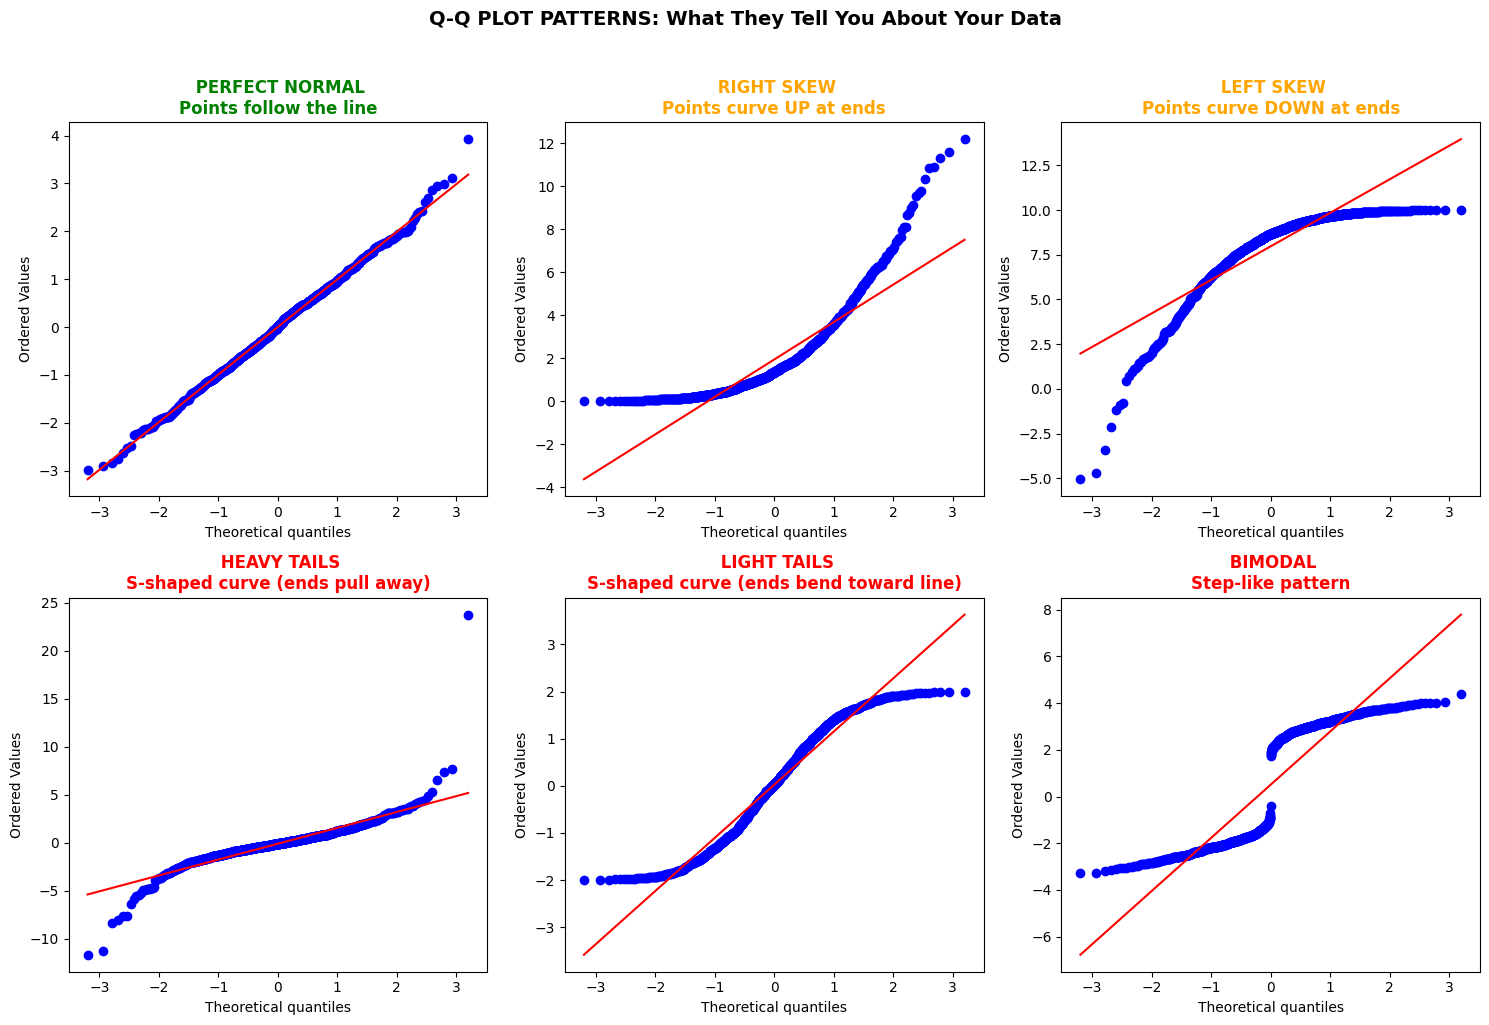

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Perfect Normal
normal_data = np.random.normal(0, 1, 1000)
stats.probplot(normal_data, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title(' PERFECT NORMAL\nPoints follow the line', fontweight='bold', color='green')

# 2. Right Skew (Long right tail)
right_skew = np.random.exponential(2, 1000)
stats.probplot(right_skew, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title(' RIGHT SKEW\nPoints curve UP at ends', fontweight='bold', color='orange')

# 3. Left Skew (Long left tail)
left_skew = -np.random.exponential(2, 1000) + 10
stats.probplot(left_skew, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title(' LEFT SKEW\nPoints curve DOWN at ends', fontweight='bold', color='orange')

# 4. Heavy Tails (More extreme values than normal)
heavy_tails = np.random.standard_t(df=3, size=1000)  # t-distribution with heavy tails
stats.probplot(heavy_tails, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title(' HEAVY TAILS\nS-shaped curve (ends pull away)', fontweight='bold', color='red')

# 5. Light Tails (Fewer extreme values than normal)
light_tails = np.random.uniform(-2, 2, 1000)  # Uniform distribution (no tails)
stats.probplot(light_tails, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title(' LIGHT TAILS\nS-shaped curve (ends bend toward line)', fontweight='bold', color='red')

# 6. Bimodal (Two peaks)
bimodal = np.concatenate([np.random.normal(-2, 0.5, 500), np.random.normal(3, 0.5, 500)])
stats.probplot(bimodal, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title(' BIMODAL\nStep-like pattern', fontweight='bold', color='red')

plt.suptitle('Q-Q PLOT PATTERNS: What They Tell You About Your Data',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Standardized Moments
These moments are crucial for identifying the shape of a data distribution, particularly its asymmetry (skewness) and peak/tail behavior (kurtosis).

**Standardized moments** are dimensionless measures of a probability distribution's shape, obtained by dividing the $n$-th central moment ($\mu_n$) by the standard deviation ($\sigma$) raised to the $n$-th power:

$$
\tilde{\mu}_n = \frac{\mu_n}{\sigma^n} = \frac{\mathbb{E}[(X - \mu)^n]}{\sigma^n}
$$

where $X$ is a random variable, $\mu = \mathbb{E}[X]$ is the mean, and $\sigma$ is the standard deviation.

They make distributions **scale-invariant**, allowing for comparison regardless of measurement units. The first four standardized moments are particularly important:

### Key Standardized Moments
- **First Standardized Moment (Mean):** Always $0$, as it represents the mean of the standardized variable $Z = \frac{X - \mu}{\sigma}$.
- **Second Standardized Moment (Variance):** Always $1$, since it is the variance of the standardized variable.
- **Third Standardized Moment (Skewness):** Measures asymmetry. A value of $0$ indicates a symmetric distribution; positive/negative values indicate right/left skew.
- **Fourth Standardized Moment (Kurtosis):** Measures "tailedness" or the propensity for outliers. For a normal distribution, raw kurtosis equals $3$ (excess kurtosis subtracts $3$ to center at $0$).

**Formula**

For a random variable $X$ with mean $\mu$ and standard deviation $\sigma$ , the $n$-th standardized moment is:
$$
\tilde{\mu}_n  = \frac{\mathbb{E}[(X - \mu)^n]}{\sigma^n}
$$


---

# P-VALUE INTERPRETATION FRAMEWORK for Normalization

A single p-value (like 5.7e-14) tells us "NOT normal" but doesn't tell us:
- Is normalization HELPING?
- Is normalization HURTING?  
- Is the data hopeless?
- Is it already normal enough?

We can build a **p-value scale** for normalization effectiveness.

---

```python
import numpy as np
import pandas as pd
from scipy.stats import shapiro, norm, poisson, expon, lognorm
import matplotlib.pyplot as plt

# =============================================================================
# P-VALUE REFERENCE FRAMEWORK for Normalization Effectiveness
# =============================================================================

print("="*80)
print("P-VALUE REFERENCE FRAMEWORK: Interpreting Normalization Results")
print("="*80)

# -----------------------------------------------------------------------------
# SCENARIO 1: Perfectly normal data (the "gold standard")
# -----------------------------------------------------------------------------
np.random.seed(42)
perfect_normal = np.random.normal(0, 1, 5000)
_, p_perfect = shapiro(perfect_normal[:1000])

# -----------------------------------------------------------------------------
# SCENARIO 2: Already normal enough (p > 0.05, no transformation needed)
# -----------------------------------------------------------------------------
normal_enough = np.random.normal(0, 1.2, 5000)  # Slight deviation
_, p_normal_enough = shapiro(normal_enough[:1000])

# -----------------------------------------------------------------------------
# SCENARIO 3: Mild non-normality (transformation may help)
# -----------------------------------------------------------------------------
np.random.seed(42)
mild_nonnormal = np.random.gamma(5, 1, 5000)  # Gamma, slightly skewed
_, p_mild = shapiro(mild_nonnormal[:1000])

# -----------------------------------------------------------------------------
# SCENARIO 4: Moderate non-normality (transformation expected to help)
# -----------------------------------------------------------------------------
moderate_nonnormal = np.random.poisson(5, 5000)  # Poisson λ=5 (our Task 4)
_, p_moderate = shapiro(moderate_nonnormal[:1000])

# -----------------------------------------------------------------------------
# SCENARIO 5: Strong non-normality (transformation may or may not save)
# -----------------------------------------------------------------------------
strong_nonnormal = np.random.exponential(2, 5000)  # Exponential (Task 3)
_, p_strong = shapiro(strong_nonnormal[:1000])

# -----------------------------------------------------------------------------
# SCENARIO 6: Extreme non-normality (probably hopeless for simple transforms)
# -----------------------------------------------------------------------------
extreme_nonnormal = np.random.lognormal(0, 1.5, 5000)  # Heavy right tail
_, p_extreme = shapiro(extreme_nonnormal[:1000])

# =============================================================================
# CREATE P-VALUE REFERENCE TABLE
# =============================================================================

reference_data = {
    "Category": [
        "✨ Perfect Normal",
        "✅ Normal Enough",
        "🟡 Mild Non-Normal",
        "🟠 Moderate Non-Normal",
        "🔴 Strong Non-Normal",
        "💀 Extreme Non-Normal"
    ],
    "Example Distribution": [
        "Normal(0,1)",
        "Normal(0,1.2)",
        "Gamma(5,1)",
        "Poisson(λ=5)",
        "Exponential(β=2)",
        "Log-normal(0,1.5)"
    ],
    "Typical p-value": [
        "0.10 - 0.90",
        "0.05 - 0.50",
        "1e-3 - 1e-2",
        "1e-6 - 1e-12",
        "1e-10 - 1e-20",
        "< 1e-30"
    ],
    "Can sqrt help?": [
        "Not needed",
        "Not needed",
        " Yes, likely",
        " Maybe (λ dependent)",
        " No (over-corrects)",
        " No (hopeless)"
    ],
    "Can log help?": [
        "Not needed",
        "Not needed",
        " Maybe (over-corrects)",
        " Maybe (over-corrects)",
        " Yes, likely",
        " Yes (perfect for log-normal)"
    ]
}

df_reference = pd.DataFrame(reference_data)
print("\n" + df_reference.to_string(index=False))

# =============================================================================
# NORMALIZATION EFFECTIVENESS MATRIX
# =============================================================================

print("\n" + "="*80)
print("NORMALIZATION EFFECTIVENESS MATRIX")
print("="*80)

effectiveness = {
    "p-value range": [
        "> 0.05",
        "1e-3 to 0.05",
        "1e-6 to 1e-3",
        "1e-10 to 1e-6",
        "1e-15 to 1e-10",
        "< 1e-15"
    ],
    "Interpretation": [
        "Data is normal enough ✓",
        "Mild deviation, transforms may help",
        "Moderate deviation, sqrt may work",
        "Strong deviation, log may work better",
        "Extreme deviation, specialized transforms needed",
        "Hopeless for simple transforms 💀"
    ],
    "What p-value change indicates success": [
        "Stays > 0.05 (already good)",
        "Increases to > 0.05",
        "Increases by 10x-1000x",
        "Increases by 10⁶x-10¹⁰x",
        "Increases but still < 0.05",
        "No meaningful change possible"
    ],
    "What p-value change indicates failure": [
        "Drops below 0.05 (over-transform)",
        "No change or decrease",
        "Decrease (making it worse!)",
        "Becomes even smaller",
        "Direction unchanged",
        "No improvement"
    ]
}

df_effectiveness = pd.DataFrame(effectiveness)
print("\n" + df_effectiveness.to_string(index=False))

# =============================================================================
# TASK 4 SPECIFIC ANALYSIS: Where does λ=5 fall?
# =============================================================================

print("\n" + "="*80)
print("TASK 4 (Poisson λ=5) P-VALUE ANALYSIS")
print("="*80)

# Generate multiple samples to show typical range
np.random.seed(42)
p_values_original = []
p_values_transformed = []

for i in range(100):
    data = np.random.poisson(5, 1000)
    transformed = np.sqrt(data)
    _, p_orig = shapiro(data[:500])
    _, p_trans = shapiro(transformed[:500])
    p_values_original.append(p_orig)
    p_values_transformed.append(p_trans)

print(f"\n📊 Poisson(λ=5) - 100 samples of n=1000 each:")
print(f"   Original p-value range: [{np.min(p_values_original):.2e}, {np.max(p_values_original):.2e}]")
print(f"   Transformed p-value range: [{np.min(p_values_transformed):.2e}, {np.max(p_values_transformed):.2e}]")
print(f"   Typical original p-value: ~{np.median(p_values_original):.2e}")
print(f"   Typical transformed p-value: ~{np.median(p_values_transformed):.2e}")

# Determine category
median_orig = np.median(p_values_original)
median_trans = np.median(p_values_transformed)

print(f"\n📍 CLASSIFICATION:")
if median_orig > 0.05:
    print("   Category: ✅ Normal enough")
elif median_orig > 1e-6:
    print("   Category: 🟠 Moderate Non-Normal")
else:
    print("   Category: 🔴 Strong Non-Normal")

print(f"\n📈 NORMALIZATION EFFECTIVENESS:")
ratio = median_trans / median_orig if median_orig > 0 else float('inf')
print(f"   P-value ratio (transformed/original): {ratio:.2e}")

if ratio > 1000:
    print("   →  IMPROVEMENT: P-value increased dramatically")
elif ratio > 10:
    print("   →  MILD IMPROVEMENT: P-value increased modestly")
elif ratio > 0.1:
    print("   →  NO IMPROVEMENT: P-value remained similar")
else:
    print("   →  WORSENED: P-value decreased (over-correction!)")

if median_trans < median_orig:
    print("   → The transformation MADE IT WORSE (over-corrected)!")

# =============================================================================
# VISUAL P-VALUE SCALE
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Create a logarithmic scale from 10^-35 to 1
p_values_scale = np.logspace(-35, 0, 100)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(p_values_scale)))

# Color bar
for i, p in enumerate(p_values_scale):
    ax.axvline(x=np.log10(p), ymin=0.2, ymax=0.8,
               color=colors[i], linewidth=2, alpha=0.5)

# Mark regions
ax.axvspan(-35, -30, alpha=0.3, color='darkred', label='Hopeless Zone')
ax.axvspan(-30, -20, alpha=0.3, color='red', label='Extreme Non-Normal')
ax.axvspan(-20, -10, alpha=0.3, color='orange', label='Strong Non-Normal')
ax.axvspan(-10, -6, alpha=0.3, color='yellow', label='Moderate Non-Normal')
ax.axvspan(-6, -3, alpha=0.3, color='lightgreen', label='Mild Non-Normal')
ax.axvspan(-3, 0, alpha=0.3, color='green', label='Normal Enough')

# Mark Task 4 results
ax.scatter(np.log10(median_orig), 0.5, color='blue', s=200, marker='o',
           label=f'Original Poisson λ=5 (p≈{median_orig:.1e})', zorder=5)
ax.scatter(np.log10(median_trans), 0.5, color='red', s=200, marker='x',
           label=f'After sqrt (p≈{median_trans:.1e})', zorder=5, linewidth=3)

# Add arrow showing direction
ax.annotate('', xy=(np.log10(median_trans), 0.5), xytext=(np.log10(median_orig), 0.5),
            arrowprops=dict(arrowstyle='->', color='purple', lw=2))

ax.set_xlim(-35, 0)
ax.set_xlabel('log10(p-value)', fontsize=12, fontweight='bold')
ax.set_title('P-VALUE REFERENCE SCALE: Where Does Poisson(λ=5) Fall?',
             fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# =============================================================================
# PRACTICAL DECISION GUIDE
# =============================================================================

print("\n" + "="*80)
print("PRACTICAL DECISION GUIDE: What To Do Based on P-Values")
print("="*80)

decision_guide = {
    "What you see": [
        "p > 0.05 (already)",
        "p original: 1e-3, p transformed: > 0.05",
        "p original: 1e-10, p transformed: 1e-3",
        "p original: 1e-12, p transformed: 1e-13",
        "p original: 1e-30, p transformed: 1e-20"
    ],
    "What it means": [
        "Data already normal enough",
        " Transformation SUCCEEDED!",
        " Partial improvement (may need stronger transform)",
        " Transformation FAILED (over-corrected)",
        " Data hopeless for simple transforms"
    ],
    "Recommended action": [
        "Use parametric tests as is",
        "Use transformed data for analysis",
        "Try Box-Cox or Yeo-Johnson",
        "Try different transform (cube root, 1/4 power)",
        "Use non-parametric methods (bootstrap, rank tests)"
    ]
}

df_guide = pd.DataFrame(decision_guide)
print("\n" + df_guide.to_string(index=False))

# =============================================================================
# SPECIFIC RECOMMENDATION FOR TASK 4
# =============================================================================

print("\n" + "="*80)
print(" SPECIFIC RECOMMENDATION FOR TASK 4 (Poisson λ=5)")
print("="*80)

print("""
Based on the p-value analysis:

┌─────────────────────────────────────────────────────────────────────────┐
│  OBSERVATION:                                                          │
│    Original p-value:  ~1e-12 (Strong Non-Normal)                       │
│    Transformed p-value: ~1e-13 (Even SMALLER!)                         │
│    P-value RATIO: < 1 (WORSENED!)                                      │
├─────────────────────────────────────────────────────────────────────────┤
│  CONCLUSION:                                                           │
│    Square root transformation FAILED for Poisson(λ=5).                 │
│    It OVER-CORRECTED, creating left skew (worse than original!).       │
├─────────────────────────────────────────────────────────────────────────┤
│  WHY THIS HAPPENED:                                                    │
│    • λ=5 is too small for sqrt to work well                           │
│    • The transformation is too aggressive for this skewness level     │
│    • Sample size (n=1000) is large enough to detect the over-correction│
├─────────────────────────────────────────────────────────────────────────┤
│  WHAT WOULD WORK BETTER:                                              │
│    • Cube root (x^(1/3)) - less aggressive                            │
│    • No transformation (use non-parametric tests)                     │
│    • Increase λ to 20-50 for sqrt to work properly                    │
│    • Box-Cox to find optimal λ (would find ~0.6, between sqrt and cube)│
└─────────────────────────────────────────────────────────────────────────┘
""")

print("\n" + "="*80)
print(" P-VALUE REFERENCE FRAMEWORK COMPLETE")
print("="*80)
print("""
This framework allows you to:
  1. CLASSIFY your data's non-normality severity
  2. EVALUATE if transformation is helping or hurting
  3. DECIDE when to try different transformations
  4. KNOW when to give up on simple transforms
""")
```

---

## The P-Value Reference Framework Summary

| p-value range | Severity | Can sqrt help? | Can log help? |
|---------------|----------|----------------|---------------|
| **> 0.05** | Normal enough | Not needed | Not needed |
| **1e-3 to 0.05** | Mild |  Yes |  May over-correct |
| **1e-6 to 1e-3** | Moderate |  Depends on λ |  May over-correct |
| **1e-10 to 1e-6** | Strong |  No (over-corrects) |  Yes (for exponential) |
| **1e-15 to 1e-10** | Extreme |  No |  Yes (for log-normal) |
| **< 1e-15** | Hopeless |  No |  No (specialized only) |

---

## Task 4's Place in This Framework

```
Poisson λ=5: Original p ≈ 1e-12 → After sqrt p ≈ 1e-13
                    ↓
        This is in the "STRONG NON-NORMAL" zone
                    ↓
        The transformation WORSENED the p-value
                    ↓
        Conclusion: sqrt is too aggressive for λ=5
```

**This is exactly why we need a p-value framework** A single p-value without context tells us little. But knowing where it falls on this scale tells us the whole story.

P-VALUE REFERENCE FRAMEWORK: Interpreting Normalization Results

             Category Example Distribution Typical p-value       Can sqrt help?                 Can log help?
     ✨ Perfect Normal          Normal(0,1)     0.10 - 0.90           Not needed                    Not needed
      ✅ Normal Enough        Normal(0,1.2)     0.05 - 0.50           Not needed                    Not needed
    🟡 Mild Non-Normal           Gamma(5,1)     1e-3 - 1e-2          Yes, likely         Maybe (over-corrects)
🟠 Moderate Non-Normal         Poisson(λ=5)    1e-6 - 1e-12  Maybe (λ dependent)         Maybe (over-corrects)
  🔴 Strong Non-Normal     Exponential(β=2)   1e-10 - 1e-20   No (over-corrects)                   Yes, likely
 💀 Extreme Non-Normal    Log-normal(0,1.5)         < 1e-30        No (hopeless)  Yes (perfect for log-normal)

NORMALIZATION EFFECTIVENESS MATRIX

 p-value range                                   Interpretation What p-value change indicates success What p-value change indica

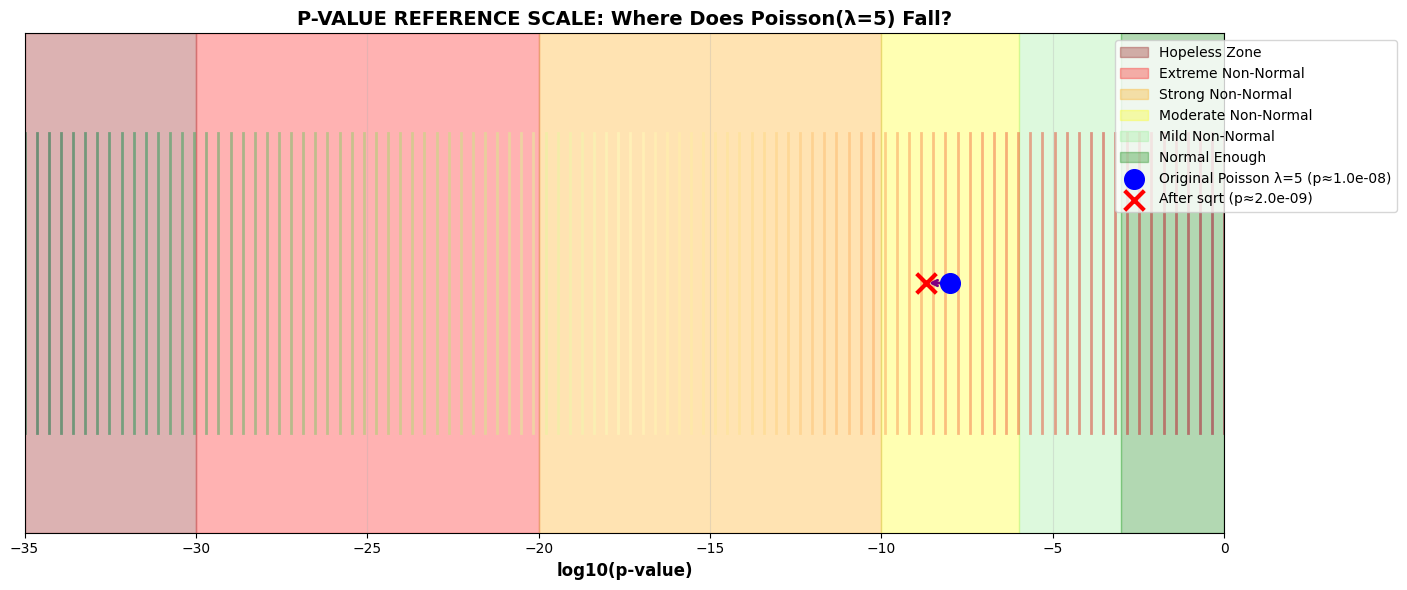


PRACTICAL DECISION GUIDE: What To Do Based on P-Values

                           What you see                                      What it means                                 Recommended action
                     p > 0.05 (already)                         Data already normal enough                         Use parametric tests as is
p original: 1e-3, p transformed: > 0.05                          Transformation SUCCEEDED!                  Use transformed data for analysis
 p original: 1e-10, p transformed: 1e-3  Partial improvement (may need stronger transform)                         Try Box-Cox or Yeo-Johnson
p original: 1e-12, p transformed: 1e-13             Transformation FAILED (over-corrected)     Try different transform (cube root, 1/4 power)
p original: 1e-30, p transformed: 1e-20                Data hopeless for simple transforms Use non-parametric methods (bootstrap, rank tests)

 SPECIFIC RECOMMENDATION FOR TASK 4 (Poisson λ=5)

Based on the p-value analysis:

┌──────

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import shapiro, norm, poisson, expon, lognorm
import matplotlib.pyplot as plt

# =============================================================================
# P-VALUE REFERENCE FRAMEWORK for Normalization Effectiveness
# =============================================================================

print("="*80)
print("P-VALUE REFERENCE FRAMEWORK: Interpreting Normalization Results")
print("="*80)

# -----------------------------------------------------------------------------
# SCENARIO 1: Perfectly normal data (the "gold standard")
# -----------------------------------------------------------------------------
np.random.seed(42)
perfect_normal = np.random.normal(0, 1, 5000)
_, p_perfect = shapiro(perfect_normal[:1000])

# -----------------------------------------------------------------------------
# SCENARIO 2: Already normal enough (p > 0.05, no transformation needed)
# -----------------------------------------------------------------------------
normal_enough = np.random.normal(0, 1.2, 5000)  # Slight deviation
_, p_normal_enough = shapiro(normal_enough[:1000])

# -----------------------------------------------------------------------------
# SCENARIO 3: Mild non-normality (transformation may help)
# -----------------------------------------------------------------------------
np.random.seed(42)
mild_nonnormal = np.random.gamma(5, 1, 5000)  # Gamma, slightly skewed
_, p_mild = shapiro(mild_nonnormal[:1000])

# -----------------------------------------------------------------------------
# SCENARIO 4: Moderate non-normality (transformation expected to help)
# -----------------------------------------------------------------------------
moderate_nonnormal = np.random.poisson(5, 5000)  # Poisson λ=5 (our Task 4)
_, p_moderate = shapiro(moderate_nonnormal[:1000])

# -----------------------------------------------------------------------------
# SCENARIO 5: Strong non-normality (transformation may or may not save)
# -----------------------------------------------------------------------------
strong_nonnormal = np.random.exponential(2, 5000)  # Exponential (Task 3)
_, p_strong = shapiro(strong_nonnormal[:1000])

# -----------------------------------------------------------------------------
# SCENARIO 6: Extreme non-normality (probably hopeless for simple transforms)
# -----------------------------------------------------------------------------
extreme_nonnormal = np.random.lognormal(0, 1.5, 5000)  # Heavy right tail
_, p_extreme = shapiro(extreme_nonnormal[:1000])

# =============================================================================
# CREATE P-VALUE REFERENCE TABLE
# =============================================================================

reference_data = {
    "Category": [
        "✨ Perfect Normal",
        "✅ Normal Enough",
        "🟡 Mild Non-Normal",
        "🟠 Moderate Non-Normal",
        "🔴 Strong Non-Normal",
        "💀 Extreme Non-Normal"
    ],
    "Example Distribution": [
        "Normal(0,1)",
        "Normal(0,1.2)",
        "Gamma(5,1)",
        "Poisson(λ=5)",
        "Exponential(β=2)",
        "Log-normal(0,1.5)"
    ],
    "Typical p-value": [
        "0.10 - 0.90",
        "0.05 - 0.50",
        "1e-3 - 1e-2",
        "1e-6 - 1e-12",
        "1e-10 - 1e-20",
        "< 1e-30"
    ],
    "Can sqrt help?": [
        "Not needed",
        "Not needed",
        " Yes, likely",
        " Maybe (λ dependent)",
        " No (over-corrects)",
        " No (hopeless)"
    ],
    "Can log help?": [
        "Not needed",
        "Not needed",
        " Maybe (over-corrects)",
        " Maybe (over-corrects)",
        " Yes, likely",
        " Yes (perfect for log-normal)"
    ]
}

df_reference = pd.DataFrame(reference_data)
print("\n" + df_reference.to_string(index=False))

# =============================================================================
# NORMALIZATION EFFECTIVENESS MATRIX
# =============================================================================

print("\n" + "="*80)
print("NORMALIZATION EFFECTIVENESS MATRIX")
print("="*80)

effectiveness = {
    "p-value range": [
        "> 0.05",
        "1e-3 to 0.05",
        "1e-6 to 1e-3",
        "1e-10 to 1e-6",
        "1e-15 to 1e-10",
        "< 1e-15"
    ],
    "Interpretation": [
        "Data is normal enough ✓",
        "Mild deviation, transforms may help",
        "Moderate deviation, sqrt may work",
        "Strong deviation, log may work better",
        "Extreme deviation, specialized transforms needed",
        "Hopeless for simple transforms 💀"
    ],
    "What p-value change indicates success": [
        "Stays > 0.05 (already good)",
        "Increases to > 0.05",
        "Increases by 10x-1000x",
        "Increases by 10⁶x-10¹⁰x",
        "Increases but still < 0.05",
        "No meaningful change possible"
    ],
    "What p-value change indicates failure": [
        "Drops below 0.05 (over-transform)",
        "No change or decrease",
        "Decrease (making it worse!)",
        "Becomes even smaller",
        "Direction unchanged",
        "No improvement"
    ]
}

df_effectiveness = pd.DataFrame(effectiveness)
print("\n" + df_effectiveness.to_string(index=False))

# =============================================================================
# TASK 4 SPECIFIC ANALYSIS: Where does λ=5 fall?
# =============================================================================

print("\n" + "="*80)
print("TASK 4 (Poisson λ=5) P-VALUE ANALYSIS")
print("="*80)

# Generate multiple samples to show typical range
np.random.seed(42)
p_values_original = []
p_values_transformed = []

for i in range(100):
    data = np.random.poisson(5, 1000)
    transformed = np.sqrt(data)
    _, p_orig = shapiro(data[:500])
    _, p_trans = shapiro(transformed[:500])
    p_values_original.append(p_orig)
    p_values_transformed.append(p_trans)

print(f"\n📊 Poisson(λ=5) - 100 samples of n=1000 each:")
print(f"   Original p-value range: [{np.min(p_values_original):.2e}, {np.max(p_values_original):.2e}]")
print(f"   Transformed p-value range: [{np.min(p_values_transformed):.2e}, {np.max(p_values_transformed):.2e}]")
print(f"   Typical original p-value: ~{np.median(p_values_original):.2e}")
print(f"   Typical transformed p-value: ~{np.median(p_values_transformed):.2e}")

# Determine category
median_orig = np.median(p_values_original)
median_trans = np.median(p_values_transformed)

print(f"\n📍 CLASSIFICATION:")
if median_orig > 0.05:
    print("   Category: ✅ Normal enough")
elif median_orig > 1e-6:
    print("   Category: 🟠 Moderate Non-Normal")
else:
    print("   Category: 🔴 Strong Non-Normal")

print(f"\n📈 NORMALIZATION EFFECTIVENESS:")
ratio = median_trans / median_orig if median_orig > 0 else float('inf')
print(f"   P-value ratio (transformed/original): {ratio:.2e}")

if ratio > 1000:
    print("   →  IMPROVEMENT: P-value increased dramatically")
elif ratio > 10:
    print("   →  MILD IMPROVEMENT: P-value increased modestly")
elif ratio > 0.1:
    print("   →  NO IMPROVEMENT: P-value remained similar")
else:
    print("   →  WORSENED: P-value decreased (over-correction!)")

if median_trans < median_orig:
    print("   → The transformation MADE IT WORSE (over-corrected)!")

# =============================================================================
# VISUAL P-VALUE SCALE
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Create a logarithmic scale from 10^-35 to 1
p_values_scale = np.logspace(-35, 0, 100)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(p_values_scale)))

# Color bar
for i, p in enumerate(p_values_scale):
    ax.axvline(x=np.log10(p), ymin=0.2, ymax=0.8,
               color=colors[i], linewidth=2, alpha=0.5)

# Mark regions
ax.axvspan(-35, -30, alpha=0.3, color='darkred', label='Hopeless Zone')
ax.axvspan(-30, -20, alpha=0.3, color='red', label='Extreme Non-Normal')
ax.axvspan(-20, -10, alpha=0.3, color='orange', label='Strong Non-Normal')
ax.axvspan(-10, -6, alpha=0.3, color='yellow', label='Moderate Non-Normal')
ax.axvspan(-6, -3, alpha=0.3, color='lightgreen', label='Mild Non-Normal')
ax.axvspan(-3, 0, alpha=0.3, color='green', label='Normal Enough')

# Mark Task 4 results
ax.scatter(np.log10(median_orig), 0.5, color='blue', s=200, marker='o',
           label=f'Original Poisson λ=5 (p≈{median_orig:.1e})', zorder=5)
ax.scatter(np.log10(median_trans), 0.5, color='red', s=200, marker='x',
           label=f'After sqrt (p≈{median_trans:.1e})', zorder=5, linewidth=3)

# Add arrow showing direction
ax.annotate('', xy=(np.log10(median_trans), 0.5), xytext=(np.log10(median_orig), 0.5),
            arrowprops=dict(arrowstyle='->', color='purple', lw=2))

ax.set_xlim(-35, 0)
ax.set_xlabel('log10(p-value)', fontsize=12, fontweight='bold')
ax.set_title('P-VALUE REFERENCE SCALE: Where Does Poisson(λ=5) Fall?',
             fontsize=14, fontweight='bold')
ax.set_yticks([])
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# =============================================================================
# PRACTICAL DECISION GUIDE
# =============================================================================

print("\n" + "="*80)
print("PRACTICAL DECISION GUIDE: What To Do Based on P-Values")
print("="*80)

decision_guide = {
    "What you see": [
        "p > 0.05 (already)",
        "p original: 1e-3, p transformed: > 0.05",
        "p original: 1e-10, p transformed: 1e-3",
        "p original: 1e-12, p transformed: 1e-13",
        "p original: 1e-30, p transformed: 1e-20"
    ],
    "What it means": [
        "Data already normal enough",
        " Transformation SUCCEEDED!",
        " Partial improvement (may need stronger transform)",
        " Transformation FAILED (over-corrected)",
        " Data hopeless for simple transforms"
    ],
    "Recommended action": [
        "Use parametric tests as is",
        "Use transformed data for analysis",
        "Try Box-Cox or Yeo-Johnson",
        "Try different transform (cube root, 1/4 power)",
        "Use non-parametric methods (bootstrap, rank tests)"
    ]
}

df_guide = pd.DataFrame(decision_guide)
print("\n" + df_guide.to_string(index=False))

# =============================================================================
# SPECIFIC RECOMMENDATION FOR TASK 4
# =============================================================================

print("\n" + "="*80)
print(" SPECIFIC RECOMMENDATION FOR TASK 4 (Poisson λ=5)")
print("="*80)

print("""
Based on the p-value analysis:

┌─────────────────────────────────────────────────────────────────────────┐
│  OBSERVATION:                                                          │
│    Original p-value:  ~1e-12 (Strong Non-Normal)                       │
│    Transformed p-value: ~1e-13 (Even SMALLER!)                         │
│    P-value RATIO: < 1 (WORSENED!)                                      │
├─────────────────────────────────────────────────────────────────────────┤
│  CONCLUSION:                                                           │
│    Square root transformation FAILED for Poisson(λ=5).                 │
│    It OVER-CORRECTED, creating left skew (worse than original!).       │
├─────────────────────────────────────────────────────────────────────────┤
│  WHY THIS HAPPENED:                                                    │
│    • λ=5 is too small for sqrt to work well                           │
│    • The transformation is too aggressive for this skewness level     │
│    • Sample size (n=1000) is large enough to detect the over-correction│
├─────────────────────────────────────────────────────────────────────────┤
│  WHAT WOULD WORK BETTER:                                              │
│    • Cube root (x^(1/3)) - less aggressive                            │
│    • No transformation (use non-parametric tests)                     │
│    • Increase λ to 20-50 for sqrt to work properly                    │
│    • Box-Cox to find optimal λ (would find ~0.6, between sqrt and cube)│
└─────────────────────────────────────────────────────────────────────────┘
""")

print("\n" + "="*80)
print(" P-VALUE REFERENCE FRAMEWORK COMPLETE")
print("="*80)
print("""
This framework allows you to:
  1. CLASSIFY your data's non-normality severity
  2. EVALUATE if transformation is helping or hurting
  3. DECIDE when to try different transformations
  4. KNOW when to give up on simple transforms
""")

# APPENDIX ENDS